In [7]:
import yfinance as yf
import numpy as np
import sys
print(sys.executable)
import sys
!{sys.executable} -m pip install yfinance
from src.risk.monte_carlo_var import monte_carlo_option_var
ticker_symbol = "AAPL"
ticker = yf.Ticker(ticker_symbol)

# 1. Get latest stock price
stock_hist = ticker.history(period="5d") #check the timeline as well.
S0 = stock_hist["Close"].iloc[-1]

# 2. Get nearest option expiration
exp = ticker.options[0]
chain = ticker.option_chain(exp)

calls = chain.calls
puts = chain.puts
shares = 5000 

# 3. Pick one option contract
option = calls.iloc[0]

K = option["strike"]

#check these ones. 
option_price = option["lastPrice"]
implied_vol = option["impliedVolatility"]

print("Stock price S0:", S0)
print("Strike K:", K)
print("Option price:", option_price)
print("Implied volatility:", implied_vol)
print("Expiration:", exp)

contracts = 50
portfolio_value = option_price * 100 * contracts
print("Current Option Portfolio Value:", portfolio_value)

/Users/sangpark/Documents/Risk class project/risk-system-main/.venv/bin/python
zsh:1: no such file or directory: /Users/sangpark/Documents/Risk
Stock price S0: 294.0899963378906
Strike K: 205.0
Option price: 88.29
Implied volatility: 3.307618918457031
Expiration: 2026-05-13
Current Option Portfolio Value: 441450.0


In [8]:
option = calls.iloc[0]
K = option["strike"]
option_price = option["lastPrice"]
sigma = option["impliedVolatility"]
result = monte_carlo_option_var(
    S0=S0,
    K=K,
    T=0.5,
    r=0.05,
    sigma=sigma,
    option_price=option_price,
    option_type="call",
    contracts=contracts,
    n_sim=50000,
    confidence=0.99,
    horizon_days=10
)
print("Monte Carlo Option VaR:", result["var"])

Monte Carlo Option VaR: 305246.04647054995


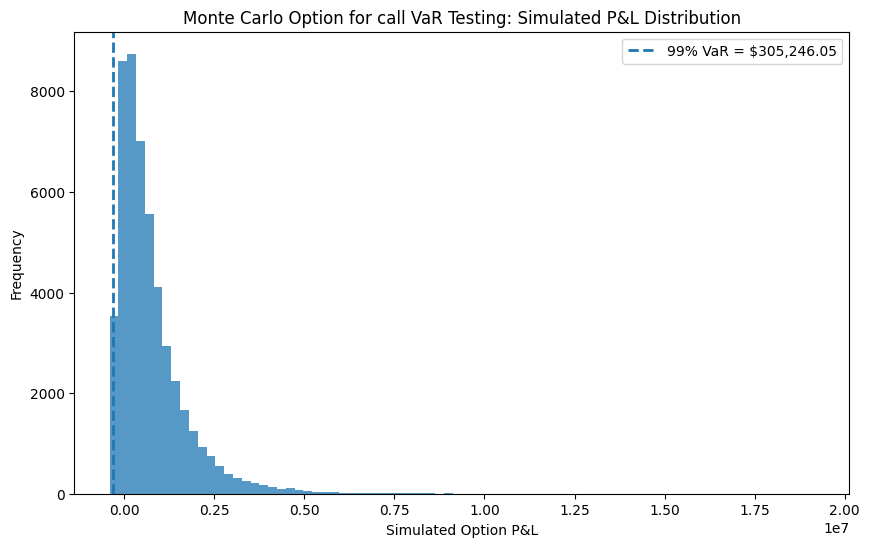

In [9]:
import matplotlib.pyplot as plt
pnl = result["pnl"]
var = result["var"]

plt.figure(figsize=(10, 6))
plt.hist(pnl, bins=80, alpha=0.75)

# VaR line
plt.axvline(-var, linestyle="--", linewidth=2, label=f"99% VaR = ${var:,.2f}")
plt.title("Monte Carlo Option for call VaR Testing: Simulated P&L Distribution")
plt.xlabel("Simulated Option P&L")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [10]:
import sys
print(sys.executable)

/Users/sangpark/Documents/Risk class project/risk-system-main/.venv/bin/python


"Put option"

In [11]:
import pandas as pd
import numpy as np

# Select ATM put
closest_idx = (puts["strike"] - S0).abs().idxmin()
option = puts.loc[closest_idx]

K = option["strike"]
option_price = option["lastPrice"]
sigma = option["impliedVolatility"]

# Correct time to maturity
expiration_date = pd.to_datetime(exp).tz_localize(None)
today = stock_hist.index[-1].tz_localize(None)

T = max((expiration_date - today).days / 365, 1 / 365)

# Horizon cannot exceed remaining maturity
horizon_days = min(1, max((expiration_date - today).days, 1))
result = monte_carlo_option_var(
    S0=S0,
    K=K,
    T=T,
    r=0.05,
    sigma=sigma,
    option_price=option_price,
    option_type="put",
    contracts=contracts,
    n_sim=50000,
    confidence=0.99,
    horizon_days=horizon_days
)
raw_var = result["var"]
clean_var = max(raw_var, 0)

print("Selected Put:")
print(option)

print("T:", T)
print("Horizon days:", horizon_days)
print("Monte Carlo Put VaR:", clean_var)
print("1% PnL percentile:", np.percentile(result["pnl"], 1))

Selected Put:
contractSymbol             AAPL260513P00295000
lastTradeDate        2026-05-12 18:23:41+00:00
strike                                   295.0
lastPrice                                  2.3
bid                                       2.13
ask                                       2.22
change                                    -1.3
percentChange                        -36.11111
volume                                 10397.0
openInterest                             226.0
impliedVolatility                     0.198494
inTheMoney                                True
contractSize                           REGULAR
currency                                   USD
Name: 29, dtype: object
T: 0.0027397260273972603
Horizon days: 1
Monte Carlo Put VaR: 11499.999999999998
1% PnL percentile: -11499.999999999998


Four our testing methodology, we divided our data into short, medium, and long options since they have different behaviors across the market regime changes vs normal market. 

  Expiration_Type Expiration_Date  Strike  Option_Price  Implied_Vol  \
0           Short      2026-05-13   295.0          1.55     0.003916   
1          Medium      2026-05-22   295.0          4.86     0.001963   
2            Long      2026-07-17   295.0         12.73     0.000498   

          T           VaR  
0  0.002740   1550.000000  
1  0.027397   4743.367713  
2  0.180822  10338.293742  


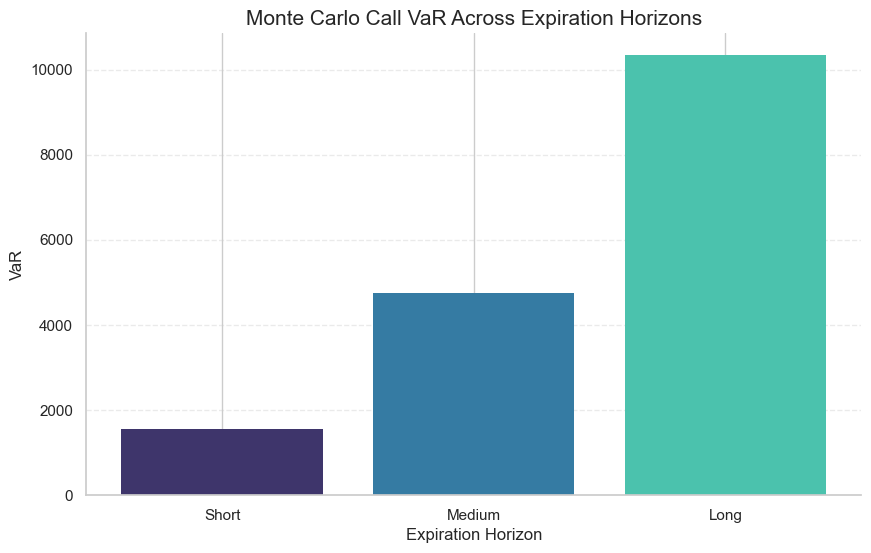

In [9]:
calls = chain.calls
option_type="puts"
# We now test for the call options.

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.risk.monte_carlo_var import monte_carlo_option_var


sns.set_theme(
    style="whitegrid",
    palette="mako"
)

ticker_symbol = "AAPL"
ticker = yf.Ticker(ticker_symbol)

# Current stock price
stock_hist = ticker.history(period="5d")
S0 = stock_hist["Close"].iloc[-1]

contracts = 10

# Expiration selections
expirations = {
    "Short": ticker.options[0],
    "Medium": ticker.options[4],
    "Long": ticker.options[10]
}

results = []

# Run Monte Carlo VaR for each expiration

for label, exp in expirations.items():

    chain = ticker.option_chain(exp)
    calls = chain.calls

    # Select ATM call
    closest_idx = (calls["strike"] - S0).abs().idxmin()
    option = calls.loc[closest_idx]

    K = option["strike"]
    option_price = option["lastPrice"]
    sigma = option["impliedVolatility"]

    # Time to maturity
    expiration_date = pd.to_datetime(exp).tz_localize(None)
    today = stock_hist.index[-1].tz_localize(None)

    T = max((expiration_date - today).days / 365, 1 / 365)

    horizon_days = min(10, max((expiration_date - today).days, 1))

    # Monte Carlo VaR
    result = monte_carlo_option_var(
        S0=S0,
        K=K,
        T=T,
        r=0.05,
        sigma=sigma,
        option_price=option_price,
        option_type="call",
        contracts=contracts,
        n_sim=50000,
        confidence=0.99,
        horizon_days=horizon_days
    )

    var = max(result["var"], 0)

    results.append({
        "Expiration_Type": label,
        "Expiration_Date": exp,
        "Strike": K,
        "Option_Price": option_price,
        "Implied_Vol": sigma,
        "T": T,
        "VaR": var
    })

# Results table

df_results = pd.DataFrame(results)

print(df_results)

# Visualization

plt.figure(figsize=(10, 6))

colors = sns.color_palette("mako", len(df_results))

plt.bar(
    df_results["Expiration_Type"],
    df_results["VaR"],
    color=colors,
    edgecolor="none",
    linewidth=0
)

plt.title(
    "Monte Carlo Call VaR Across Expiration Horizons",
    fontsize=15
)

plt.xlabel("Expiration Horizon", fontsize=12)
plt.ylabel("VaR", fontsize=12)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

sns.despine()

plt.show()

#we expect the option with longer expiration date to have a higher volatility but also high pnl.We also test it on call / put options consistent in the market regime periods as well. 

Pnl Distribution for the call option: 


                          Regime Expiration_Type Option_Type  \
0      Normal Market (2023-2024)           Short        Call   
1            COVID Crisis (2020)           Short        Call   
2          2008 Financial Crisis           Short        Call   
3   Rate-Hike Regime (2022-2023)           Short        Call   
4      Normal Market (2023-2024)           Short         Put   
5            COVID Crisis (2020)           Short         Put   
6          2008 Financial Crisis           Short         Put   
7   Rate-Hike Regime (2022-2023)           Short         Put   
8      Normal Market (2023-2024)          Medium        Call   
9            COVID Crisis (2020)          Medium        Call   
10         2008 Financial Crisis          Medium        Call   
11  Rate-Hike Regime (2022-2023)          Medium        Call   
12     Normal Market (2023-2024)          Medium         Put   
13           COVID Crisis (2020)          Medium         Put   
14         2008 Financial Crisis        

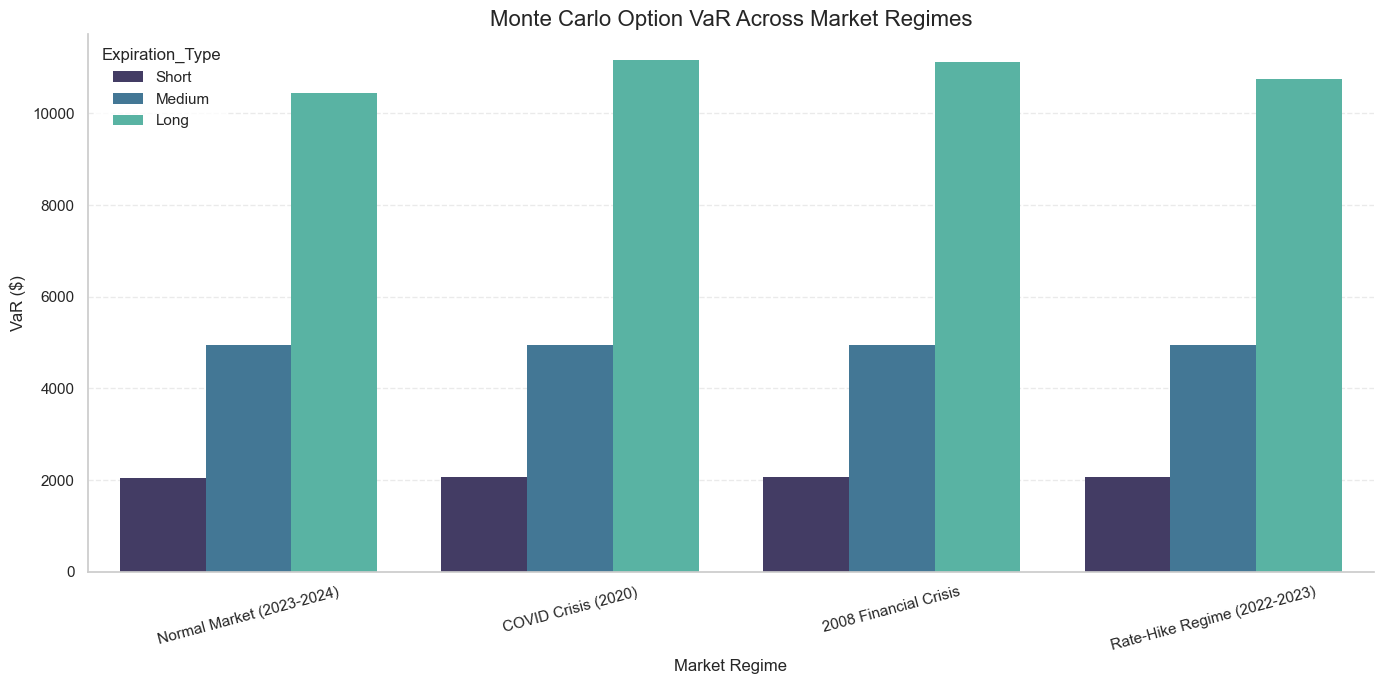

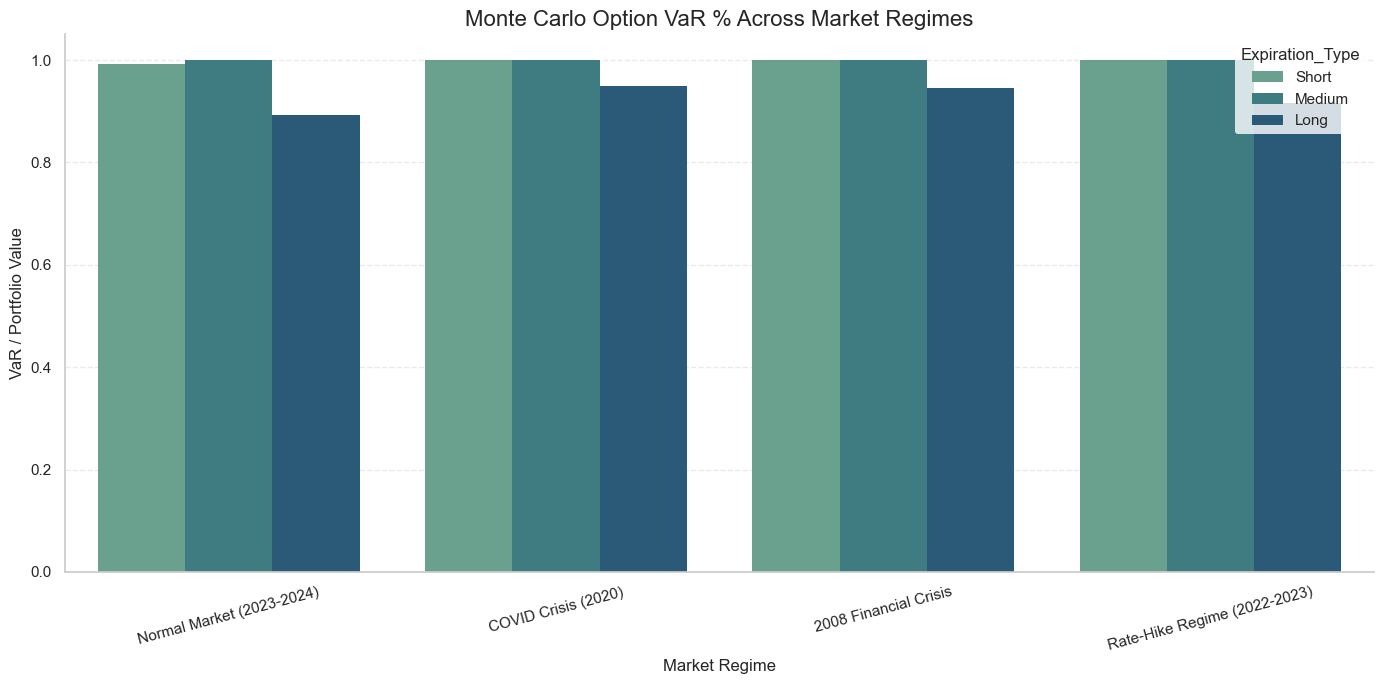

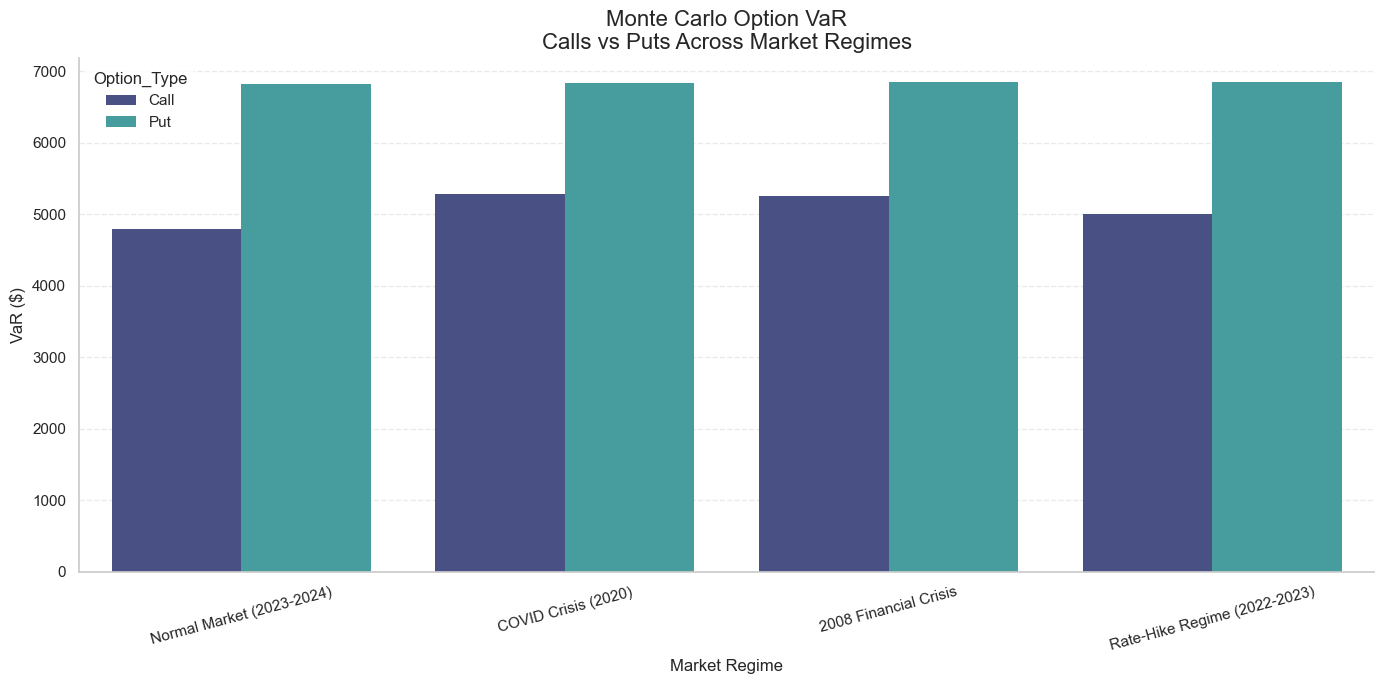

In [19]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.risk.monte_carlo_var import monte_carlo_option_var

# Seaborn Theme

sns.set_theme(
    style="whitegrid",
    palette="mako"
)

plt.rcParams["patch.linewidth"] = 0
plt.rcParams["patch.edgecolor"] = "none"

# Settings

ticker_symbol = "AAPL"

ticker = yf.Ticker(ticker_symbol)

stock_hist = ticker.history(period="5d")

S0 = stock_hist["Close"].iloc[-1]

contracts = 10

r = 0.05

confidence = 0.99

n_sim = 50000

# Market Regimes

periods = {

    "Normal Market (2023-2024)": (
        "2023-01-01",
        "2024-01-01"
    ),

    "COVID Crisis (2020)": (
        "2020-02-01",
        "2020-06-01"
    ),

    "2008 Financial Crisis": (
        "2007-10-01",
        "2009-03-31"
    ),

    "Rate-Hike Regime (2022-2023)": (
        "2022-01-01",
        "2023-12-31"
    )
}

# Expiration Selection

expirations = {

    "Short": ticker.options[0],

    "Medium": ticker.options[4],

    "Long": ticker.options[10]
}

results = []

# Main Loop

for label, exp in expirations.items():

    chain = ticker.option_chain(exp)

    expiration_date = pd.to_datetime(exp).tz_localize(None)

    today = stock_hist.index[-1].tz_localize(None)

    days_to_exp = max(
        (expiration_date - today).days,
        1
    )

    T = max(
        days_to_exp / 365,
        1 / 365
    )

    horizon_days = min(
        10,
        days_to_exp
    )

    # Calls and Puts

    for option_side, option_chain in {

        "Call": chain.calls,

        "Put": chain.puts

    }.items():

        closest_idx = (
            option_chain["strike"] - S0
        ).abs().idxmin()

        option = option_chain.loc[closest_idx]

        K = option["strike"]

        option_price = option["lastPrice"]

        implied_vol = option["impliedVolatility"]

        portfolio_value = (
            option_price
            * 100
            * contracts
        )

        # Regime Loop

        for regime_name, (start, end) in periods.items():

            prices = yf.download(
                ticker_symbol,
                start=start,
                end=end,
                auto_adjust=True,
                progress=False
            )["Close"]

            if isinstance(prices, pd.DataFrame):
                prices = prices[ticker_symbol]

            returns = prices.pct_change().dropna()

            sigma_regime = returns.std()

            # Monte Carlo Repricing VaR

            result = monte_carlo_option_var(

                S0=S0,

                K=K,

                T=T,

                r=r,

                sigma=sigma_regime,

                option_price=option_price,

                option_type=option_side.lower(),

                contracts=contracts,

                n_sim=n_sim,

                confidence=confidence,

                horizon_days=horizon_days
            )

            var = max(
                result["var"],
                0
            )

            results.append({

                "Regime": regime_name,

                "Expiration_Type": label,

                "Option_Type": option_side,

                "Days_to_Expiration": days_to_exp,

                "Strike": K,

                "Implied_Vol_Regime": sigma_regime,

                "Portfolio_Value": portfolio_value,

                "VaR": var,

                "VaR_%": (
                    var / portfolio_value
                    if portfolio_value > 0
                    else np.nan
                )
            })

# Results DataFrame

df_results = pd.DataFrame(results)

print(df_results)

# Expiration Comparison

plt.figure(figsize=(14, 7))

sns.barplot(
    data=df_results,
    x="Regime",
    y="VaR",
    hue="Expiration_Type",
    palette="mako",
    edgecolor="none",
    errorbar=None
)

plt.title(
    "Monte Carlo Option VaR Across Market Regimes",
    fontsize=16
)

plt.ylabel("VaR ($)")
plt.xlabel("Market Regime")

plt.xticks(rotation=15)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

sns.despine()

plt.tight_layout()

plt.show()

# ---------------------------------------------------
# VaR % Comparison
# ---------------------------------------------------

plt.figure(figsize=(14, 7))

sns.barplot(
    data=df_results,
    x="Regime",
    y="VaR_%",
    hue="Expiration_Type",
    palette="crest",
    edgecolor="none",
    errorbar=None
)

plt.title(
    "Monte Carlo Option VaR % Across Market Regimes",
    fontsize=16
)

plt.ylabel("VaR / Portfolio Value")
plt.xlabel("Market Regime")

plt.xticks(rotation=15)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

sns.despine()

plt.tight_layout()

plt.show()

# Calls vs Puts Comparison

plt.figure(figsize=(14, 7))

sns.barplot(
    data=df_results,
    x="Regime",
    y="VaR",
    hue="Option_Type",
    palette="mako",
    edgecolor="none",
    errorbar=None
)

plt.title(
    "Monte Carlo Option VaR\nCalls vs Puts Across Market Regimes",
    fontsize=16
)

plt.ylabel("VaR ($)")
plt.xlabel("Market Regime")

plt.xticks(rotation=15)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

sns.despine()

plt.tight_layout()

plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

                  Regime  Start_Date    End_Date  Mean_Return  Volatility  \
0     Normal Market 2023  2023-01-01  2024-01-01     0.001835    0.012570   
1      COVID Crisis 2020  2020-02-01  2020-05-01     0.000214    0.044702   
2  Rate-Hike Regime 2022  2022-01-01  2022-12-31    -0.001074    0.022471   
3  Financial Crisis 2008  2008-09-01  2009-03-01    -0.004009    0.045348   

   Portfolio_Value  Parametric_VaR  Parametric_CVaR     VaR_%  
0          1000000    74122.967681     87592.893013  0.074123  
1          1000000   326714.826258    374616.963851  0.326715  
2          1000000   176046.349197    200126.345507  0.176046  
3          1000000   373698.171734    422292.822096  0.373698  


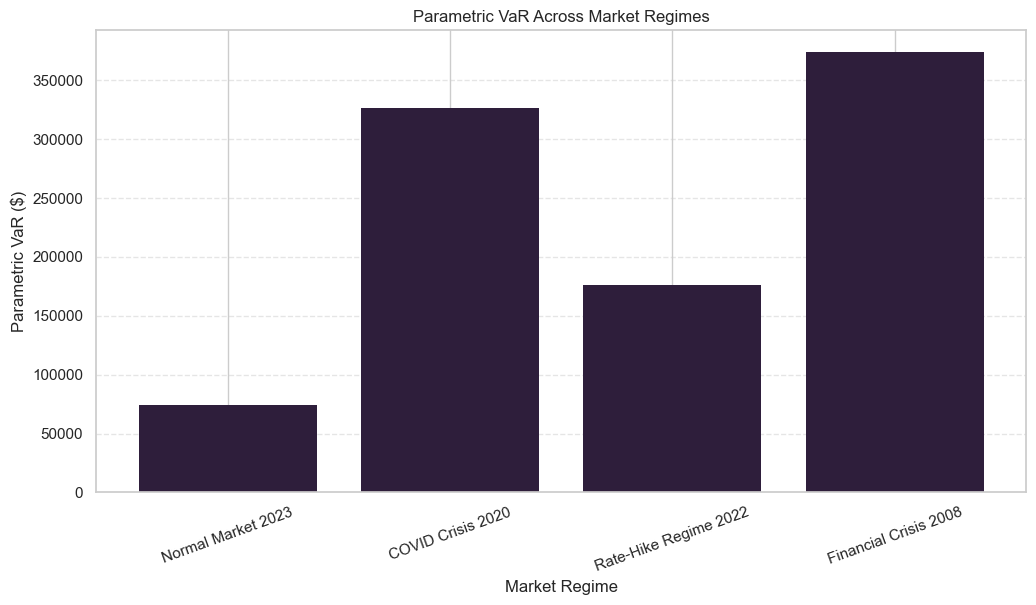

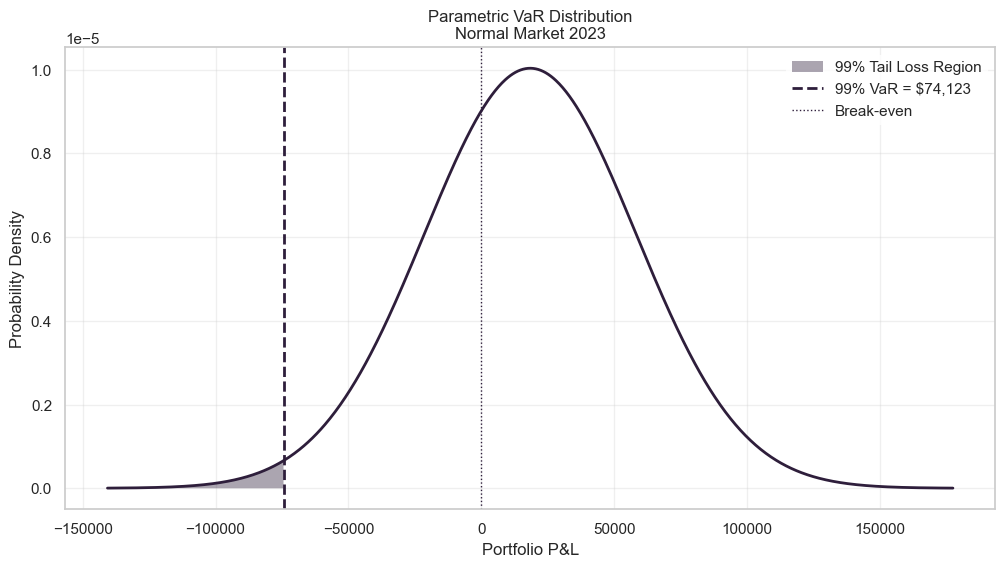

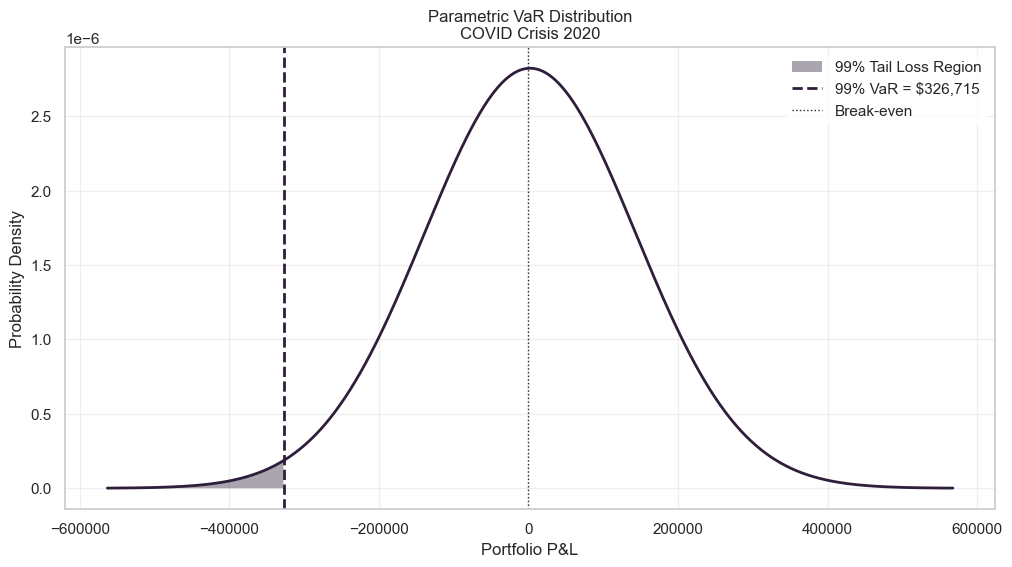

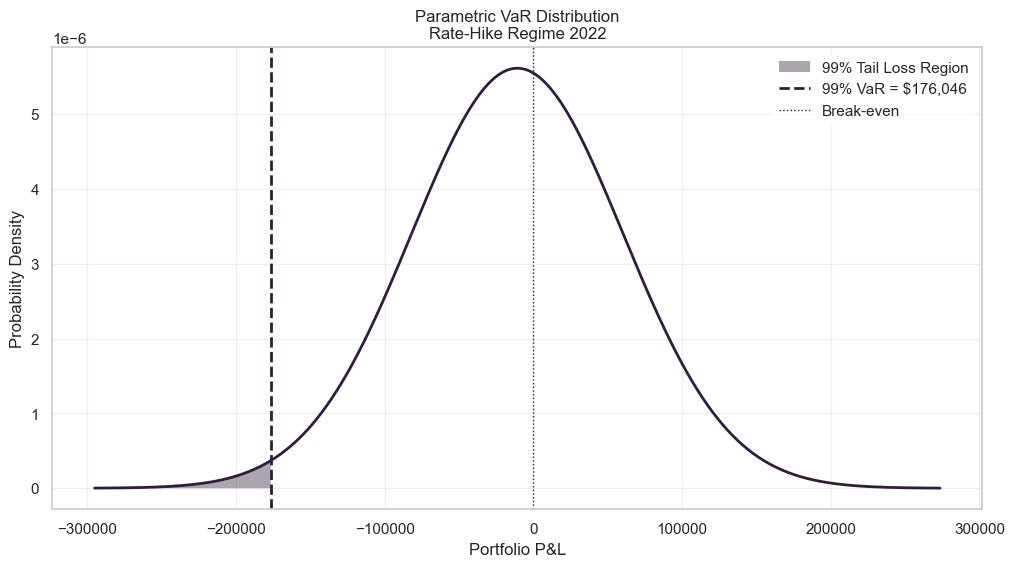

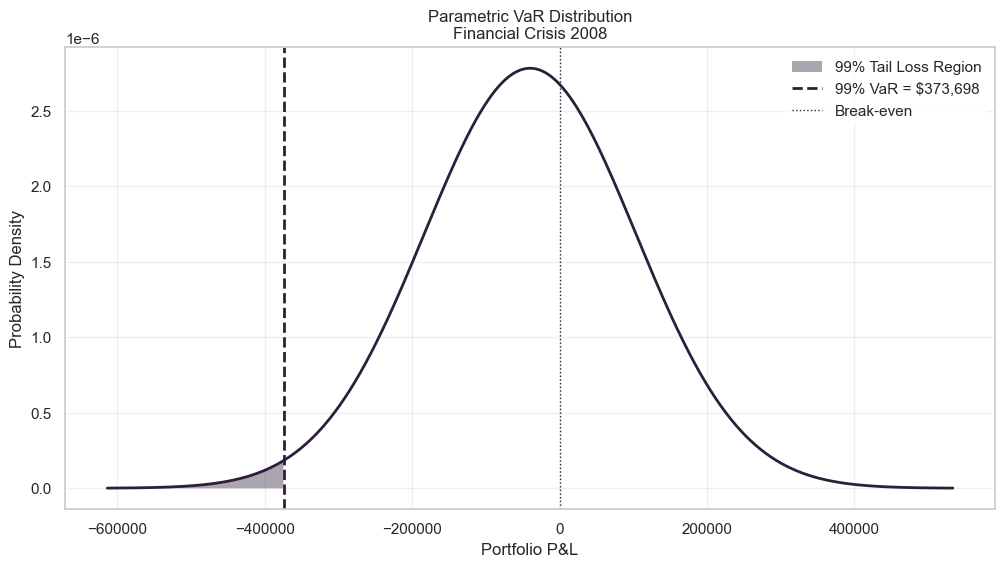

In [20]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from src.risk.parametric_var import parametric_var

# Settings

ticker_symbol = "AAPL"

portfolio_value = 1_000_000

confidence = 0.99

horizon = 10

# Market Regimes

regimes = {
    "Normal Market 2023": ("2023-01-01", "2024-01-01"),
    "COVID Crisis 2020": ("2020-02-01", "2020-05-01"),
    "Rate-Hike Regime 2022": ("2022-01-01", "2022-12-31"),
    "Financial Crisis 2008": ("2008-09-01", "2009-03-01")
}

results = []

distribution_data = {}

# Run Parametric VaR by Regime

for regime_name, (start_date, end_date) in regimes.items():

    prices = yf.download(
        ticker_symbol,
        start=start_date,
        end=end_date,
        interval="1d",
        auto_adjust=True
    )["Close"]

    # Convert dataframe -> series if needed
    if isinstance(prices, pd.DataFrame):
        prices = prices[ticker_symbol]

    # Returns

    returns = prices.pct_change().dropna()

    mu = returns.mean()

    sigma = returns.std()

    # Parametric VaR

    result = parametric_var(
        mu=mu,
        sigma=sigma,
        portfolio_value=portfolio_value,
        confidence=confidence,
        horizon=horizon
    )

    # Distribution Setup


    portfolio_mean = portfolio_value * mu * horizon

    portfolio_std = portfolio_value * sigma * np.sqrt(horizon)

    x = np.linspace(
        portfolio_mean - 4 * portfolio_std,
        portfolio_mean + 4 * portfolio_std,
        1000
    )

    y = norm.pdf(
        x,
        portfolio_mean,
        portfolio_std
    )

    var_cutoff = -result["var"]

    distribution_data[regime_name] = {
        "x": x,
        "y": y,
        "var_cutoff": var_cutoff,
        "var": result["var"]
    }

    # Store Results

    results.append({
        "Regime": regime_name,
        "Start_Date": start_date,
        "End_Date": end_date,
        "Mean_Return": mu,
        "Volatility": sigma,
        "Portfolio_Value": portfolio_value,
        "Parametric_VaR": result["var"],
        "Parametric_CVaR": result["cvar"],
        "VaR_%": result["var"] / portfolio_value
    })

# Results Table
df_results = pd.DataFrame(results)

print(df_results)
#Bar Chart: VaR Comparison

plt.figure(figsize=(12, 6))

plt.bar(
    df_results["Regime"],
    df_results["Parametric_VaR"]
)

plt.title("Parametric VaR Across Market Regimes")

plt.xlabel("Market Regime")

plt.ylabel("Parametric VaR ($)")

plt.xticks(rotation=20)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.show()

#Parametric Distribution Graphs Comparison.

for regime_name, data in distribution_data.items():
    x = data["x"]
    y = data["y"]

    var_cutoff = data["var_cutoff"]
    var = data["var"]
    plt.figure(figsize=(12, 6))
    plt.plot(
        x,
        y,
        linewidth=2
    )
    # Tail region
    plt.fill_between(
        x,
        y,
        where=(x <= var_cutoff),
        alpha=0.4,
        label="99% Tail Loss Region"
    )
    # VaR line
    plt.axvline(
        var_cutoff,
        linestyle="--",
        linewidth=2,
        label=f"99% VaR = ${var:,.0f}"
    )

    # Zero P&L line
    plt.axvline(
        0,
        linestyle=":",
        linewidth=1,
        label="Break-even"
    )

    plt.title(
        f"Parametric VaR Distribution\n{regime_name}"
    )

    plt.xlabel("Portfolio P&L")
    plt.ylabel("Probability Density")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

#For calls and puts, we now first begin with Monte Carlo option repricing VaR function

Parametric and Monte for Options

('2026-05-13', '2026-05-15', '2026-05-18', '2026-05-20', '2026-05-22', '2026-05-29', '2026-06-05', '2026-06-12', '2026-06-18', '2026-06-26', '2026-07-17', '2026-08-21', '2026-09-18', '2026-10-16', '2026-11-20', '2026-12-18', '2027-01-15', '2027-03-19', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-03-17', '2028-12-15')
Selected Option:
contractSymbol             AAPL260522P00295000
lastTradeDate        2026-05-12 19:27:48+00:00
strike                                   295.0
lastPrice                                 4.75
bid                                       4.75
ask                                       4.85
change                                   -1.95
percentChange                         -29.0611
volume                                   700.0
openInterest                               240
impliedVolatility                     0.232552
inTheMoney                                True
contractSize                           REGULAR
currency                           

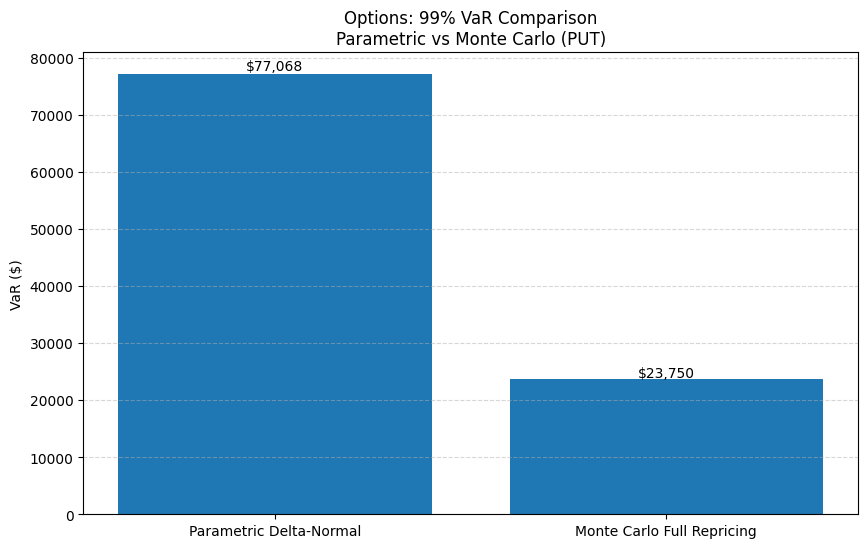

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from src.risk.monte_carlo_var import monte_carlo_option_var

ticker_symbol = "AAPL"
option_type = "put"      # "call" or "put"
contracts = 50
confidence = 0.99
r = 0.05
horizon_days = 10

ticker = yf.Ticker(ticker_symbol)
stock_hist = ticker.history(period="5d")
S0 = stock_hist["Close"].iloc[-1]

# Pick a medium expiration instead of nearest
print(ticker.options)
exp = ticker.options[4]

chain = ticker.option_chain(exp)

if option_type == "call":
    options = chain.calls
else:
    options = chain.puts

# Select ATM option
closest_idx = (options["strike"] - S0).abs().idxmin()
option = options.loc[closest_idx]

K = option["strike"]
option_price = option["lastPrice"]
sigma = option["impliedVolatility"]

expiration_date = pd.to_datetime(exp).tz_localize(None)
today = stock_hist.index[-1].tz_localize(None)

days_to_exp = max((expiration_date - today).days, 1)
T = days_to_exp / 365

horizon_days = min(horizon_days, days_to_exp)


d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

if option_type == "call":
    delta = norm.cdf(d1)
else:
    delta = norm.cdf(d1) - 1


z = norm.ppf(confidence)

parametric_option_var = (
    abs(delta)
    * S0
    * sigma
    * np.sqrt(horizon_days / 252)
    * 100
    * contracts
    * z
)

mc_result = monte_carlo_option_var(
    S0=S0,
    K=K,
    T=T,
    r=r,
    sigma=sigma,
    option_price=option_price,
    option_type=option_type,
    contracts=contracts,
    n_sim=50000,
    confidence=confidence,
    horizon_days=horizon_days
)

mc_option_var = max(mc_result["var"], 0)

# Results
comparison_df = pd.DataFrame({
    "Method": ["Parametric Delta-Normal", "Monte Carlo Full Repricing"],
    "VaR": [parametric_option_var, mc_option_var]
})

print("Selected Option:")
print(option)
print("\nS0:", S0)
print("Strike:", K)
print("Expiration:", exp)
print("Days to Expiration:", days_to_exp)
print("Horizon Days:", horizon_days)
print("Option Price:", option_price)
print("Implied Volatility:", sigma)
print("Delta:", delta)
print("Contracts:", contracts)

print("\n", comparison_df)

# Visualization

plt.figure(figsize=(10, 6))
bars = plt.bar(
    comparison_df["Method"],
    comparison_df["VaR"]
)
for bar, val in zip(bars, comparison_df["VaR"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val * 1.01,
        f"${val:,.0f}",
        ha="center"
    )
plt.title(f"Options: 99% VaR Comparison\nParametric vs Monte Carlo ({option_type.upper()})")
plt.ylabel("VaR ($)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

#Findings: parametric VaR is overestimating the risk since it is assuming normal distribution with high mass in the tails assuming symmeteric and using large z-scores. So to captuer the non-linearity of options, Monte Carlo VAR is more accurate. 

In [ ]:
!pip install black_scholes_price

In [ ]:
import os
print(os.getcwd())

/Users/sangpark/Documents/Risk class project/risk-system-main


At first, we test our methodologies for using contracts of stocks rather than fixed portfolio to find that fixed portfolio captures better since contracts in stocks shrink in value during times like 2008 so using fixed portfolio is better to capture the market regime changes with our internal models. 

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


                  Regime Position Option_Type       S0   Strike  Option_Price  \
0     Normal Market 2023    short         put 190.3751 190.3751        3.9561   
1      COVID Crisis 2020    short         put  70.9244  70.9244        5.5904   
2  Rate-Hike Regime 2022    short         put 127.7616 127.7616        4.9418   
3  Financial Crisis 2008    short         put   2.6735   2.6735        0.2138   

   Daily_Volatility  Annualized_Volatility   Delta  Contracts  \
0            0.0126                 0.1995 -0.4600       1000   
1            0.0447                 0.7096 -0.4515       1000   
2            0.0225                 0.3567 -0.4636       1000   
3            0.0453                 0.7199 -0.4510       1000   

   Portfolio_Value  Parametric_Delta_Normal_VaR  \
0     395,611.4985                 809,798.2514   
1     559,037.5329               1,053,017.8684   
2     494,183.5174                 979,185.2766   
3      21,384.5731                  40,226.1605   

   Monte_Car

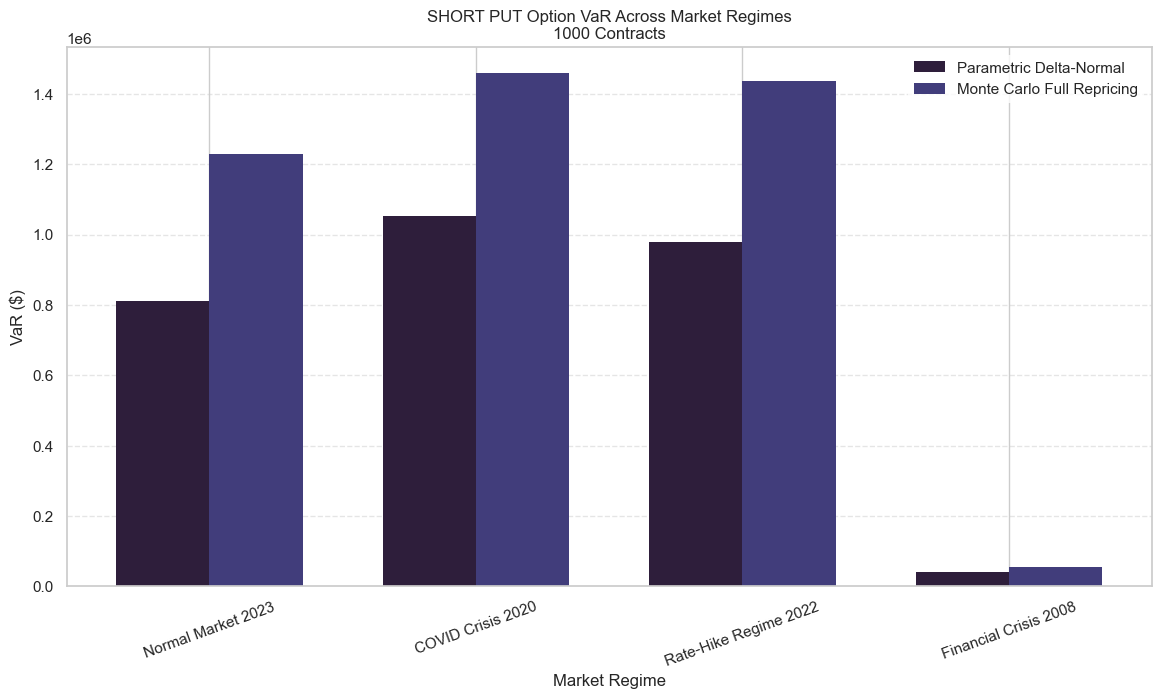

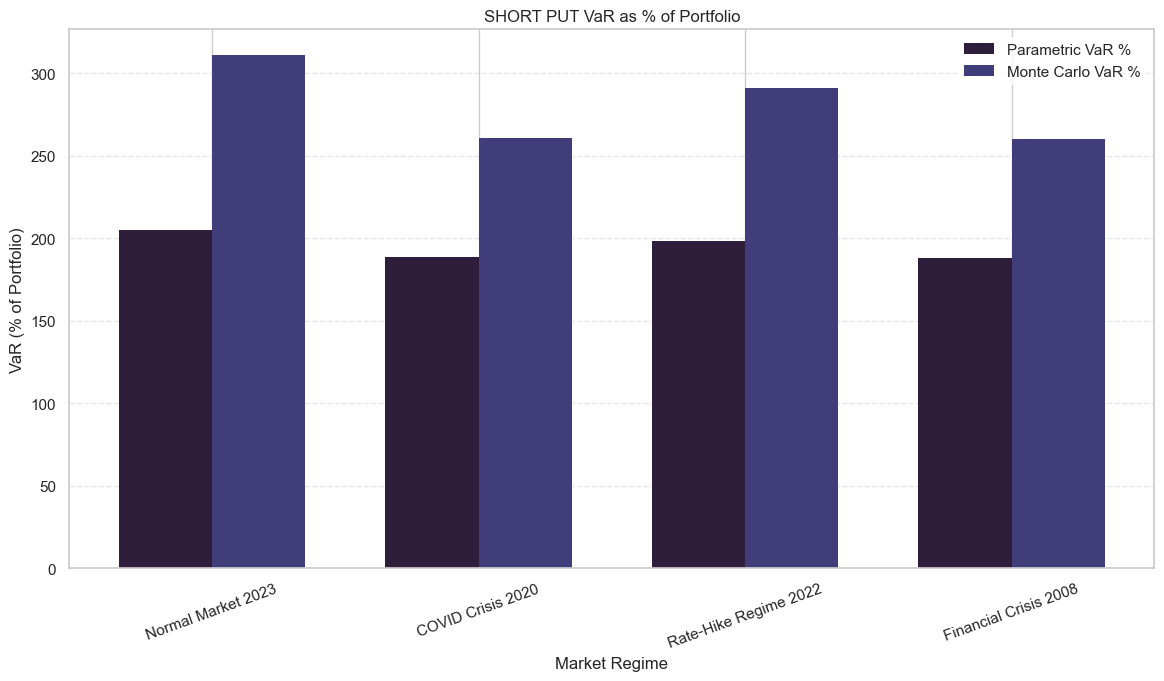

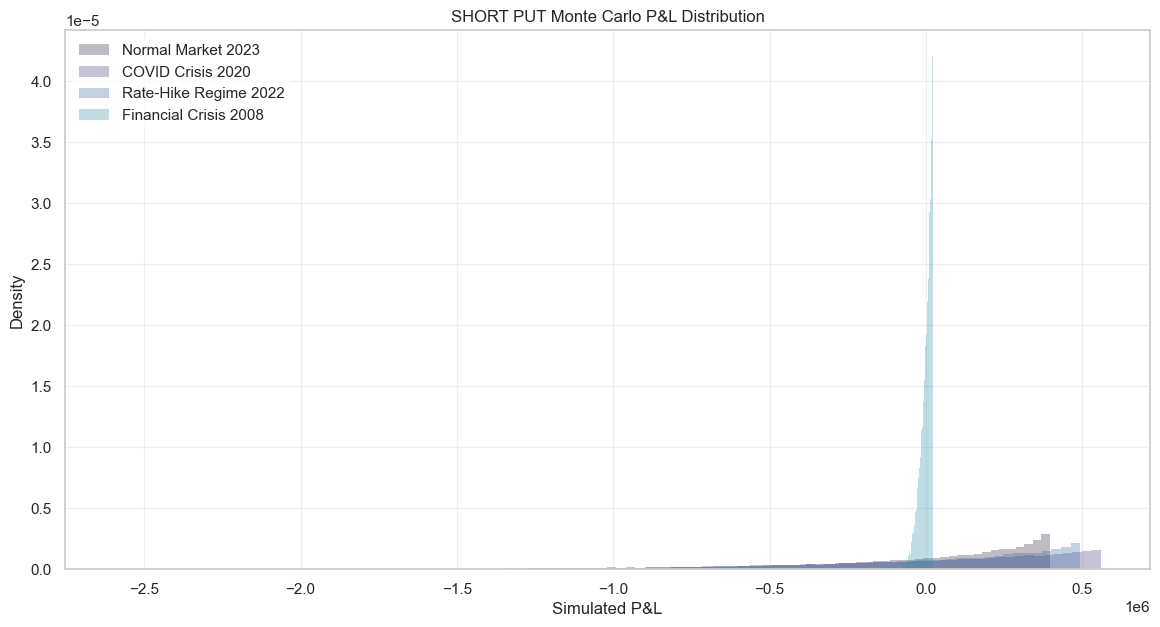

In [28]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from src.risk.black_scholes_prices import black_scholes_price
from src.risk.monte_carlo_var import monte_carlo_option_var
#Settings
ticker_symbol = "AAPL"
contracts = 1000
confidence = 0.99
r = 0.05
horizon_days = 10
n_sim = 50000
T = 30 / 365
option_type = "put"          # "call" or "put"
position_type = "short"      # "long" or "short"

regimes = {
    "Normal Market 2023": ("2023-01-01", "2024-01-01"),
    "COVID Crisis 2020": ("2020-02-01", "2020-05-01"),
    "Rate-Hike Regime 2022": ("2022-01-01", "2022-12-31"),
    "Financial Crisis 2008": ("2008-09-01", "2009-03-01")
}
results = []
all_pnls = {}

#Run Option VaR by Regime

for regime_name, (start_date, end_date) in regimes.items():

    prices = yf.download(
        ticker_symbol,
        start=start_date,
        end=end_date,
        interval="1d",
        auto_adjust=True
    )["Close"]

    if isinstance(prices, pd.DataFrame):
        prices = prices[ticker_symbol]

    returns = prices.pct_change().dropna()

    daily_sigma = returns.std()
    annual_sigma = daily_sigma * np.sqrt(252)

    S0 = prices.iloc[-1]
    K = S0

    option_price = black_scholes_price(
        S=S0,
        K=K,
        T=T,
        r=r,
        sigma=annual_sigma,
        option_type=option_type
    )
    # Delta calculation
    d1 = (
        np.log(S0 / K)
        + (r + 0.5 * annual_sigma**2) * T
    ) / (annual_sigma * np.sqrt(T))

    if option_type == "call":
        delta = norm.cdf(d1)
    else:
        delta = norm.cdf(d1) - 1
    # Parametric Delta-Normal VaR
    z = norm.ppf(confidence)
    parametric_var = (
        abs(delta)
        * S0
        * annual_sigma
        * np.sqrt(horizon_days / 252)
        * 100
        * contracts
        * z
    )
    # Monte Carlo Full-Repricing VaR
    mc_result = monte_carlo_option_var(
        S0=S0,
        K=K,
        T=T,
        r=r,
        sigma=annual_sigma,
        option_price=option_price,
        option_type=option_type,
        contracts=contracts,
        n_sim=n_sim,
        confidence=confidence,
        horizon_days=horizon_days
    )

    long_pnl = mc_result["pnl"]

    if position_type == "long":
        pnl = long_pnl
    else:
        pnl = -long_pnl

    mc_var = -np.percentile(
        pnl,
        (1 - confidence) * 100
    )

    portfolio_value = option_price * 100 * contracts

    results.append({
        "Regime": regime_name,
        "Position": position_type,
        "Option_Type": option_type,
        "S0": S0,
        "Strike": K,
        "Option_Price": option_price,
        "Daily_Volatility": daily_sigma,
        "Annualized_Volatility": annual_sigma,
        "Delta": delta,
        "Contracts": contracts,
        "Portfolio_Value": portfolio_value,
        "Parametric_Delta_Normal_VaR": parametric_var,
        "Monte_Carlo_Full_Repricing_VaR": mc_var,
        "Parametric_VaR_%": parametric_var / portfolio_value,
        "Monte_Carlo_VaR_%": mc_var / portfolio_value
    })

    all_pnls[regime_name] = pnl

# Results Table

df_results = pd.DataFrame(results)

print(df_results)

# VaR Comparison Chart

labels = df_results["Regime"]
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(14, 7))

plt.bar(
    x - width / 2,
    df_results["Parametric_Delta_Normal_VaR"],
    width,
    label="Parametric Delta-Normal"
)

plt.bar(
    x + width / 2,
    df_results["Monte_Carlo_Full_Repricing_VaR"],
    width,
    label="Monte Carlo Full Repricing"
)

plt.title(
    f"{position_type.upper()} {option_type.upper()} Option VaR Across Market Regimes\n"
    f"{contracts} Contracts"
)

plt.xlabel("Market Regime")
plt.ylabel("VaR ($)")
plt.xticks(x, labels, rotation=20)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

# ---------------------------------------------------
# VaR Percentage Chart
# ---------------------------------------------------

plt.figure(figsize=(14, 7))

plt.bar(
    x - width / 2,
    df_results["Parametric_VaR_%"] * 100,
    width,
    label="Parametric VaR %"
)

plt.bar(
    x + width / 2,
    df_results["Monte_Carlo_VaR_%"] * 100,
    width,
    label="Monte Carlo VaR %"
)

plt.title(
    f"{position_type.upper()} {option_type.upper()} VaR as % of Portfolio"
)

plt.xlabel("Market Regime")
plt.ylabel("VaR (% of Portfolio)")
plt.xticks(x, labels, rotation=20)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

plt.figure(figsize=(14, 7))

for label, pnl in all_pnls.items():

    plt.hist(
        pnl,
        bins=100,
        alpha=0.30,
        density=True,
        label=label
    )

plt.title(
    f"{position_type.upper()} {option_type.upper()} Monte Carlo P&L Distribution"
)

plt.xlabel("Simulated P&L")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

ES (Expected Shortfall) is especially useful for market regime analysis because it focuses on the severity of tail losses, not just the loss cutoff point like VaR.
ES in this way uses the averages of the tail outcomes and works quite well especially with shares of stocks. 
Specifically for options, ES is often more meaningful when using fixed contracts rather than a fixed portfolio value because option risk is fundamentally position-driven and nonlinear relationship that ES risk measurement becomes valuable as losses are non-linear in market regime periods. 

Current Stock Price: 295.3999938964844
Available Expirations:
('2026-05-13', '2026-05-15', '2026-05-18', '2026-05-20', '2026-05-22', '2026-05-29', '2026-06-05', '2026-06-12', '2026-06-18', '2026-06-26', '2026-07-17', '2026-08-21', '2026-09-18', '2026-10-16', '2026-11-20', '2026-12-18', '2027-01-15', '2027-03-19', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-03-17', '2028-12-15')

Selected Option:
contractSymbol             AAPL260522C00295000
lastTradeDate        2026-05-13 13:34:20+00:00
strike                                  295.00
lastPrice                                 5.81
bid                                       5.75
ask                                       6.00
change                                    0.95
percentChange                            19.39
volume                                  187.00
openInterest                              4472
impliedVolatility                         0.30
inTheMoney                                True
contractSize       

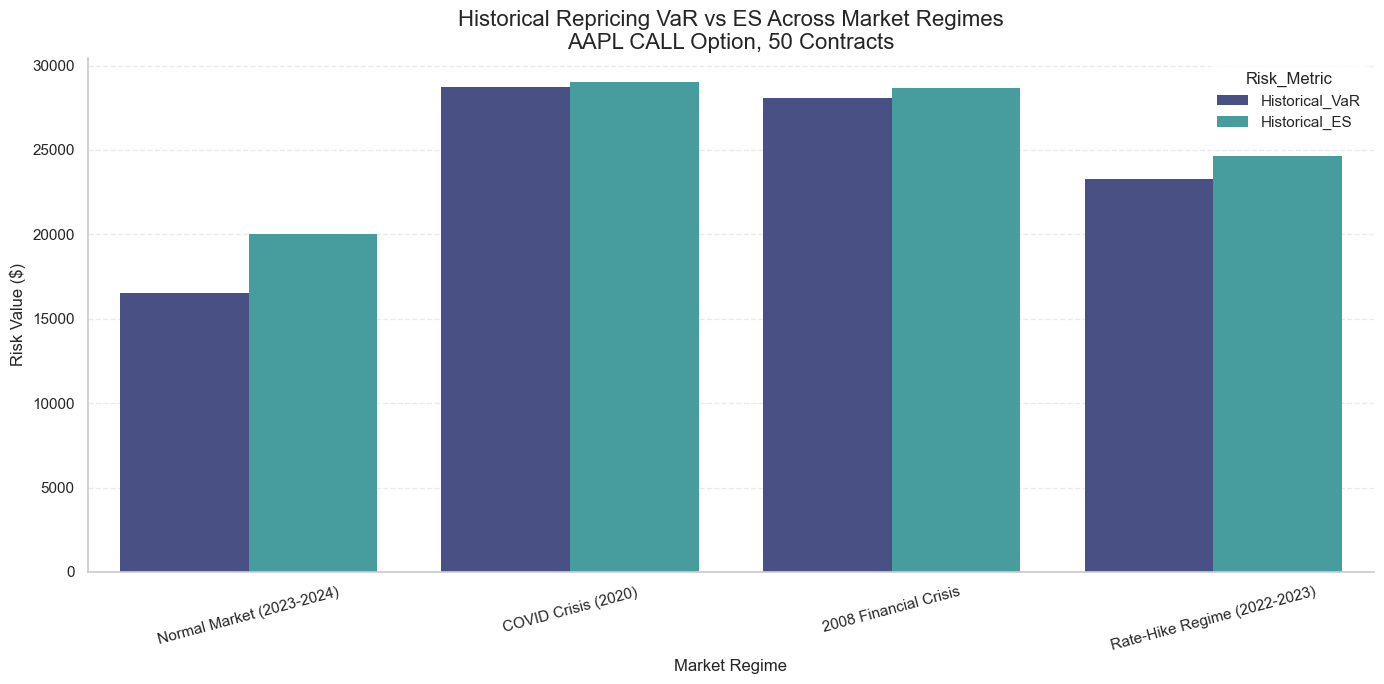

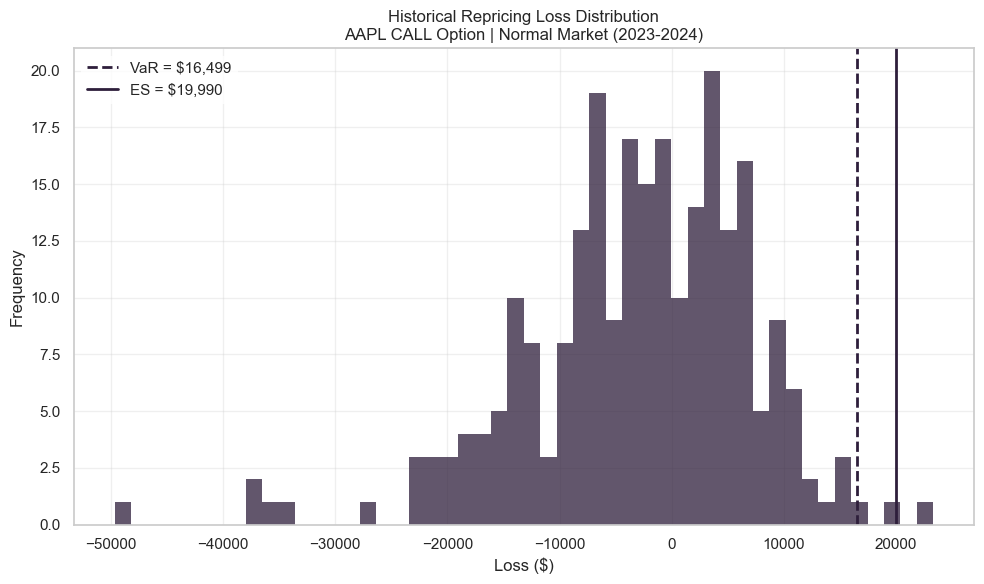

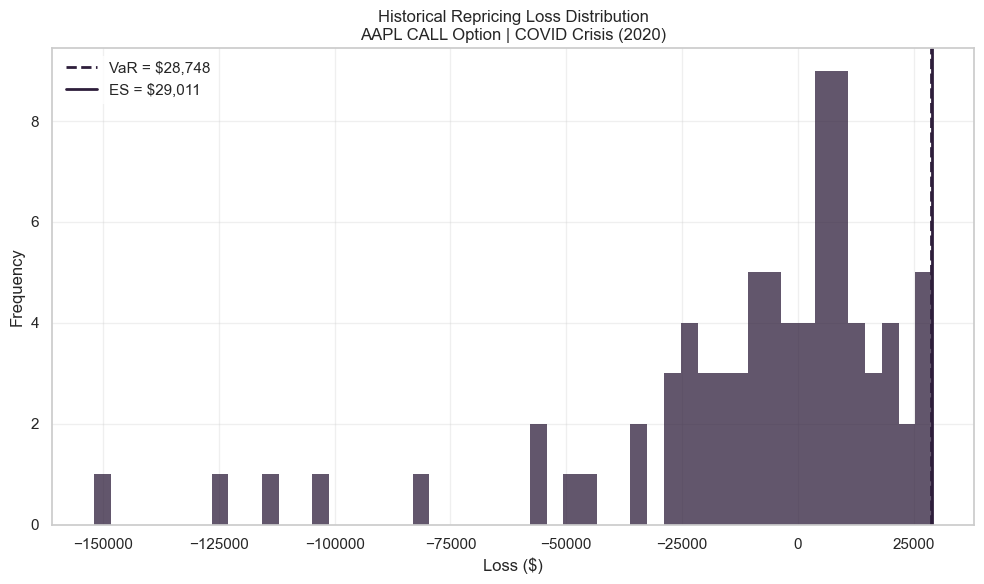

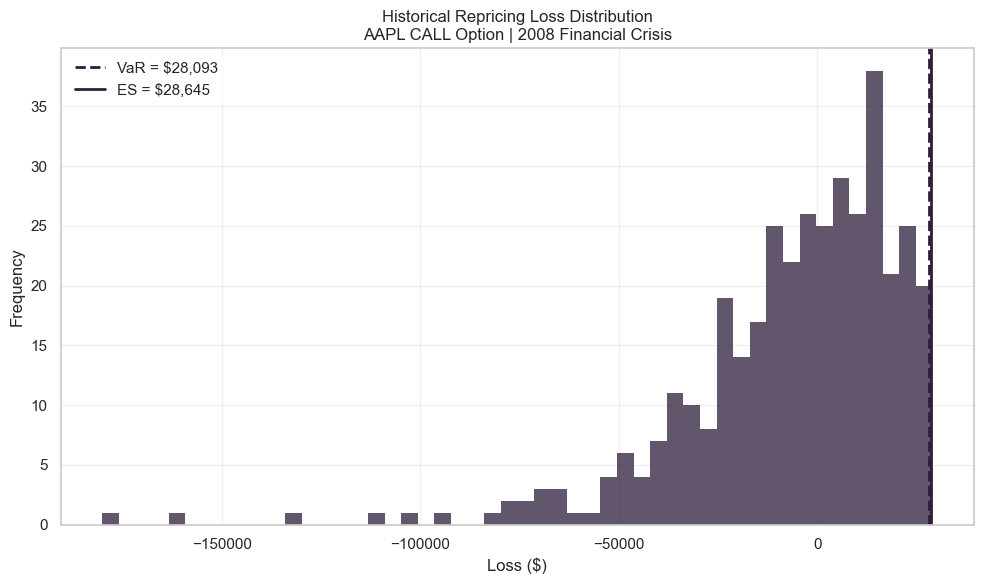

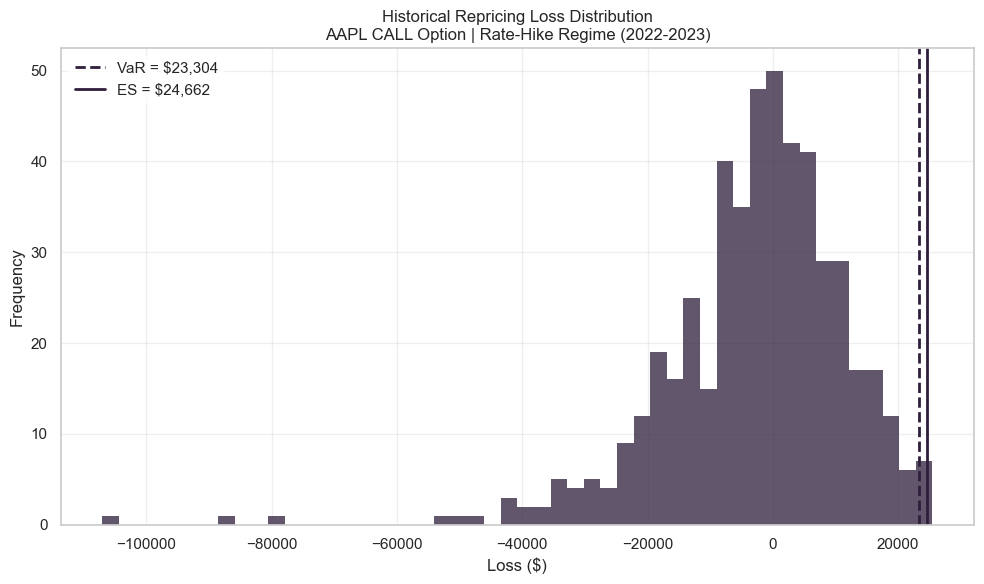

In [31]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.risk.black_scholes_prices import black_scholes_price

sns.set_theme(style="whitegrid", palette="mako")

plt.rcParams["patch.linewidth"] = 0
plt.rcParams["patch.edgecolor"] = "none"


ticker_symbol = "AAPL"

option_type = "call"      # "call" or "put"

contracts = 50
contract_size = 100

confidence = 0.99
r = 0.05

ticker = yf.Ticker(ticker_symbol)

# ---------------------------------------------------
# Market Regimes
# ---------------------------------------------------

periods = {
    "Normal Market (2023-2024)": ("2023-01-01", "2024-01-01"),
    "COVID Crisis (2020)": ("2020-02-01", "2020-06-01"),
    "2008 Financial Crisis": ("2007-10-01", "2009-03-31"),
    "Rate-Hike Regime (2022-2023)": ("2022-01-01", "2023-12-31")
}

# ---------------------------------------------------
# Current Stock Price
# ---------------------------------------------------

stock_hist = ticker.history(period="5d")

S0 = stock_hist["Close"].iloc[-1]

print("Current Stock Price:", S0)


print("Available Expirations:")
print(ticker.options)

exp = ticker.options[4]

chain = ticker.option_chain(exp)

if option_type == "call":
    options = chain.calls.copy()
else:
    options = chain.puts.copy()

# Select ATM option
options["strike_diff"] = abs(options["strike"] - S0)

option = options.sort_values("strike_diff").iloc[0]

K = option["strike"]
option_price = option["lastPrice"]
sigma = option["impliedVolatility"]

# ---------------------------------------------------
# Time to Maturity
# ---------------------------------------------------

expiration_date = pd.to_datetime(exp).tz_localize(None)
today = stock_hist.index[-1].tz_localize(None)

days_to_exp = max((expiration_date - today).days, 1)

T = days_to_exp / 365

# ---------------------------------------------------
# Current Portfolio Value
# ---------------------------------------------------

portfolio_value = option_price * contract_size * contracts

# ---------------------------------------------------
# Run Historical Repricing VaR / ES by Regime
# ---------------------------------------------------

results = []
loss_distributions = {}

for regime_name, (start, end) in periods.items():

    prices = yf.download(
        ticker_symbol,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False
    )["Close"]

    if isinstance(prices, pd.DataFrame):
        prices = prices[ticker_symbol]

    returns = prices.pct_change().dropna()

    simulated_option_values = []

    for ret in returns:

        simulated_S = S0 * (1 + ret)

        repriced_option = black_scholes_price(
            S=simulated_S,
            K=K,
            T=T,
            r=r,
            sigma=sigma,
            option_type=option_type
        )

        simulated_option_values.append(
            repriced_option * contract_size * contracts
        )

    simulated_option_values = np.array(simulated_option_values)

    pnl = simulated_option_values - portfolio_value

    losses = -pnl

    historical_var = np.percentile(
        losses,
        confidence * 100
    )

    tail_losses = losses[
        losses >= historical_var
    ]

    historical_es = tail_losses.mean()

    results.append({
        "Regime": regime_name,
        "Start": start,
        "End": end,
        "Option_Type": option_type,
        "Expiration": exp,
        "Days_to_Expiration": days_to_exp,
        "Strike": K,
        "Option_Price": option_price,
        "Implied_Volatility": sigma,
        "Contracts": contracts,
        "Portfolio_Value": portfolio_value,
        "Historical_VaR": historical_var,
        "Historical_ES": historical_es
    })

    loss_distributions[regime_name] = {
        "Losses": losses,
        "VaR": historical_var,
        "ES": historical_es
    }

# ---------------------------------------------------
# Results Table
# ---------------------------------------------------

df_results = pd.DataFrame(results)

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("\nSelected Option:")
print(option)

print("\nHistorical Repricing VaR / ES by Market Regime")
print(df_results)

df_plot = df_results.melt(
    id_vars="Regime",
    value_vars=["Historical_VaR", "Historical_ES"],
    var_name="Risk_Metric",
    value_name="Risk_Value"
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=df_plot,
    x="Regime",
    y="Risk_Value",
    hue="Risk_Metric",
    palette="mako",
    edgecolor="none",
    errorbar=None
)

plt.title(
    f"Historical Repricing VaR vs ES Across Market Regimes\n"
    f"{ticker_symbol} {option_type.upper()} Option, {contracts} Contracts",
    fontsize=16
)

plt.ylabel("Risk Value ($)")
plt.xlabel("Market Regime")

plt.xticks(rotation=15)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

sns.despine()
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# Individual Loss Distribution Graphs by Regime
# ---------------------------------------------------

for regime_name, data in loss_distributions.items():

    losses = data["Losses"]
    historical_var = data["VaR"]
    historical_es = data["ES"]

    plt.figure(figsize=(10, 6))

    plt.hist(
        losses,
        bins=50,
        alpha=0.75,
        edgecolor="none",
        linewidth=0
    )

    plt.axvline(
        historical_var,
        linestyle="--",
        linewidth=2,
        label=f"VaR = ${historical_var:,.0f}"
    )

    plt.axvline(
        historical_es,
        linestyle="-",
        linewidth=2,
        label=f"ES = ${historical_es:,.0f}"
    )

    plt.title(
        f"Historical Repricing Loss Distribution\n"
        f"{ticker_symbol} {option_type.upper()} Option | {regime_name}"
    )

    plt.xlabel("Loss ($)")
    plt.ylabel("Frequency")

    plt.legend()

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

You can see from our result that ES methodology captues the uneven distributions of lossees that happen when the market regimes change.

[*********************100%***********************]  1 of 1 completed

Ticker: AAPL
Current Price: $294.80
Shares: 100
Portfolio Value: $29,480.00

Historical 99% VaR: $985.03
Historical 99% ES : $1,169.96


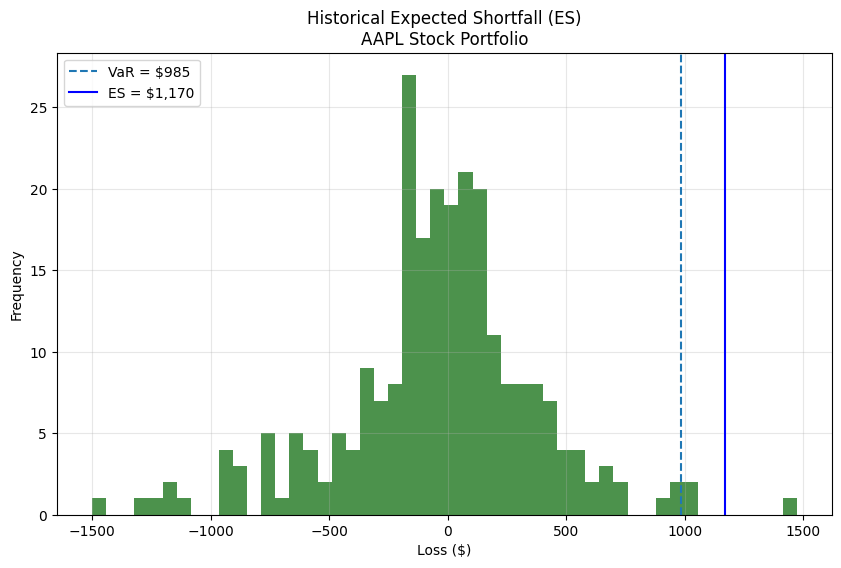

In [69]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Settings
# ---------------------------------------------------

ticker = "AAPL"

shares = 100

confidence = 0.99

# ---------------------------------------------------
# Download stock data
# ---------------------------------------------------

prices = yf.download(
    ticker,
    period="1y",
    interval="1d",
    auto_adjust=True
)["Close"]

# Convert dataframe -> series if needed
if isinstance(prices, pd.DataFrame):
    prices = prices[ticker]

# ---------------------------------------------------
# Historical returns
# ---------------------------------------------------

returns = prices.pct_change().dropna()

# ---------------------------------------------------
# Current portfolio value
# ---------------------------------------------------

current_price = prices.iloc[-1]

portfolio_value = current_price * shares

# ---------------------------------------------------
# Historical P&L distribution
# ---------------------------------------------------

historical_pnl = portfolio_value * returns

# Convert to losses
losses = -historical_pnl

# ---------------------------------------------------
# Historical VaR
# ---------------------------------------------------

historical_var = np.percentile(
    losses,
    confidence * 100
)

# ---------------------------------------------------
# Historical Expected Shortfall (ES)
# ---------------------------------------------------

tail_losses = losses[losses >= historical_var]

historical_es = tail_losses.mean()

# ---------------------------------------------------
# Results
# ---------------------------------------------------

print(f"Ticker: {ticker}")
print(f"Current Price: ${current_price:,.2f}")
print(f"Shares: {shares}")
print(f"Portfolio Value: ${portfolio_value:,.2f}")

print(f"\nHistorical {int(confidence*100)}% VaR: ${historical_var:,.2f}")
print(f"Historical {int(confidence*100)}% ES : ${historical_es:,.2f}")

# ---------------------------------------------------
# Visualization
# ---------------------------------------------------

plt.figure(figsize=(10,6))

plt.hist(
    losses,
    bins=50,
    alpha=0.7,
    color = "darkgreen"
)

plt.axvline(
    historical_var,
    linestyle="--",
    label=f"VaR = ${historical_var:,.0f}"
)

plt.axvline(
    historical_es,
    linestyle="-",
    label=f"ES = ${historical_es:,.0f}",
    color = "blue"
)

plt.title(
    f"Historical Expected Shortfall (ES)\n{ticker} Stock Portfolio"
)

plt.xlabel("Loss ($)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [32]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import norm

# ---------------------------------------------------
# Settings
# ---------------------------------------------------

ticker = "AAPL"
shares = 100
confidence = 0.99
n_sim = 10000

regimes = {
    "Dot-com Bubble / Crash": ("2000-03-01", "2002-10-31"),
    "2008 Financial Crisis": ("2007-10-01", "2009-03-31"),
    "COVID Recession": ("2020-02-01", "2020-06-30"),
    "2022-2023 Rate Hikes": ("2022-01-01", "2023-12-31")
}

# ---------------------------------------------------
# VaR / CVaR Functions
# ---------------------------------------------------

def historical_var_cvar(losses, confidence=0.99):
    var = np.percentile(losses, confidence * 100)
    cvar = losses[losses >= var].mean()
    return var, cvar


def parametric_var_cvar(returns, portfolio_value, confidence=0.99):
    mu = returns.mean()
    sigma = returns.std()

    z = norm.ppf(confidence)

    var = portfolio_value * (z * sigma - mu)

    cvar = portfolio_value * (
        sigma * norm.pdf(z) / (1 - confidence) - mu
    )

    return var, cvar


def monte_carlo_var_cvar(returns, portfolio_value, confidence=0.99, n_sim=10000):
    mu = returns.mean()
    sigma = returns.std()

    simulated_returns = np.random.normal(
        loc=mu,
        scale=sigma,
        size=n_sim
    )

    simulated_losses = -portfolio_value * simulated_returns

    var = np.percentile(simulated_losses, confidence * 100)
    cvar = simulated_losses[simulated_losses >= var].mean()

    return var, cvar


def breach_rate(losses, var):
    return (losses > var).mean()


# ---------------------------------------------------
# Regime Testing
# ---------------------------------------------------

results = []

for regime_name, (start_date, end_date) in regimes.items():

    print(f"Testing: {regime_name}")

    prices = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        auto_adjust=True,
        progress=False
    )["Close"]

    # Convert DataFrame to Series if needed
    if isinstance(prices, pd.DataFrame):
        prices = prices[ticker]

    returns = prices.pct_change().dropna()

    current_price = prices.iloc[-1]
    portfolio_value = current_price * shares

    # Actual historical losses
    losses = -portfolio_value * returns

    # Historical VaR / CVaR
    hist_var, hist_cvar = historical_var_cvar(
        losses,
        confidence
    )

    # Parametric VaR / CVaR
    param_var, param_cvar = parametric_var_cvar(
        returns,
        portfolio_value,
        confidence
    )

    # Monte Carlo VaR / CVaR
    mc_var, mc_cvar = monte_carlo_var_cvar(
        returns,
        portfolio_value,
        confidence,
        n_sim
    )

    results.append({
        "Regime": regime_name,

        "Historical VaR": hist_var,
        "Historical CVaR": hist_cvar,
        "Historical Breach Rate": breach_rate(losses, hist_var),

        "Parametric VaR": param_var,
        "Parametric CVaR": param_cvar,
        "Parametric Breach Rate": breach_rate(losses, param_var),

        "Monte Carlo VaR": mc_var,
        "Monte Carlo CVaR": mc_cvar,
        "Monte Carlo Breach Rate": breach_rate(losses, mc_var),
    })


# ---------------------------------------------------
# Results Table
# ---------------------------------------------------

results_df = pd.DataFrame(results)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("\nVaR / CVaR Regime Test Results:")
print(results_df)

Testing: Dot-com Bubble / Crash
Testing: 2008 Financial Crisis
Testing: COVID Recession
Testing: 2022-2023 Rate Hikes

VaR / CVaR Regime Test Results:
                   Regime  Historical VaR  Historical CVaR  \
0  Dot-com Bubble / Crash          1.9580           4.4421   
1   2008 Financial Crisis         26.1284          36.2300   
2         COVID Recession        863.0854         995.6925   
3    2022-2023 Rate Hikes        914.3892       1,034.7852   

   Historical Breach Rate  Parametric VaR  Parametric CVaR  \
0                  0.0105          2.4338           2.7847   
1                  0.0106         25.2287          28.8820   
2                  0.0196        715.9672         823.1352   
3                  0.0100        805.4180         923.5770   

   Parametric Breach Rate  Monte Carlo VaR  Monte Carlo CVaR  \
0                  0.0075           2.4149            2.7660   
1                  0.0133          25.9041           29.9400   
2                  0.0196         7

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Normal Period
VaR: $687.58
ES : $727.45

Stress Period
VaR: $806.02
ES : $990.06


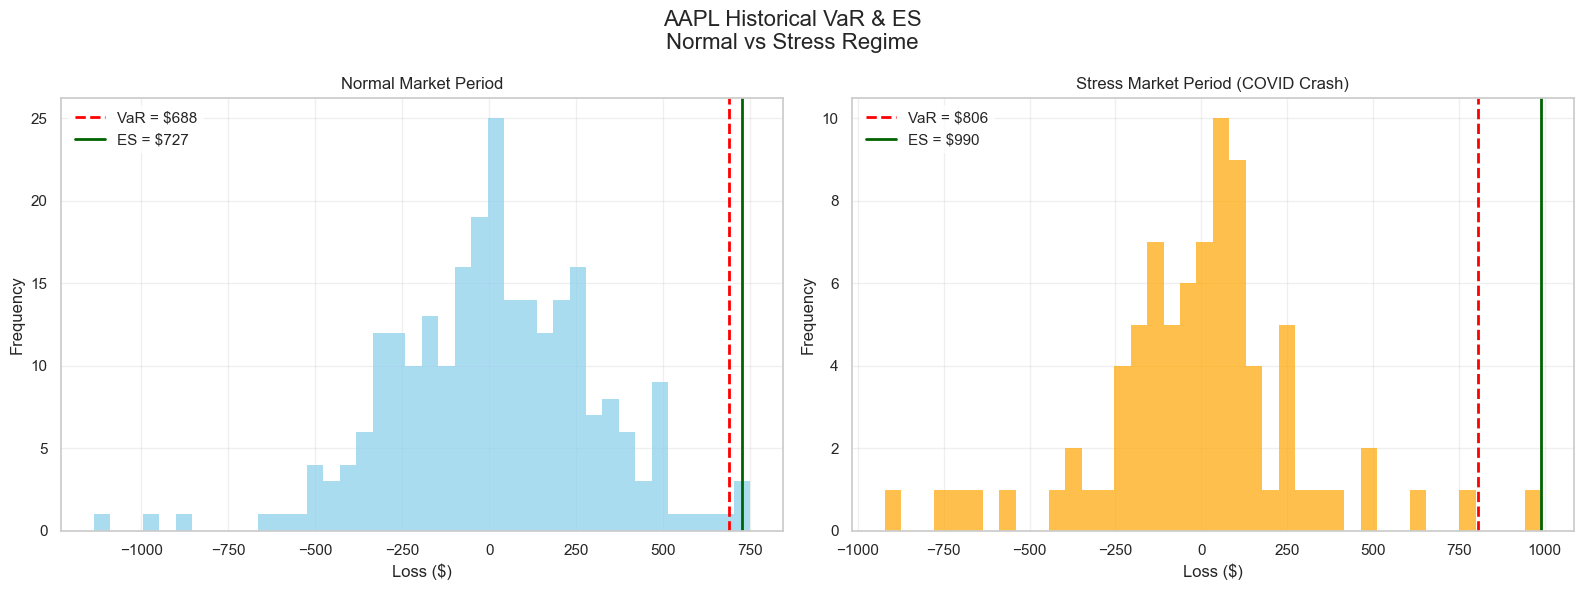

In [33]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Settings
# ---------------------------------------------------

ticker = "AAPL"
shares = 100
confidence = 0.99

# ---------------------------------------------------
# Function
# ---------------------------------------------------

def compute_var_es(prices, shares, confidence):

    returns = prices.pct_change().dropna()

    current_price = prices.iloc[-1]

    portfolio_value = current_price * shares

    pnl = portfolio_value * returns

    losses = -pnl

    var = np.percentile(
        losses,
        confidence * 100
    )

    tail_losses = losses[losses >= var]

    es = tail_losses.mean()

    return losses, var, es

# ---------------------------------------------------
# Normal period
# ---------------------------------------------------

normal_prices = yf.download(
    ticker,
    start="2022-01-01",
    end="2022-12-31",
    auto_adjust=True
)["Close"]

if isinstance(normal_prices, pd.DataFrame):
    normal_prices = normal_prices[ticker]

normal_losses, normal_var, normal_es = compute_var_es(
    normal_prices,
    shares,
    confidence
)

# ---------------------------------------------------
# Stress period (COVID crash)
# ---------------------------------------------------

stress_prices = yf.download(
    ticker,
    start="2020-02-01",
    end="2020-06-01",
    auto_adjust=True
)["Close"]

if isinstance(stress_prices, pd.DataFrame):
    stress_prices = stress_prices[ticker]

stress_losses, stress_var, stress_es = compute_var_es(
    stress_prices,
    shares,
    confidence
)

# ---------------------------------------------------
# Results
# ---------------------------------------------------

print("Normal Period")
print(f"VaR: ${normal_var:,.2f}")
print(f"ES : ${normal_es:,.2f}")

print("\nStress Period")
print(f"VaR: ${stress_var:,.2f}")
print(f"ES : ${stress_es:,.2f}")

# ---------------------------------------------------
# Visualization
# ---------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16,6)
)

# ---------------------------------------------------
# Normal Period Graph
# ---------------------------------------------------

axes[0].hist(
    normal_losses,
    bins=40,
    alpha=0.7,
    color="skyblue"
)

axes[0].axvline(
    normal_var,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"VaR = ${normal_var:,.0f}"
)

axes[0].axvline(
    normal_es,
    color="darkgreen",
    linestyle="-",
    linewidth=2,
    label=f"ES = ${normal_es:,.0f}"
)

axes[0].set_title("Normal Market Period")

axes[0].set_xlabel("Loss ($)")
axes[0].set_ylabel("Frequency")

axes[0].legend()

axes[0].grid(alpha=0.3)

# ---------------------------------------------------
# Stress Period Graph
# ---------------------------------------------------

axes[1].hist(
    stress_losses,
    bins=40,
    alpha=0.7,
    color="orange"
)

axes[1].axvline(
    stress_var,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"VaR = ${stress_var:,.0f}"
)

axes[1].axvline(
    stress_es,
    color="darkgreen",
    linestyle="-",
    linewidth=2,
    label=f"ES = ${stress_es:,.0f}"
)

axes[1].set_title("Stress Market Period (COVID Crash)")

axes[1].set_xlabel("Loss ($)")
axes[1].set_ylabel("Frequency")

axes[1].legend()

axes[1].grid(alpha=0.3)

# ---------------------------------------------------
# Final Layout
# ---------------------------------------------------

plt.suptitle(
    f"{ticker} Historical VaR & ES\nNormal vs Stress Regime",
    fontsize=16
)

plt.tight_layout()

plt.show()

Next, from the chart above, we compare and show the historical VAR and ES to see how they differ across covid period vs normal period. We also see the historical VaR aligns with normal distribution then the stress period in Covid. 

[*********************100%***********************]  1 of 1 completed

Ticker: AAPL
Current Price: 295.2099914550781
Shares: 100
Portfolio Value: 29520.999145507812

             Method  Risk Value
0   Historical VaR    985.7287
1    Historical ES  1,171.5845
2   Parametric VaR  3,075.5610
3  Monte Carlo VaR  2,673.2900


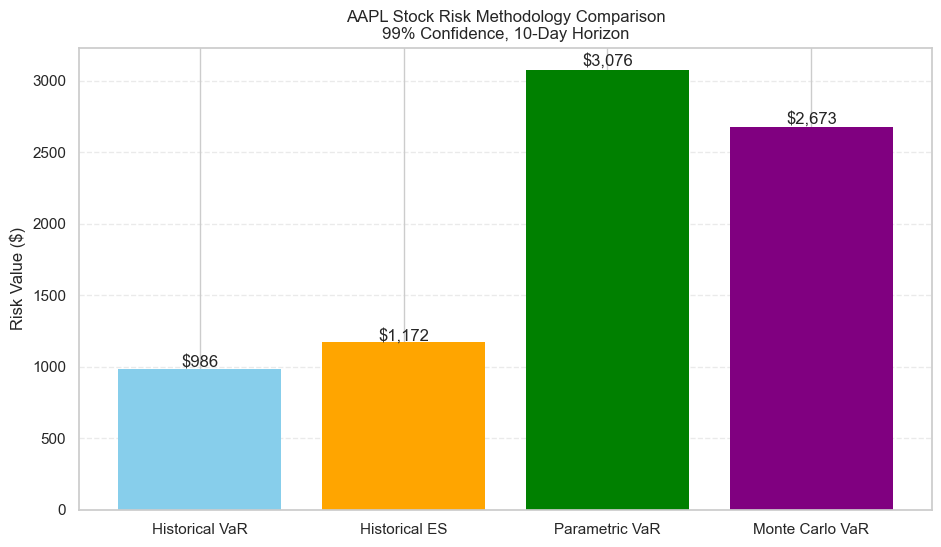

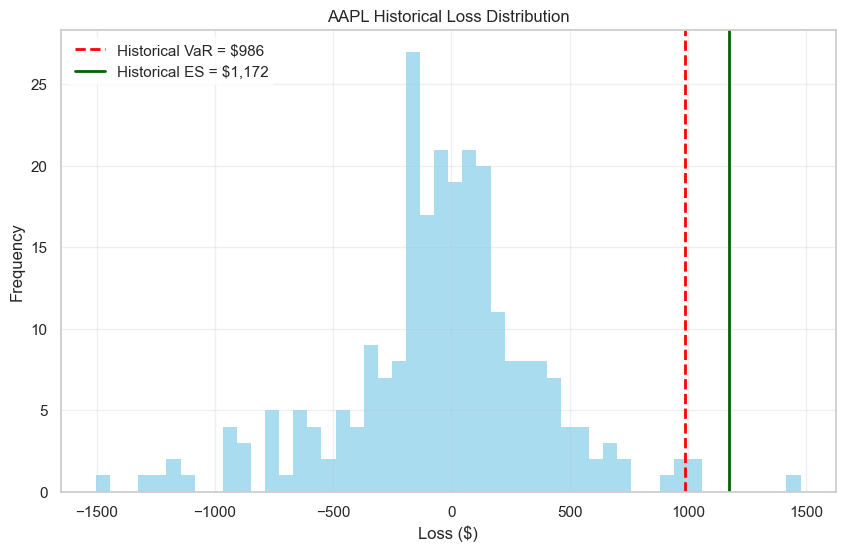

In [34]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ---------------------------------------------------
# Settings
# ---------------------------------------------------

ticker = "AAPL"
shares = 100
confidence = 0.99
horizon_days = 10
n_sim = 50000

# ---------------------------------------------------
# Download stock data
# ---------------------------------------------------

prices = yf.download(
    ticker,
    period="1y",
    interval="1d",
    auto_adjust=True
)["Close"]

if isinstance(prices, pd.DataFrame):
    prices = prices[ticker]

# ---------------------------------------------------
# Returns
# ---------------------------------------------------

returns = prices.pct_change().dropna()

mu = returns.mean()
sigma = returns.std()

current_price = prices.iloc[-1]
portfolio_value = current_price * shares

# ---------------------------------------------------
# 1. Historical VaR and ES
# ---------------------------------------------------

historical_pnl = portfolio_value * returns
historical_losses = -historical_pnl

historical_var = np.percentile(
    historical_losses,
    confidence * 100
)

tail_losses = historical_losses[historical_losses >= historical_var]

historical_es = tail_losses.mean()

# ---------------------------------------------------
# 2. Parametric VaR
# ---------------------------------------------------

z = norm.ppf(confidence)

parametric_var = (
    portfolio_value
    * sigma
    * np.sqrt(horizon_days)
    * z
)

# ---------------------------------------------------
# 3. Monte Carlo VaR
# ---------------------------------------------------

simulated_returns = np.random.normal(
    loc=mu * horizon_days,
    scale=sigma * np.sqrt(horizon_days),
    size=n_sim
)

simulated_prices = current_price * (1 + simulated_returns)

simulated_values = simulated_prices * shares

mc_pnl = simulated_values - portfolio_value

mc_losses = -mc_pnl

mc_var = np.percentile(
    mc_losses,
    confidence * 100
)

# ---------------------------------------------------
# Results table
# ---------------------------------------------------

comparison_df = pd.DataFrame({
    "Method": [
        "Historical VaR",
        "Historical ES",
        "Parametric VaR",
        "Monte Carlo VaR"
    ],
    "Risk Value": [
        historical_var,
        historical_es,
        parametric_var,
        mc_var
    ]
})

print("Ticker:", ticker)
print("Current Price:", current_price)
print("Shares:", shares)
print("Portfolio Value:", portfolio_value)
print("\n", comparison_df)

# ---------------------------------------------------
# Bar chart comparison
# ---------------------------------------------------

plt.figure(figsize=(11, 6))

bars = plt.bar(
    comparison_df["Method"],
    comparison_df["Risk Value"],
    color=["skyblue", "orange", "green", "purple"]
)

for bar, val in zip(bars, comparison_df["Risk Value"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val * 1.01,
        f"${val:,.0f}",
        ha="center"
    )

plt.title(
    f"{ticker} Stock Risk Methodology Comparison\n"
    f"{int(confidence*100)}% Confidence, {horizon_days}-Day Horizon"
)

plt.ylabel("Risk Value ($)")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

# ---------------------------------------------------
# Loss distribution graph
# ---------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    historical_losses,
    bins=50,
    alpha=0.7,
    color="skyblue"
)

plt.axvline(
    historical_var,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Historical VaR = ${historical_var:,.0f}"
)

plt.axvline(
    historical_es,
    color="darkgreen",
    linestyle="-",
    linewidth=2,
    label=f"Historical ES = ${historical_es:,.0f}"
)

plt.title(f"{ticker} Historical Loss Distribution")
plt.xlabel("Loss ($)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Risk Methodology Comparison

                         Regime  Historical VaR  Historical ES  \
0         2008 Financial Crisis         26.1285        36.2300   
1           COVID Crisis (2020)        806.0210       990.0629   
2  Rate-Hike Regime (2022-2023)        914.3921     1,034.7848   
3     Normal Market (2023-2024)        533.3568       717.4795   

   Parametric VaR  Monte Carlo VaR  
0         79.3105          81.1619  
1      2,219.7341       2,129.0999  
2      2,565.1501       2,501.6803  
3      1,760.4426       1,412.9372  


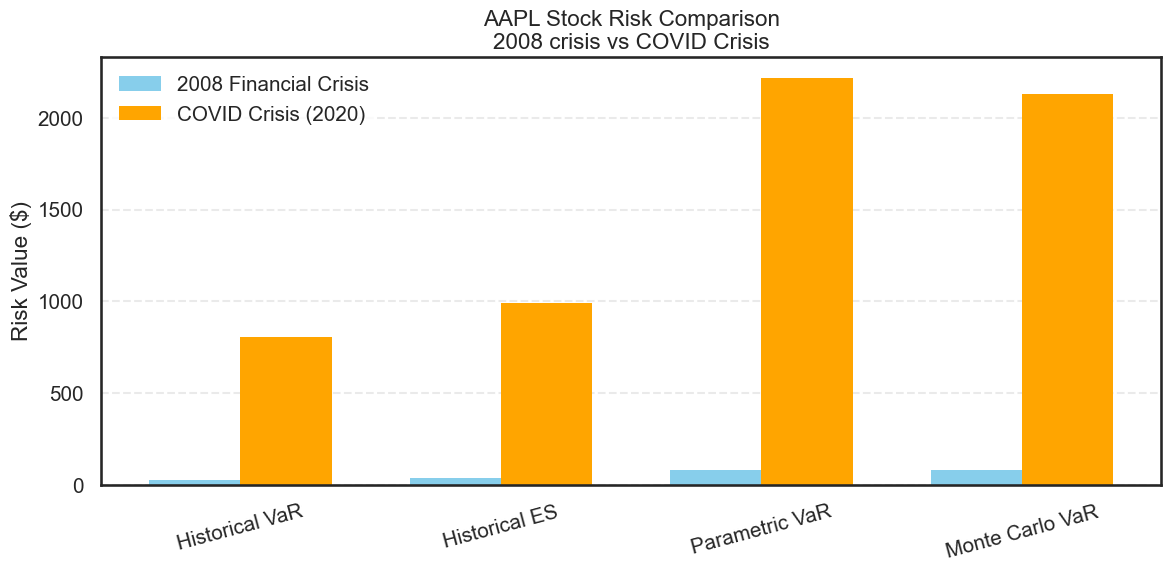

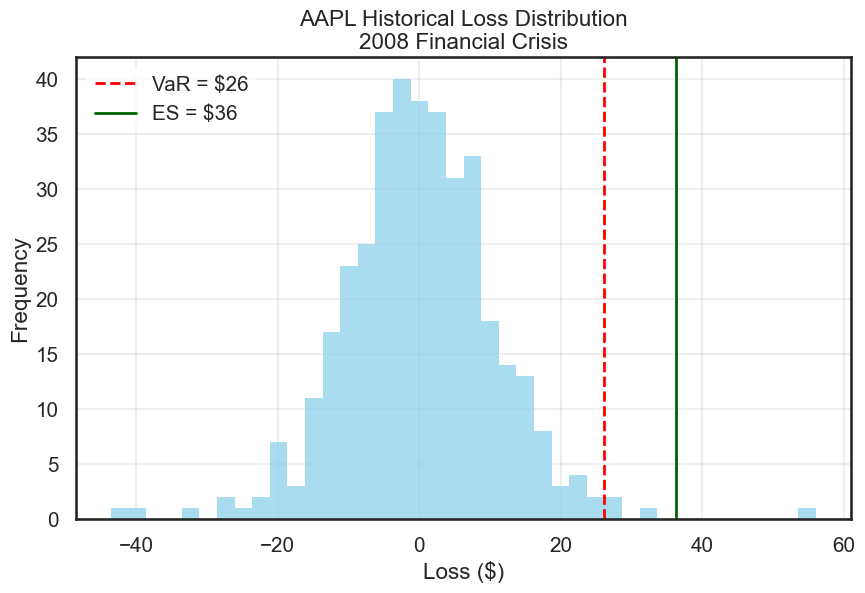

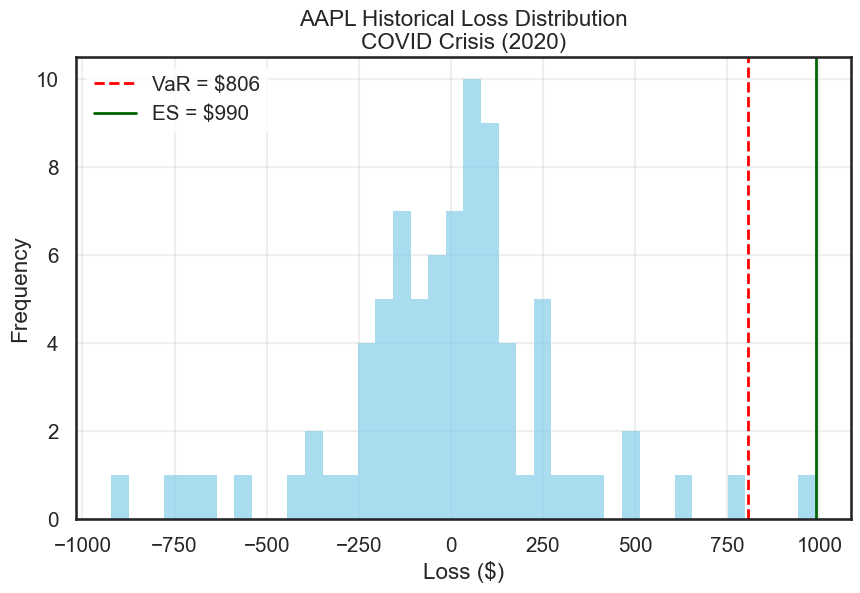

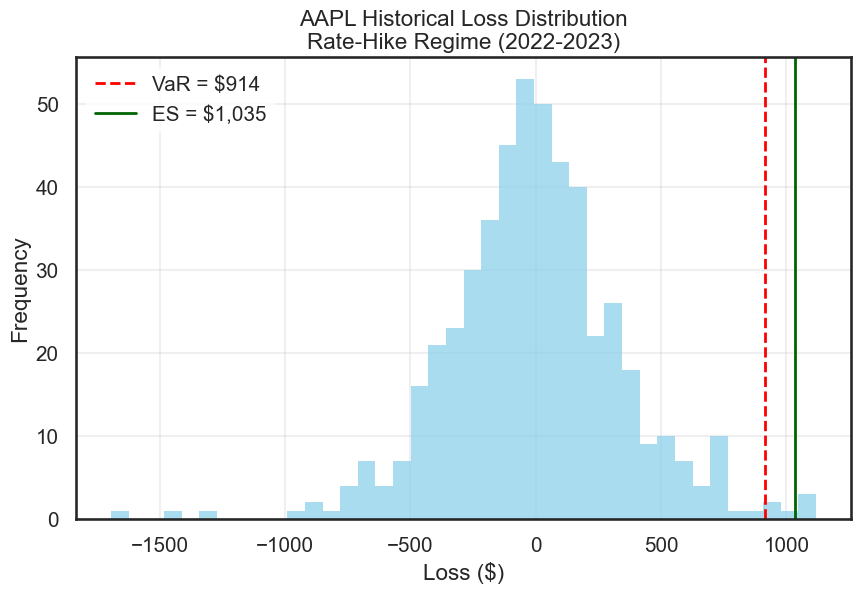

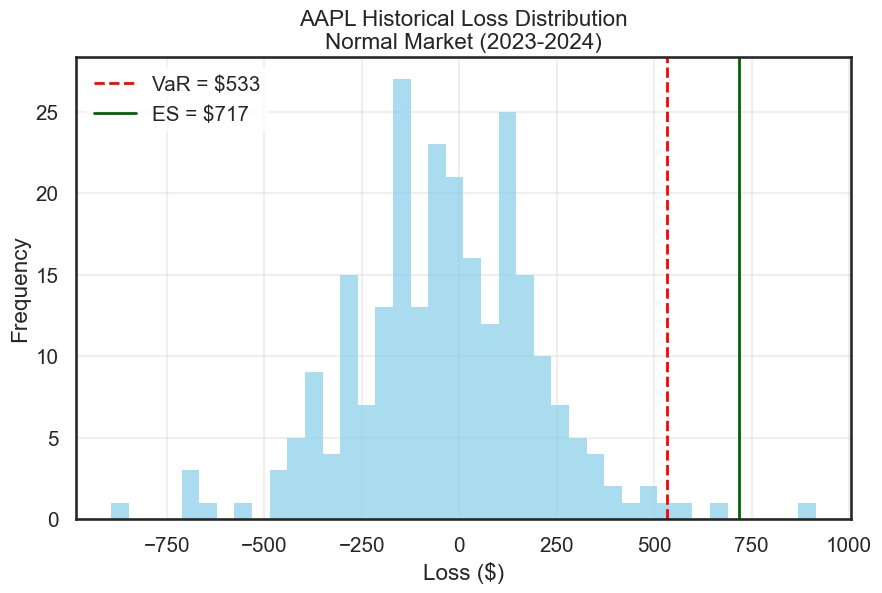

In [105]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ---------------------------------------------------
# Settings
# ---------------------------------------------------

ticker = "AAPL"
shares = 100
confidence = 0.99
horizon_days = 10
n_sim = 50000

# ---------------------------------------------------
# Market regimes
# ---------------------------------------------------

periods = {
    "2008 Financial Crisis": (
        "2007-10-01",
        "2009-03-31"
    ),

    "COVID Crisis (2020)": (
        "2020-02-01",
        "2020-06-01"
    ),

    "Rate-Hike Regime (2022-2023)": (
        "2022-01-01",
        "2023-12-31"
    ),

    "Normal Market (2023-2024)": (
        "2023-01-01",
        "2024-01-01"
    )
}
# ---------------------------------------------------
# Risk computation function
# ---------------------------------------------------

def compute_stock_risk(
    prices,
    shares,
    confidence,
    horizon_days,
    n_sim
):

    # ---------------------------------------------
    # Returns
    # ---------------------------------------------

    returns = prices.pct_change().dropna()

    mu = returns.mean()
    sigma = returns.std()

    # ---------------------------------------------
    # Portfolio value
    # ---------------------------------------------

    current_price = prices.iloc[-1]

    portfolio_value = current_price * shares

    # ---------------------------------------------
    # Historical VaR / ES
    # ---------------------------------------------

    historical_pnl = portfolio_value * returns

    historical_losses = -historical_pnl

    historical_var = np.percentile(
        historical_losses,
        confidence * 100
    )

    tail_losses = historical_losses[
        historical_losses >= historical_var
    ]

    historical_es = tail_losses.mean()

    # ---------------------------------------------
    # Parametric VaR
    # ---------------------------------------------

    z = norm.ppf(confidence)

    parametric_var = (
        portfolio_value
        * sigma
        * np.sqrt(horizon_days)
        * z
    )

    # ---------------------------------------------
    # Monte Carlo VaR
    # ---------------------------------------------

    simulated_returns = np.random.normal(
        loc=mu * horizon_days,
        scale=sigma * np.sqrt(horizon_days),
        size=n_sim
    )

    simulated_prices = current_price * (
        1 + simulated_returns
    )

    simulated_values = simulated_prices * shares

    mc_pnl = simulated_values - portfolio_value

    mc_losses = -mc_pnl

    mc_var = np.percentile(
        mc_losses,
        confidence * 100
    )

    # ---------------------------------------------
    # Return results
    # ---------------------------------------------
    
    return {
        "Portfolio Value": portfolio_value,
        "Historical VaR": historical_var,
        "Historical ES": historical_es,
        "Parametric VaR": parametric_var,
        "Monte Carlo VaR": mc_var,
        "Losses": historical_losses
    }

# ---------------------------------------------------
# Run each market regime
# ---------------------------------------------------

results = {}

for regime_name, (start, end) in periods.items():

    prices = yf.download(
        ticker,
        start=start,
        end=end,
        auto_adjust=True
    )["Close"]

    # Convert dataframe -> series if needed
    if isinstance(prices, pd.DataFrame):
        prices = prices[ticker]

    results[regime_name] = compute_stock_risk(
        prices,
        shares,
        confidence,
        horizon_days,
        n_sim
    )

# ---------------------------------------------------
# Comparison table
# ---------------------------------------------------

comparison_df = pd.DataFrame([
    {
        "Regime": regime,
        "Historical VaR": data["Historical VaR"],
        "Historical ES": data["Historical ES"],
        "Parametric VaR": data["Parametric VaR"],
        "Monte Carlo VaR": data["Monte Carlo VaR"]
    }
    for regime, data in results.items()
])

print("\nRisk Methodology Comparison\n")

print(comparison_df)

# ---------------------------------------------------
# Bar chart comparison
# ---------------------------------------------------

methods = [
    "Historical VaR",
    "Historical ES",
    "Parametric VaR",
    "Monte Carlo VaR"
]

x = np.arange(len(methods))

width = 0.35

plt.figure(figsize=(12, 6))

# Normal regime
plt.bar(
    x - width/2,
    comparison_df.loc[0, methods],
    width,
    label=comparison_df.loc[0, "Regime"],
    color="skyblue"
)

# Crisis regime
plt.bar(
    x + width/2,
    comparison_df.loc[1, methods],
    width,
    label=comparison_df.loc[1, "Regime"],
    color="orange"
)

# ---------------------------------------------
# Formatting
# ---------------------------------------------

plt.xticks(
    x,
    methods,
    rotation=15
)

plt.ylabel("Risk Value ($)")

plt.title(
    f"{ticker} Stock Risk Comparison\n"
    "2008 crisis vs COVID Crisis"
)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()

# ---------------------------------------------------
# Histogram graphs
# ---------------------------------------------------

for regime, data in results.items():

    losses = data["Losses"]

    plt.figure(figsize=(10, 6))

    # ---------------------------------------------
    # Histogram
    # ---------------------------------------------

    plt.hist(
        losses,
        bins=40,
        alpha=0.7,
        color="skyblue"
    )

    # ---------------------------------------------
    # VaR line
    # ---------------------------------------------

    plt.axvline(
        data["Historical VaR"],
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"VaR = ${data['Historical VaR']:,.0f}"
    )

    # ---------------------------------------------
    # ES line
    # ---------------------------------------------

    plt.axvline(
        data["Historical ES"],
        color="darkgreen",
        linestyle="-",
        linewidth=2,
        label=f"ES = ${data['Historical ES']:,.0f}"
    )

    # ---------------------------------------------
    # Formatting
    # ---------------------------------------------

    plt.title(
        f"{ticker} Historical Loss Distribution\n{regime}"
    )

    plt.xlabel("Loss ($)")
    plt.ylabel("Frequency")

    plt.legend()

    plt.grid(alpha=0.3)

    plt.show()

Insights: We can see how covid crisis 2020 had a much higher losses, while both 2008 and covid time periods are considered as market regime changes. So this graph indicates how just copmuting historical losses may not be enough to validate or detect the market regime changes. Even for the distribution, when looking at thie distribution paths, it's not clear whether normal market is much different from 2008. So this indicates the importance of using Monte Carlo, Parametric VAR, and historical ES to compute for the market regime changes. 

In our testing methodologies, we test our risk models of Monte Carlo, Parametric VAR, histroical ES for the two datasets including Options, and Stock. For the Stock, the computation methodology is: 

For the Options, we design strategies such that it considers the circumstances of trades that are either long or short considering each of the scenarios. The long and short options can have an impact to the trades 

In addition, we add repricing strategies for the options as to properly capture the nonlinear behavior of options under different market conditions. Rather than approximating option risk through linear sensitivity measures such as delta-normal VaR, the model fully reprices the option under every simulated stock scenario using the Black–Scholes pricing framework. This approach allows the analysis to incorporate important option characteristics including convexity (gamma), time decay (theta), asymmetric payoff structures, and expiration effects. Afterwards, future stock prices are then simulated using a Geometric Brownian Motion process over the selected VaR horizon. 

The repriced option values are converted into simulated portfolio profit-and-loss distributions, from which Value-at-Risk and Expected Shortfall are computed. Repricing becomes a cirtical risk strategey for options when expecially during market change when tail risks become significantly noticeable. Next, we head into using our core internal models to test in fixed portfolios and see how the market regiem change is captured incredibly well for stocks. 


Risk Methodology Comparison
                         Regime  Current Price  Shares Used  Portfolio Value  \
0     Normal Market (2023-2024)         190.38       525.28           100000   
1           COVID Crisis (2020)          76.96     1,299.38           100000   
2         2008 Financial Crisis           3.13    31,969.79           100000   
3  Rate-Hike Regime (2022-2023)         190.38       525.28           100000   

   Historical VaR  Historical ES  Parametric VaR  Monte Carlo VaR  
0        2,801.60       3,768.76        9,247.22         7,205.13  
1       10,473.33      12,864.69       28,842.82        24,722.95  
2        8,353.20      11,582.64       25,355.38        23,311.69  
3        4,803.09       5,435.51       13,474.19        12,496.30  


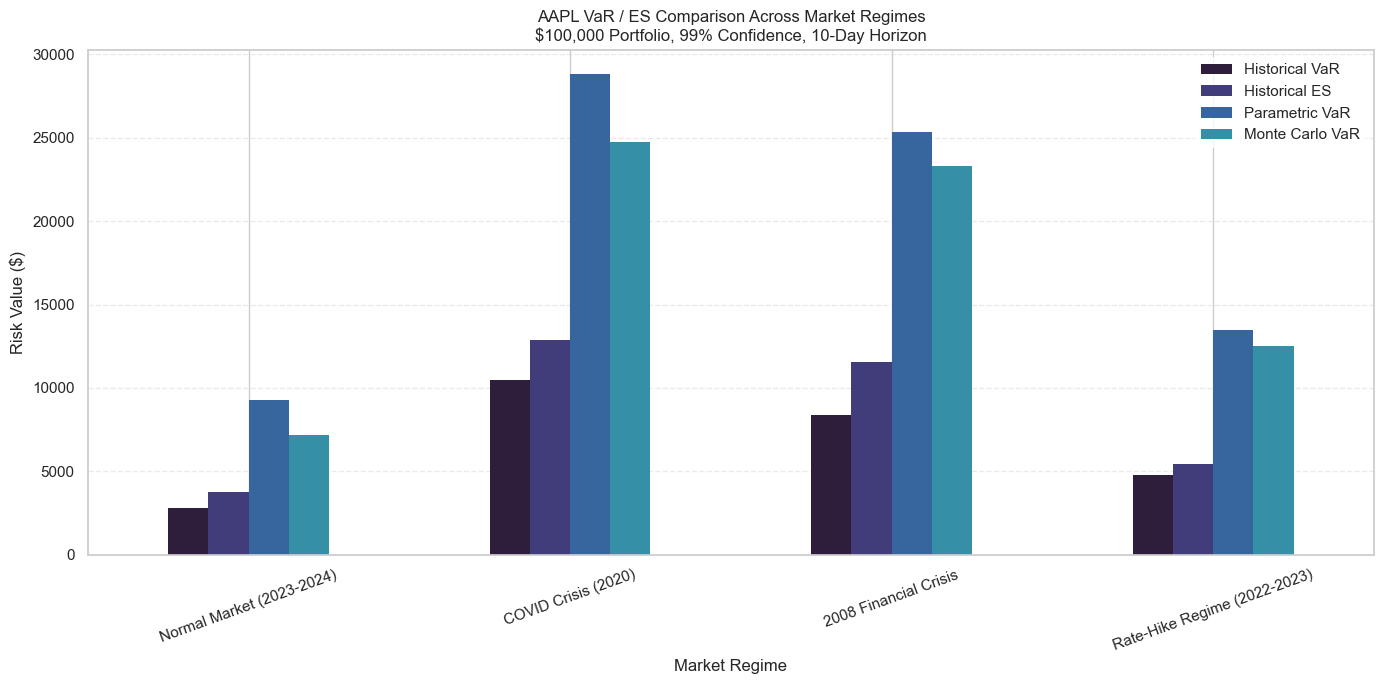

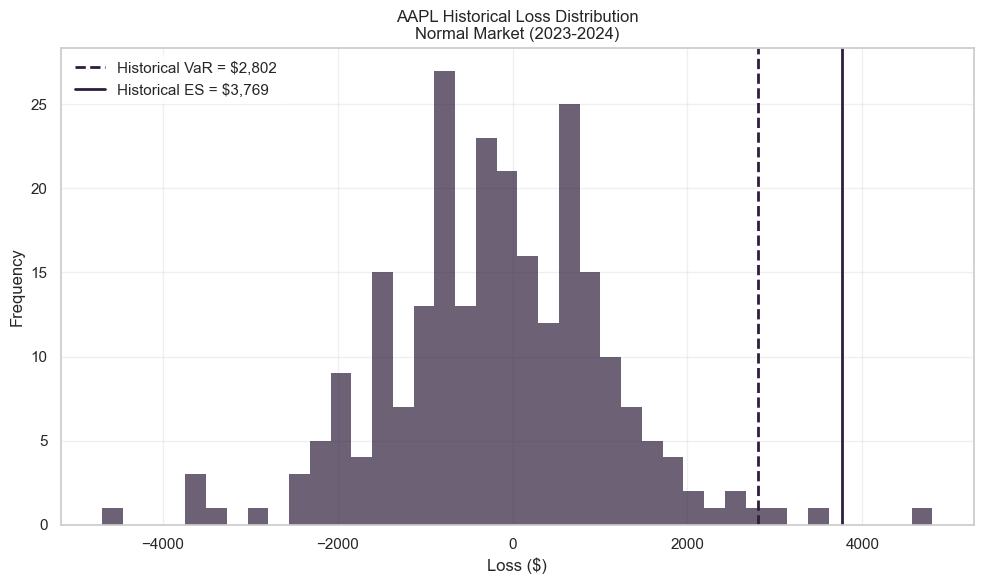

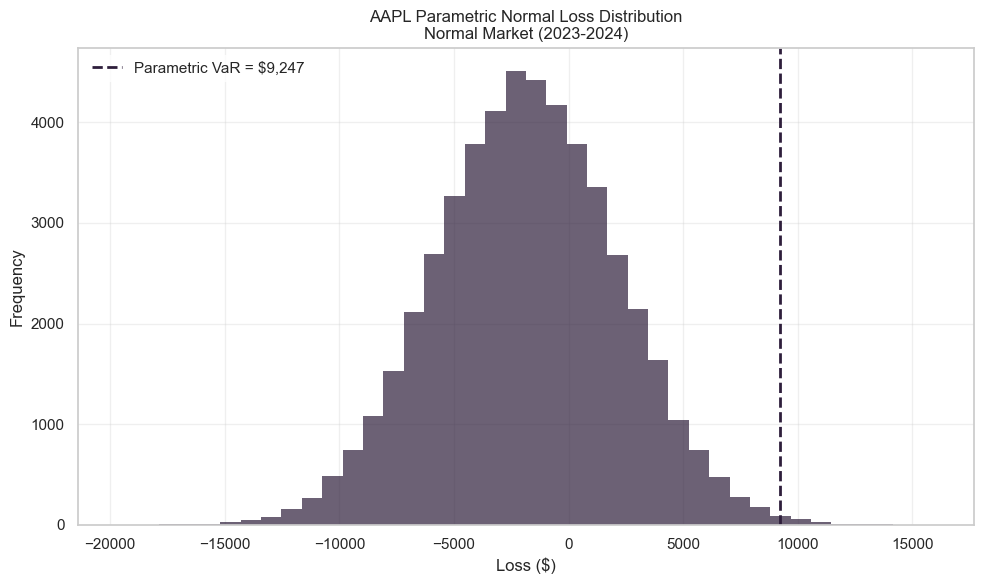

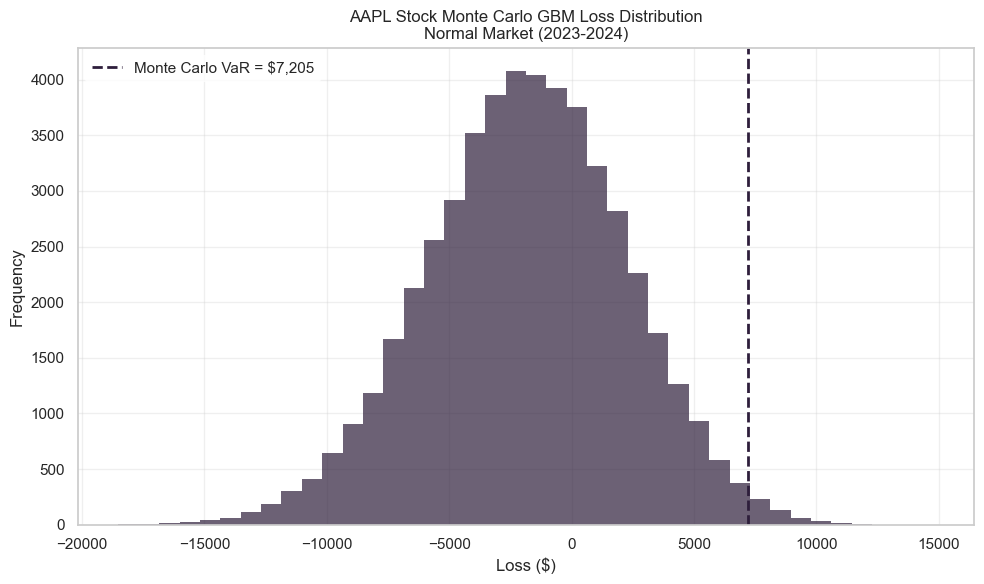

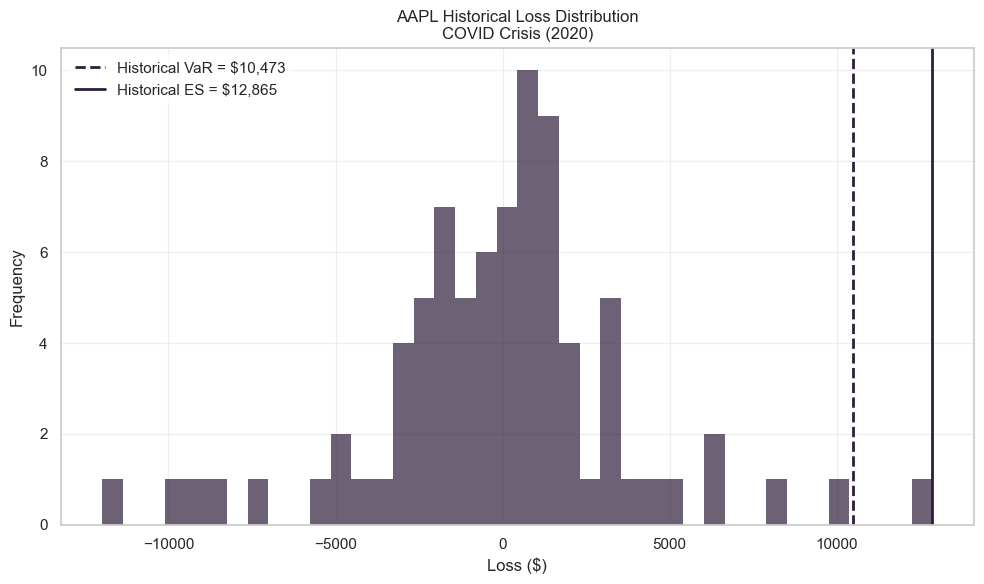

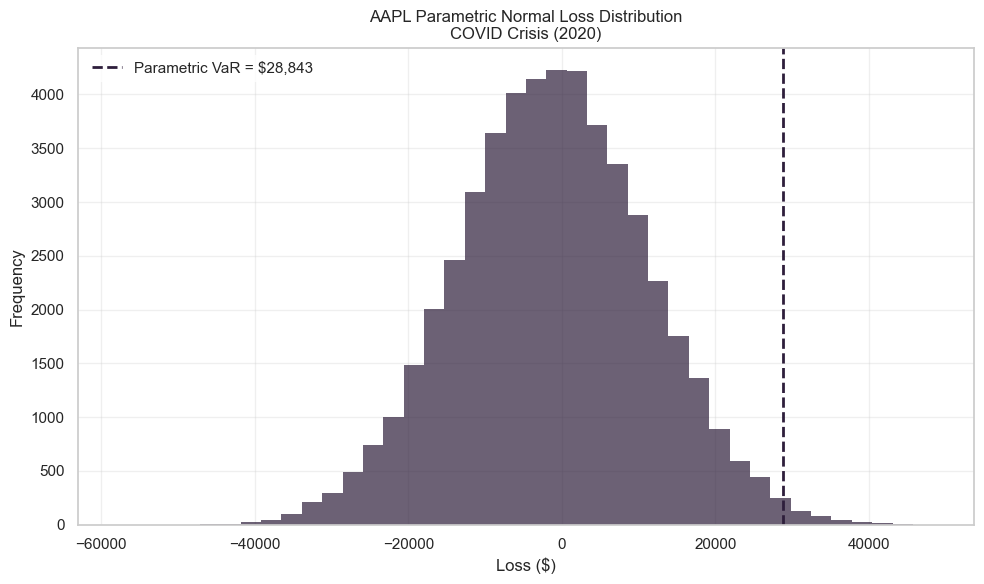

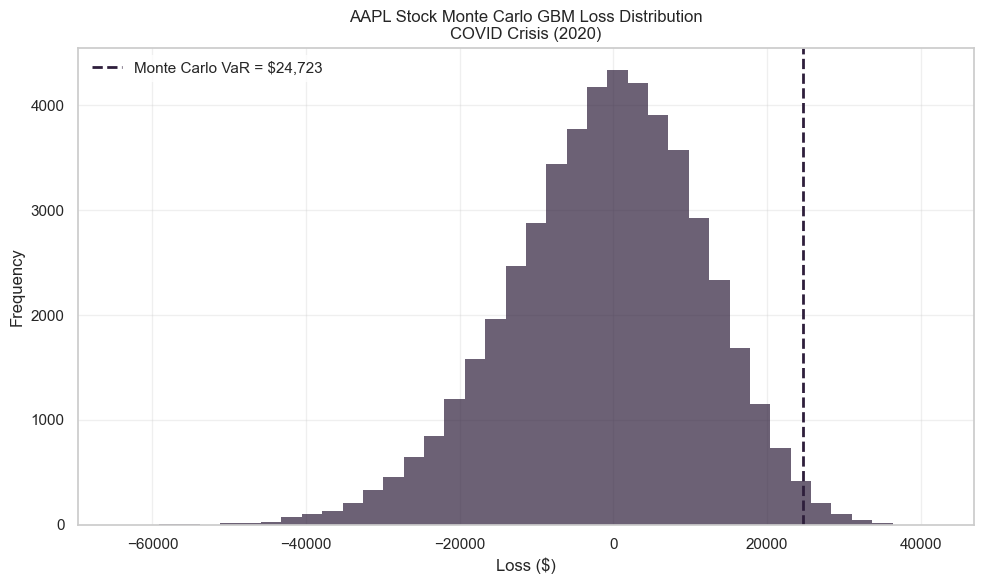

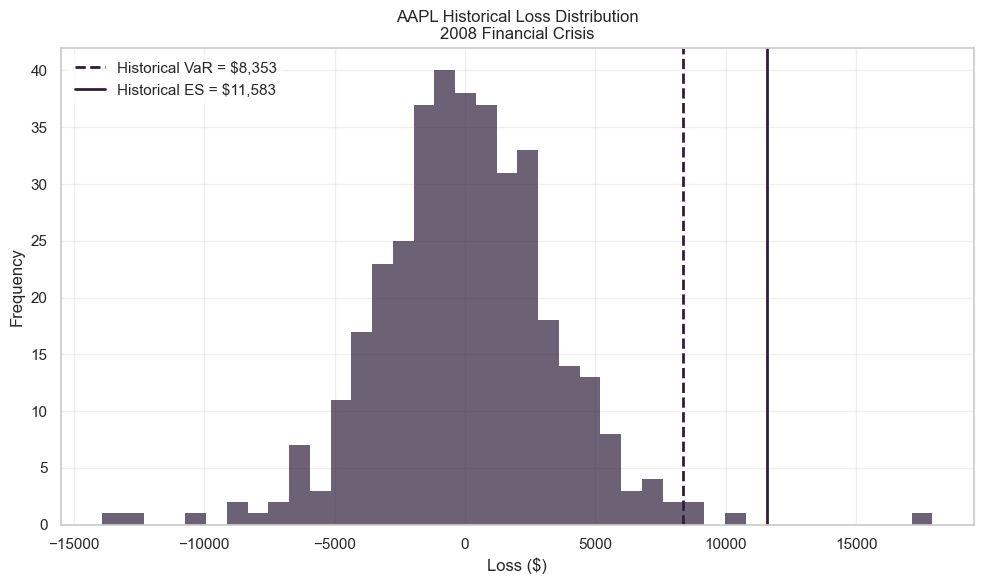

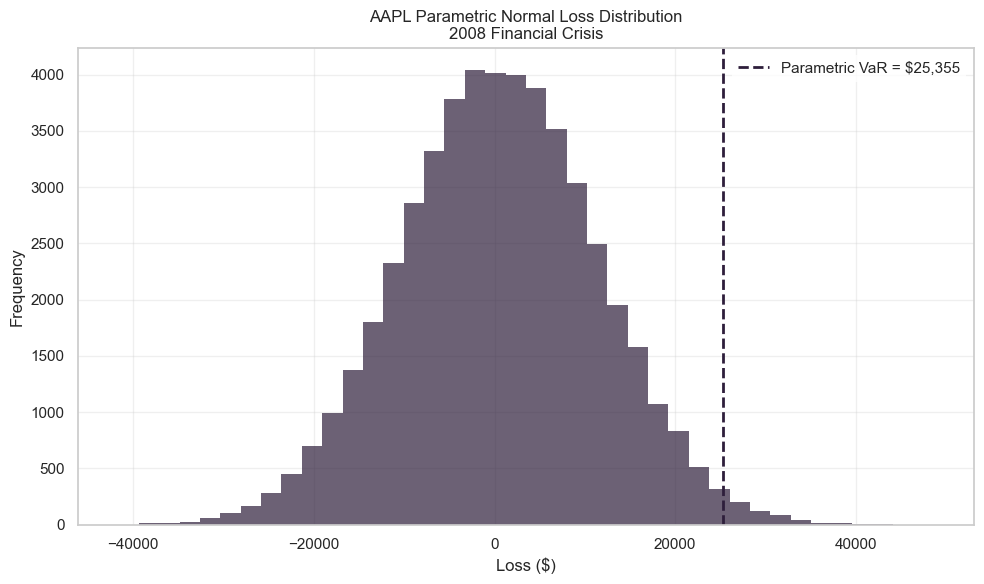

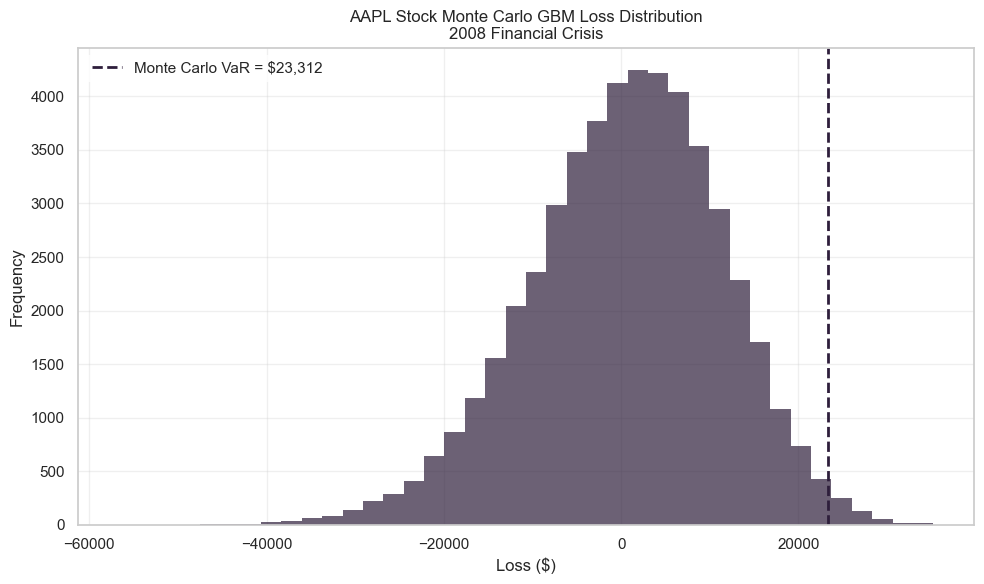

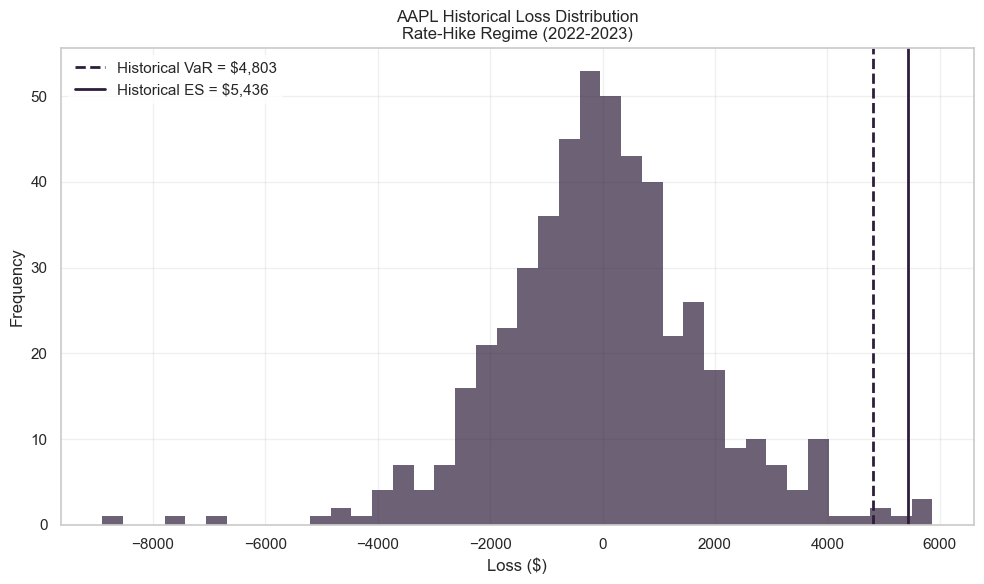

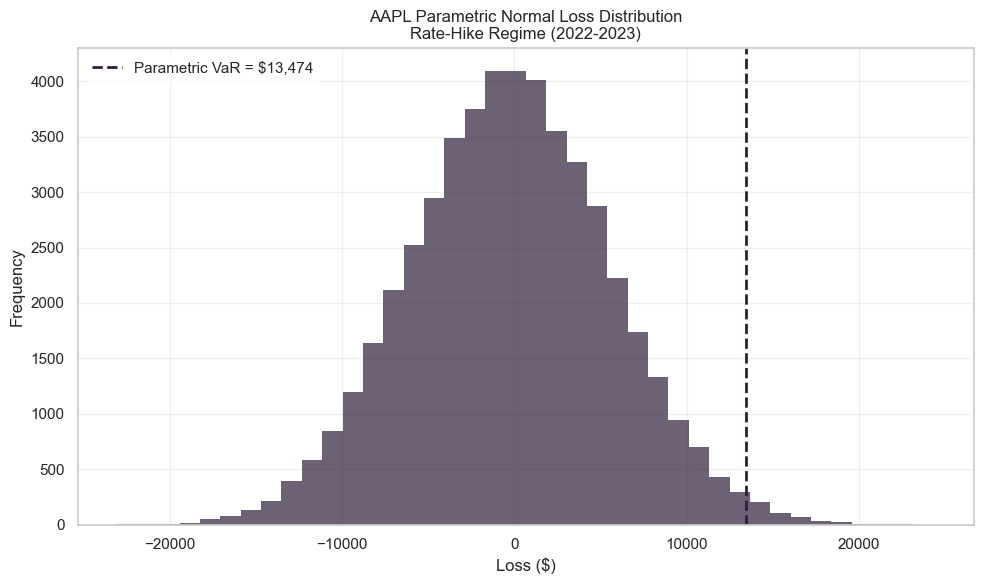

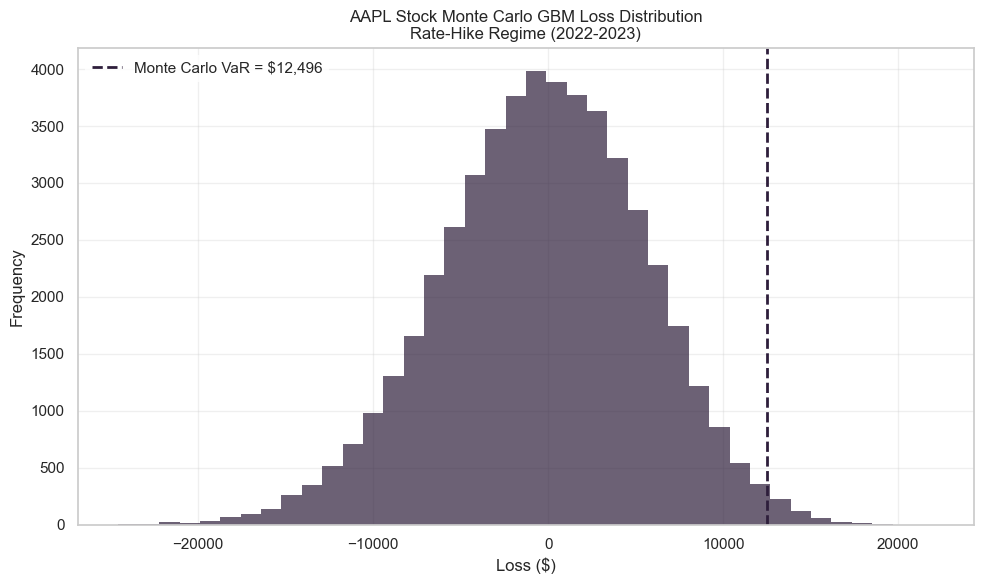

In [35]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Settings

ticker = "AAPL"
portfolio_value_target = 100000   # Same capital exposure for every regime
confidence = 0.99
horizon_days = 10
n_sim = 50000
np.random.seed(42)

# Market regimes
periods = {
    "Normal Market (2023-2024)": ("2023-01-01", "2024-01-01"),
    "COVID Crisis (2020)": ("2020-02-01", "2020-06-01"),
    "2008 Financial Crisis": ("2007-10-01", "2009-03-31"),
    "Rate-Hike Regime (2022-2023)": ("2022-01-01", "2023-12-31")
}

# Risk computation function

def compute_risk_distributions(
    prices,
    portfolio_value_target,
    confidence,
    horizon_days,
    n_sim
):

    returns = prices.pct_change().dropna()

    mu_daily = returns.mean()
    sigma_daily = returns.std()

    current_price = prices.iloc[-1]

    # Fixed portfolio value for fair comparison
    portfolio_value = portfolio_value_target

    # Shares adjust depending on stock price
    shares = portfolio_value_target / current_price

    # Historical VaR / ES

    historical_pnl = portfolio_value * returns
    historical_losses = -historical_pnl

    historical_var = np.percentile(
        historical_losses,
        confidence * 100
    )

    historical_es = historical_losses[
        historical_losses >= historical_var
    ].mean()

    # ---------------------------------------------------
    # Parametric VaR
    # ---------------------------------------------------

    z = norm.ppf(confidence)

    parametric_var = (
        portfolio_value
        * sigma_daily
        * np.sqrt(horizon_days)
        * z
    )

    parametric_returns = np.random.normal(
        loc=mu_daily * horizon_days,
        scale=sigma_daily * np.sqrt(horizon_days),
        size=n_sim
    )

    parametric_losses = -portfolio_value * parametric_returns

    # ---------------------------------------------------
    # Monte Carlo VaR using GBM
    # ---------------------------------------------------

    Z = np.random.normal(size=n_sim)

    simulated_prices = current_price * np.exp(
        (mu_daily - 0.5 * sigma_daily**2) * horizon_days
        + sigma_daily * np.sqrt(horizon_days) * Z
    )

    simulated_values = simulated_prices * shares

    mc_pnl = simulated_values - portfolio_value
    mc_losses = -mc_pnl

    mc_var = np.percentile(
        mc_losses,
        confidence * 100
    )

    return {
        "Current Price": current_price,
        "Shares": shares,
        "Portfolio Value": portfolio_value,

        "Historical Losses": historical_losses,
        "Historical VaR": historical_var,
        "Historical ES": historical_es,

        "Parametric Losses": parametric_losses,
        "Parametric VaR": parametric_var,

        "Monte Carlo Losses": mc_losses,
        "Monte Carlo VaR": mc_var
    }

# ---------------------------------------------------
# Run analysis
# ---------------------------------------------------

results = {}

for regime_name, (start, end) in periods.items():

    print(f"Downloading {regime_name}...")

    prices = yf.download(
        ticker,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False
    )["Close"]

    if isinstance(prices, pd.DataFrame):
        prices = prices[ticker]

    results[regime_name] = compute_risk_distributions(
        prices,
        portfolio_value_target,
        confidence,
        horizon_days,
        n_sim
    )

# ---------------------------------------------------
# Comparison table
# ---------------------------------------------------

comparison_df = pd.DataFrame([
    {
        "Regime": regime,
        "Current Price": data["Current Price"],
        "Shares Used": data["Shares"],
        "Portfolio Value": data["Portfolio Value"],
        "Historical VaR": data["Historical VaR"],
        "Historical ES": data["Historical ES"],
        "Parametric VaR": data["Parametric VaR"],
        "Monte Carlo VaR": data["Monte Carlo VaR"]
    }
    for regime, data in results.items()
])

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("\nRisk Methodology Comparison")
print(comparison_df)

# ---------------------------------------------------
# Bar chart comparison
# ---------------------------------------------------

methods = [
    "Historical VaR",
    "Historical ES",
    "Parametric VaR",
    "Monte Carlo VaR"
]

comparison_df.set_index("Regime")[methods].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    f"{ticker} VaR / ES Comparison Across Market Regimes\n"
    f"${portfolio_value_target:,.0f} Portfolio, "
    f"{confidence:.0%} Confidence, {horizon_days}-Day Horizon"
)

plt.ylabel("Risk Value ($)")
plt.xlabel("Market Regime")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# Distribution graphs
# ---------------------------------------------------

for regime, data in results.items():

    # Historical distribution
    plt.figure(figsize=(10, 6))

    plt.hist(
        data["Historical Losses"],
        bins=40,
        alpha=0.7
    )

    plt.axvline(
        data["Historical VaR"],
        linestyle="--",
        linewidth=2,
        label=f"Historical VaR = ${data['Historical VaR']:,.0f}"
    )

    plt.axvline(
        data["Historical ES"],
        linestyle="-",
        linewidth=2,
        label=f"Historical ES = ${data['Historical ES']:,.0f}"
    )

    plt.title(f"{ticker} Historical Loss Distribution\n{regime}")
    plt.xlabel("Loss ($)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Parametric distribution
    plt.figure(figsize=(10, 6))

    plt.hist(
        data["Parametric Losses"],
        bins=40,
        alpha=0.7
    )

    plt.axvline(
        data["Parametric VaR"],
        linestyle="--",
        linewidth=2,
        label=f"Parametric VaR = ${data['Parametric VaR']:,.0f}"
    )

    plt.title(f"{ticker} Parametric Normal Loss Distribution\n{regime}")
    plt.xlabel("Loss ($)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Monte Carlo GBM distribution
    plt.figure(figsize=(10, 6))

    plt.hist(
        data["Monte Carlo Losses"],
        bins=40,
        alpha=0.7
    )
    
    plt.axvline(
        data["Monte Carlo VaR"],
        linestyle="--",
        linewidth=2,
        label=f"Monte Carlo VaR = ${data['Monte Carlo VaR']:,.0f}"
    )
    plt.title(f"{ticker} Stock Monte Carlo GBM Loss Distribution\n{regime}")
    plt.xlabel("Loss ($)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

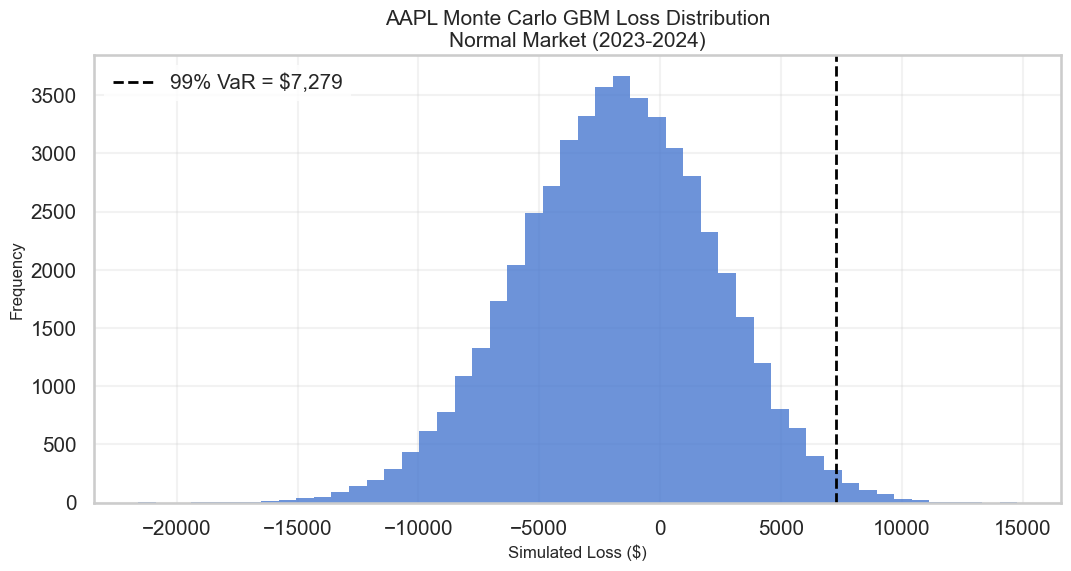

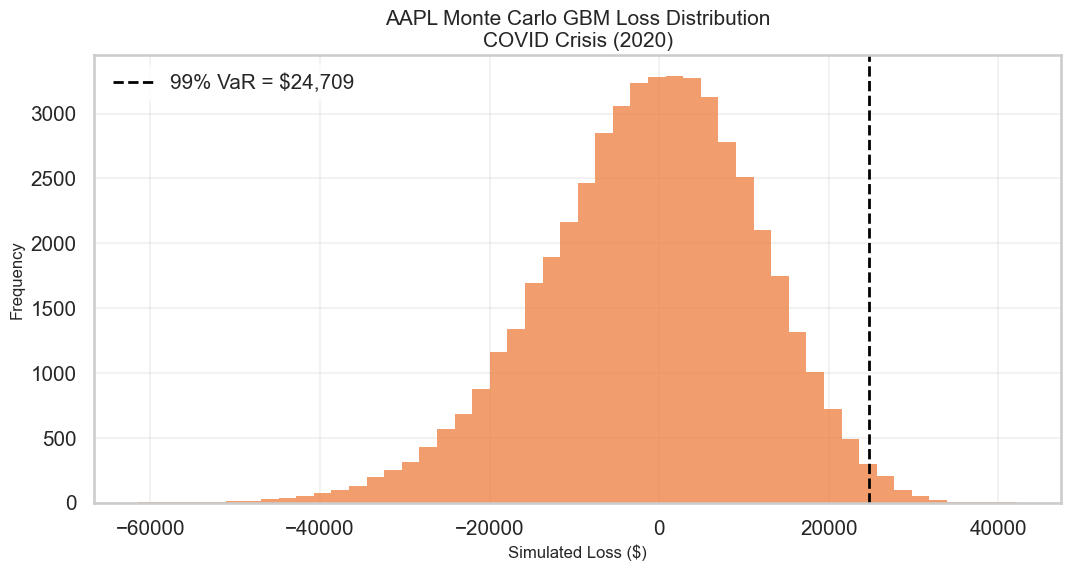

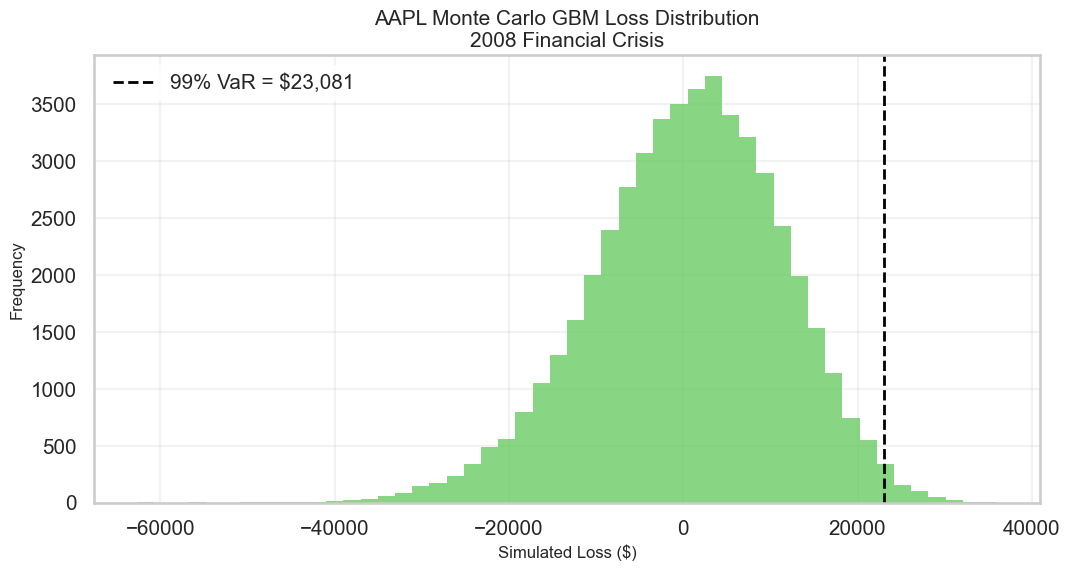

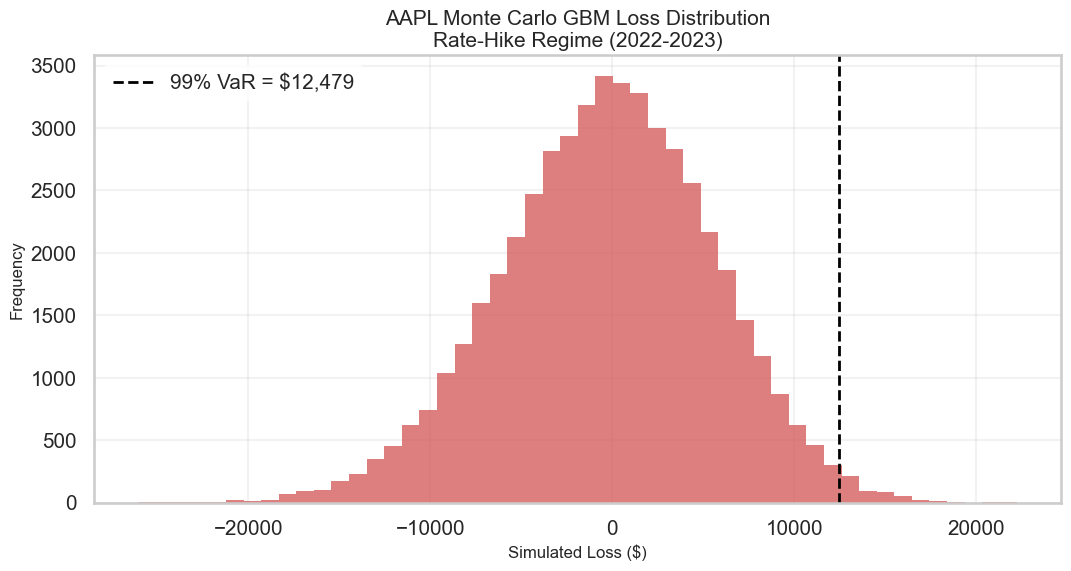

In [110]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# ---------------------------------------------------
# Seaborn Style
# ---------------------------------------------------

sns.set_style("whitegrid")

# Different seaborn palettes:
# "deep"
# "muted"
# "pastel"
# "bright"
# "dark"
# "colorblind"

palette = sns.color_palette("muted")

# ---------------------------------------------------
# Settings
# ---------------------------------------------------

ticker = "AAPL"
portfolio_value_target = 100000
confidence = 0.99
horizon_days = 10
n_sim = 50000

np.random.seed(42)

# ---------------------------------------------------
# Market regimes
# ---------------------------------------------------

periods = {
    "Normal Market (2023-2024)": ("2023-01-01", "2024-01-01"),
    "COVID Crisis (2020)": ("2020-02-01", "2020-06-01"),
    "2008 Financial Crisis": ("2007-10-01", "2009-03-31"),
    "Rate-Hike Regime (2022-2023)": ("2022-01-01", "2023-12-31")
}

# ---------------------------------------------------
# Risk computation
# ---------------------------------------------------

def compute_mc_distribution(
    prices,
    portfolio_value_target,
    confidence,
    horizon_days,
    n_sim
):

    returns = prices.pct_change().dropna()

    mu_daily = returns.mean()
    sigma_daily = returns.std()

    current_price = prices.iloc[-1]

    portfolio_value = portfolio_value_target

    shares = portfolio_value / current_price

    # ---------------------------------------------------
    # Monte Carlo GBM simulation
    # ---------------------------------------------------

    Z = np.random.normal(size=n_sim)

    simulated_prices = current_price * np.exp(
        (mu_daily - 0.5 * sigma_daily**2) * horizon_days
        + sigma_daily * np.sqrt(horizon_days) * Z
    )

    simulated_values = simulated_prices * shares

    mc_pnl = simulated_values - portfolio_value

    mc_losses = -mc_pnl

    mc_var = np.percentile(
        mc_losses,
        confidence * 100
    )

    return mc_losses, mc_var

# ---------------------------------------------------
# Run simulations
# ---------------------------------------------------

results = {}

for regime_name, (start, end) in periods.items():

    print(f"Downloading {regime_name}...")

    prices = yf.download(
        ticker,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False
    )["Close"]

    if isinstance(prices, pd.DataFrame):
        prices = prices[ticker]

    mc_losses, mc_var = compute_mc_distribution(
        prices,
        portfolio_value_target,
        confidence,
        horizon_days,
        n_sim
    )

    results[regime_name] = {
        "losses": mc_losses,
        "var": mc_var
    }

# ---------------------------------------------------
# Monte Carlo Distribution Plots
# ---------------------------------------------------

for i, (regime, data) in enumerate(results.items()):

    plt.figure(figsize=(11, 6))

    plt.hist(
        data["losses"],
        bins=50,
        alpha=0.80,
        color=palette[i],
        edgecolor="none"
    )

    plt.axvline(
        data["var"],
        linestyle="--",
        linewidth=2,
        color="black",
        label=f"99% VaR = ${data['var']:,.0f}"
    )

    plt.title(
        f"{ticker} Monte Carlo GBM Loss Distribution\n{regime}",
        fontsize=15
    )

    plt.xlabel("Simulated Loss ($)", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)

    plt.legend()

    plt.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

Insights about Stock analysis using Monte Carlo GBM: 

For stocks, we found out that using a fixed portfolio value fits better instead of using actual shares of stock prices that will be worth differently For example, holding 100 shares of Apple Inc. during 2008 versus 2024 represents very different dollar investments. After testing our strategies, we noticed that when shares were used, it wasn't able to detect the regime changes in 2008 as the values of stocks were so low. For this reason, we used fixed values of portfolio to incoporate and capture the market regime changes. We can see from the above graphs that our risk model succesfuly capture the market regime changes with high Risk Value as well. 

Another result from our testing methodology captures market regime changes better in Monte Carlo VAR compared to Parametric VAR. For example, we can see from the above graph that parametric distributions assumes that the returns are normally distributed and can miss the skewness of the returns that can be a signal for the market regime change.  However, the monte carlo is better at capturing the skewness of the data since GBM pricing methodology capture sthe compounding behavior of exponential growth which can be critical in detecting similar patterns when market regime changes and market faces a downturn. 



In [112]:
!pip isntall arch

ERROR: unknown command "isntall" - maybe you meant "install"


Next, we experiment with extensions of Monte Carlo using GMB Monte Carlo, Historical boostrap monte carlo, and garch monte carlo. 


Monte Carlo Methodology Comparison
                         Regime  GBM Monte Carlo VaR  \
0     Normal Market (2023-2024)            72,791.89   
1           COVID Crisis (2020)           245,736.74   
2         2008 Financial Crisis           228,686.36   
3  Rate-Hike Regime (2022-2023)           124,113.41   

   Historical Bootstrap MC VaR  GARCH Monte Carlo VaR  
0                    73,216.24              58,883.36  
1                   259,248.22              22,037.89  
2                   244,447.47             215,119.29  
3                   126,012.03              66,776.33  


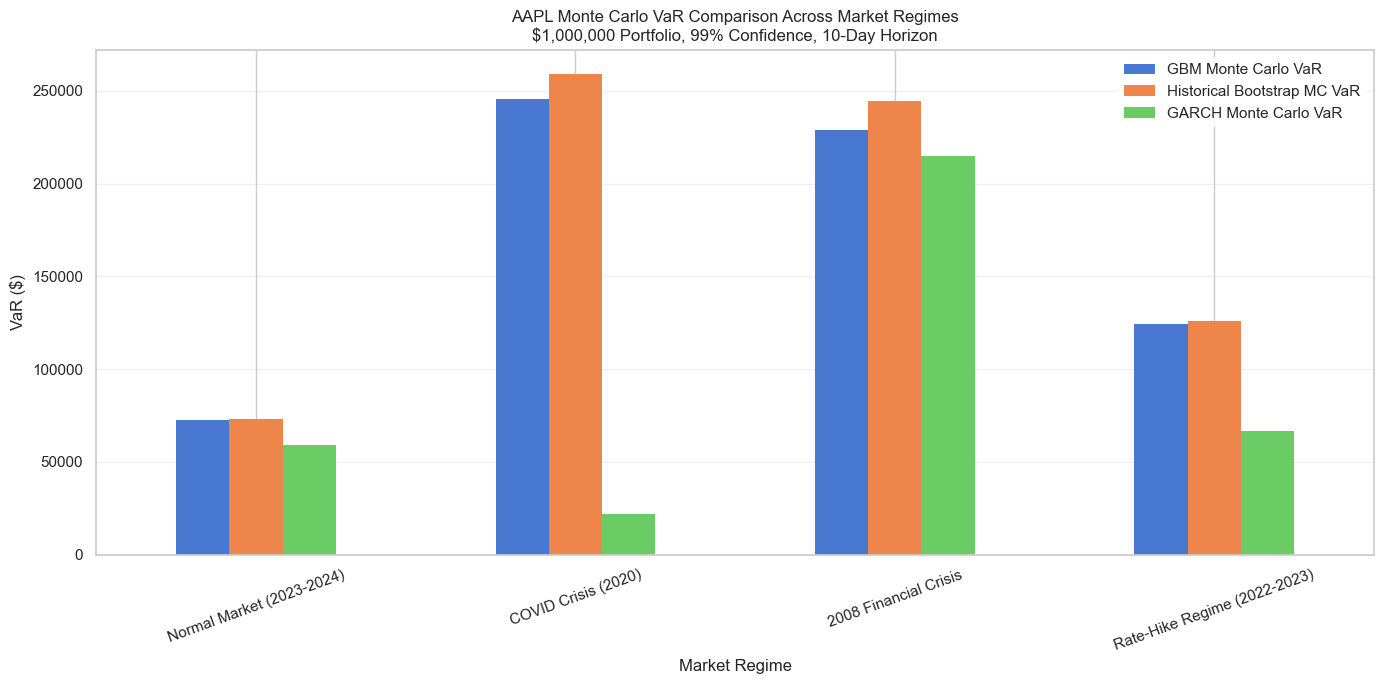

In [37]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from arch import arch_model

# ---------------------------------------------------
# Seaborn style
# ---------------------------------------------------

sns.set_style("whitegrid")
palette = sns.color_palette("muted")

# ---------------------------------------------------
# Settings
# ---------------------------------------------------

ticker = "AAPL"
portfolio_value_target = 1000000
confidence = 0.99
horizon_days = 10
n_sim = 50000

np.random.seed(42)

periods = {
    "Normal Market (2023-2024)": ("2023-01-01", "2024-01-01"),
    "COVID Crisis (2020)": ("2020-02-01", "2020-06-01"),
    "2008 Financial Crisis": ("2007-10-01", "2009-03-31"),
    "Rate-Hike Regime (2022-2023)": ("2022-01-01", "2023-12-31")
}

# ---------------------------------------------------
# Monte Carlo risk methods
# ---------------------------------------------------

def compute_mc_methods(prices):

    returns = prices.pct_change().dropna()

    mu_daily = returns.mean()
    sigma_daily = returns.std()

    current_price = prices.iloc[-1]
    portfolio_value = portfolio_value_target
    shares = portfolio_value / current_price

    # ===================================================
    # 1. GBM Monte Carlo
    # ===================================================

    Z = np.random.normal(size=n_sim)

    simulated_prices_gbm = current_price * np.exp(
        (mu_daily - 0.5 * sigma_daily**2) * horizon_days
        + sigma_daily * np.sqrt(horizon_days) * Z
    )

    simulated_values_gbm = simulated_prices_gbm * shares
    gbm_losses = -(simulated_values_gbm - portfolio_value)

    gbm_var = np.percentile(
        gbm_losses,
        confidence * 100
    )

    # 2. Historical Bootstrapping Monte Carlo

    bootstrapped_returns = np.random.choice(
        returns.values,
        size=(n_sim, horizon_days),
        replace=True
    )

    cumulative_bootstrap_returns = np.prod(
        1 + bootstrapped_returns,
        axis=1
    ) - 1

    bootstrap_values = portfolio_value * (1 + cumulative_bootstrap_returns)
    bootstrap_losses = -(bootstrap_values - portfolio_value)

    bootstrap_var = np.percentile(
        bootstrap_losses,
        confidence * 100
    )

    # ===================================================
    # 3. GARCH Monte Carlo
    # ===================================================

    # arch works better when returns are scaled to percentage
    returns_pct = returns * 100

    garch_model = arch_model(
        returns_pct,
        mean="Constant",
        vol="GARCH",
        p=1,
        q=1,
        dist="normal"
    )

    garch_fit = garch_model.fit(disp="off")

    garch_forecast = garch_fit.forecast(
        horizon=horizon_days,
        simulations=n_sim,
        method="simulation"
    )

    # Simulated returns are in percentage terms
    garch_simulated_returns = (
        garch_forecast.simulations.values[-1, :, :] / 100
    )

    cumulative_garch_returns = np.prod(
        1 + garch_simulated_returns,
        axis=1
    ) - 1

    garch_values = portfolio_value * (1 + cumulative_garch_returns)
    garch_losses = -(garch_values - portfolio_value)

    garch_var = np.percentile(
        garch_losses,
        confidence * 100
    )

    return {
        "GBM Losses": gbm_losses,
        "GBM VaR": gbm_var,

        "Bootstrap Losses": bootstrap_losses,
        "Bootstrap VaR": bootstrap_var,

        "GARCH Losses": garch_losses,
        "GARCH VaR": garch_var
    }

# ---------------------------------------------------
# Run analysis
# ---------------------------------------------------

results = {}

for regime_name, (start, end) in periods.items():

    print(f"Downloading {regime_name}...")

    prices = yf.download(
        ticker,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False
    )["Close"]

    if isinstance(prices, pd.DataFrame):
        prices = prices[ticker]

    results[regime_name] = compute_mc_methods(prices)

# ---------------------------------------------------
# Comparison table
# ---------------------------------------------------

comparison_df = pd.DataFrame([
    {
        "Regime": regime,
        "GBM Monte Carlo VaR": data["GBM VaR"],
        "Historical Bootstrap MC VaR": data["Bootstrap VaR"],
        "GARCH Monte Carlo VaR": data["GARCH VaR"]
    }
    for regime, data in results.items()
])

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("\nMonte Carlo Methodology Comparison")
print(comparison_df)

# ---------------------------------------------------
# Bar chart comparison
# ---------------------------------------------------

comparison_df.set_index("Regime").plot(
    kind="bar",
    figsize=(14, 7),
    color=palette[:3]
)

plt.title(
    f"{ticker} Monte Carlo VaR Comparison Across Market Regimes\n"
    f"${portfolio_value_target:,.0f} Portfolio, "
    f"{confidence:.0%} Confidence, {horizon_days}-Day Horizon"
)

plt.ylabel("VaR ($)")
plt.xlabel("Market Regime")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


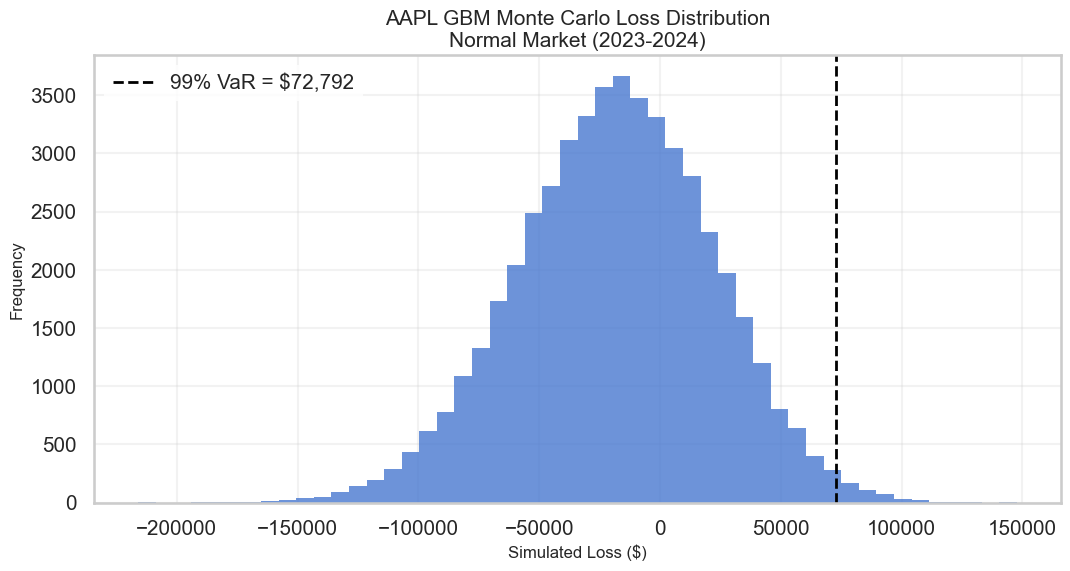

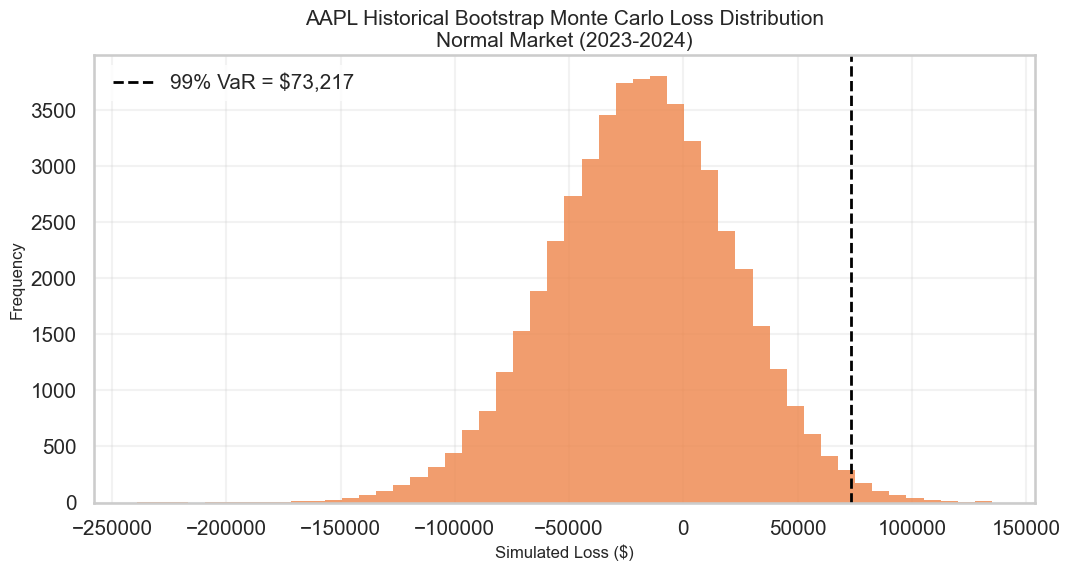

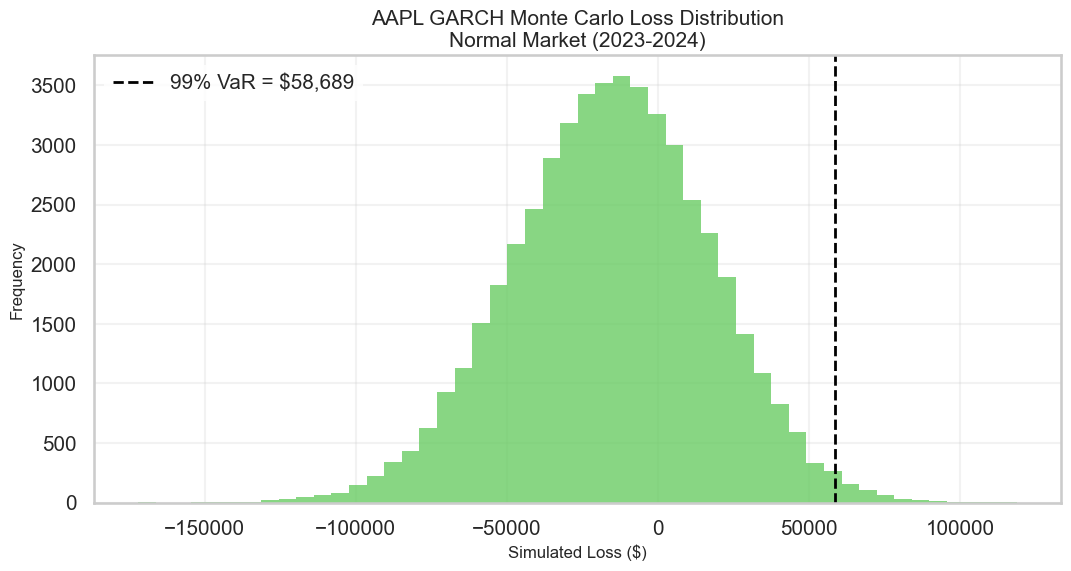

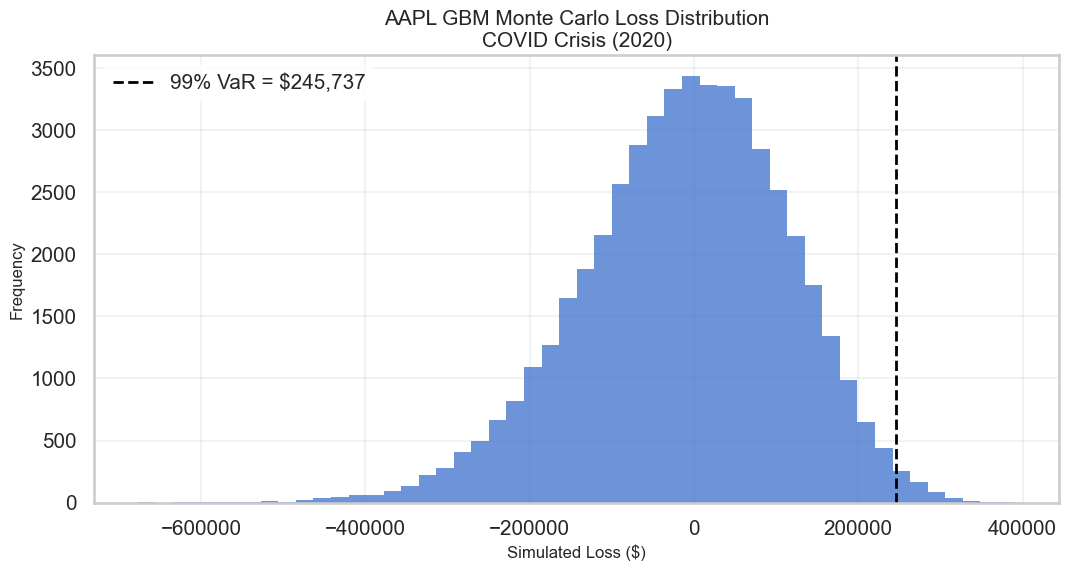

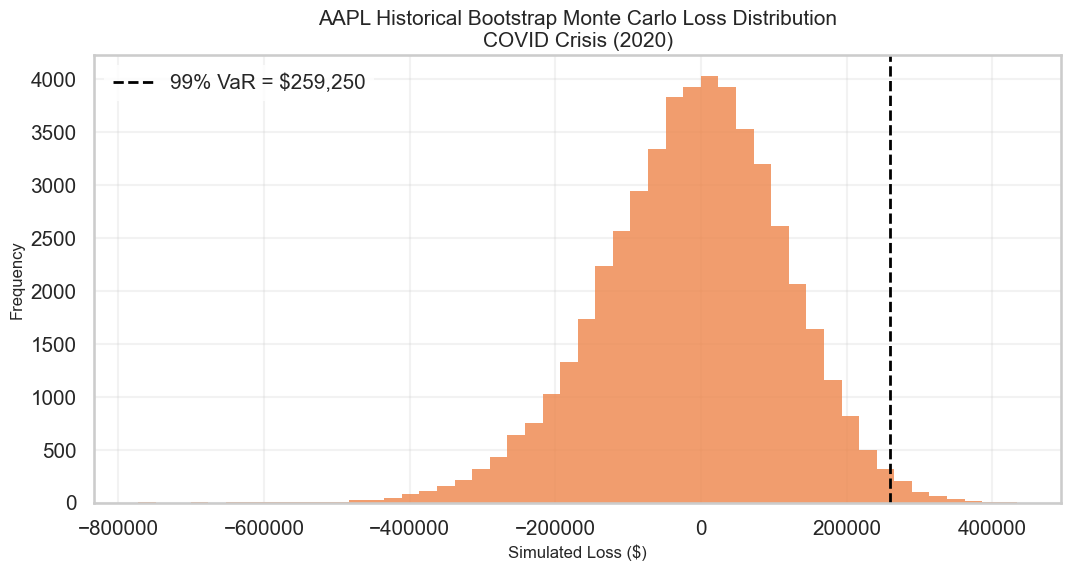

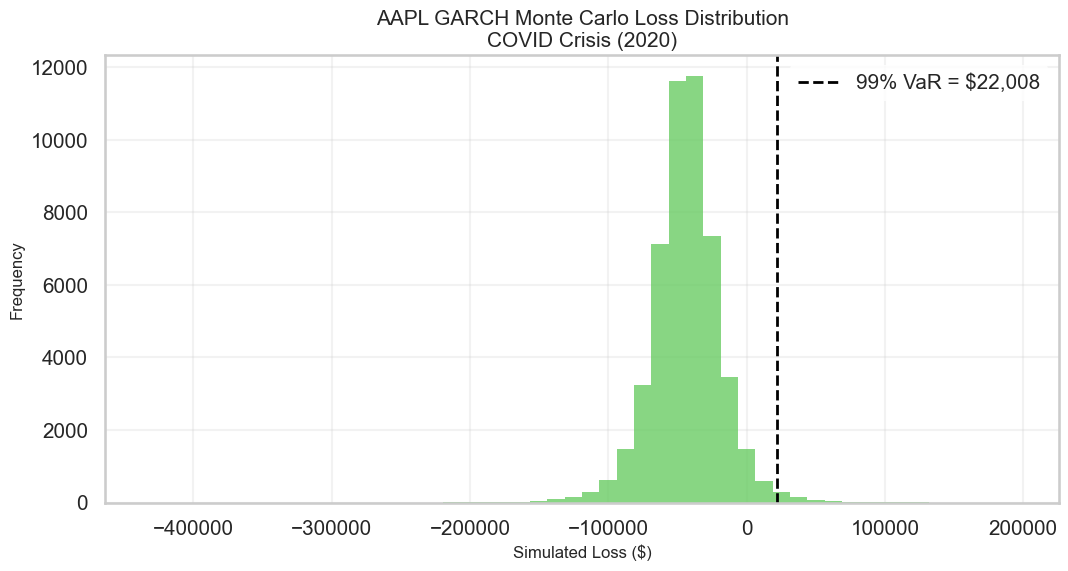

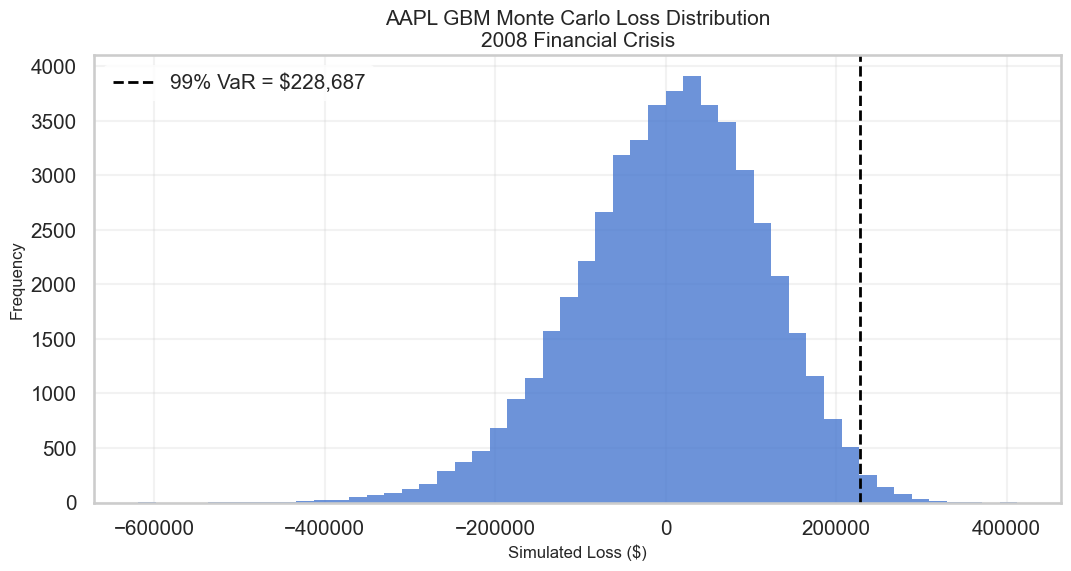

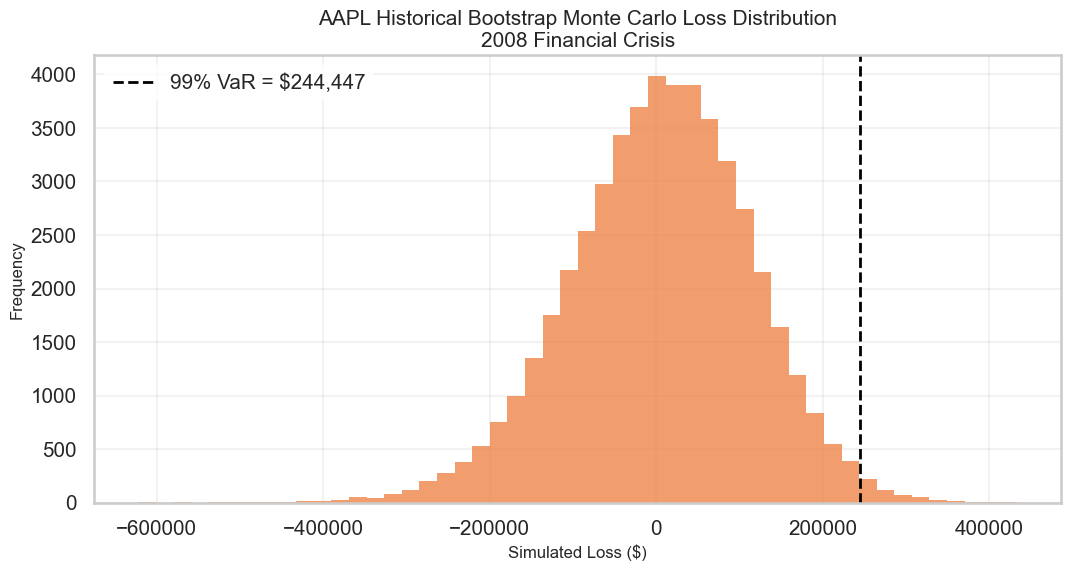

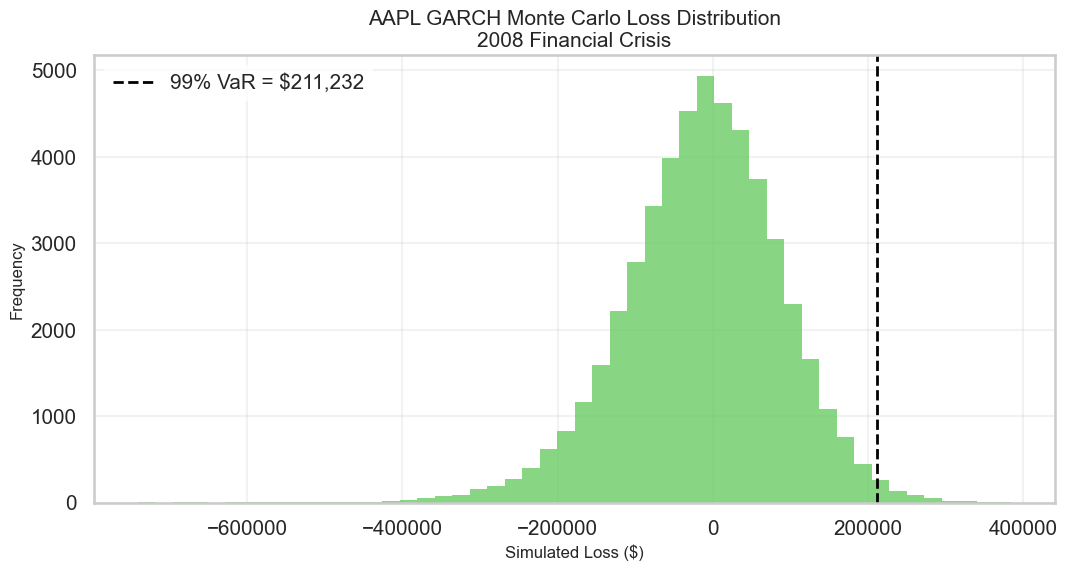

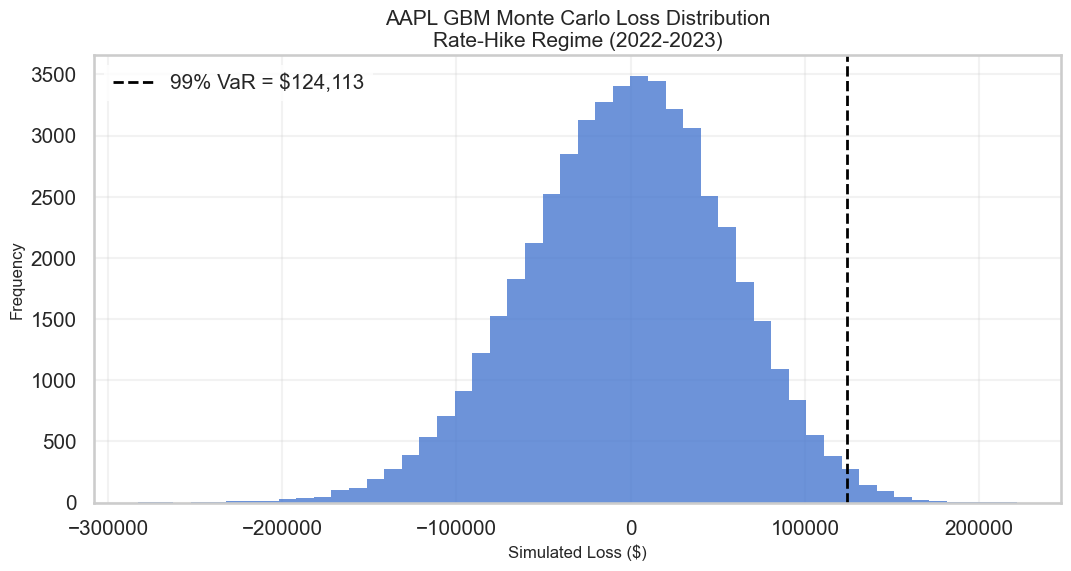

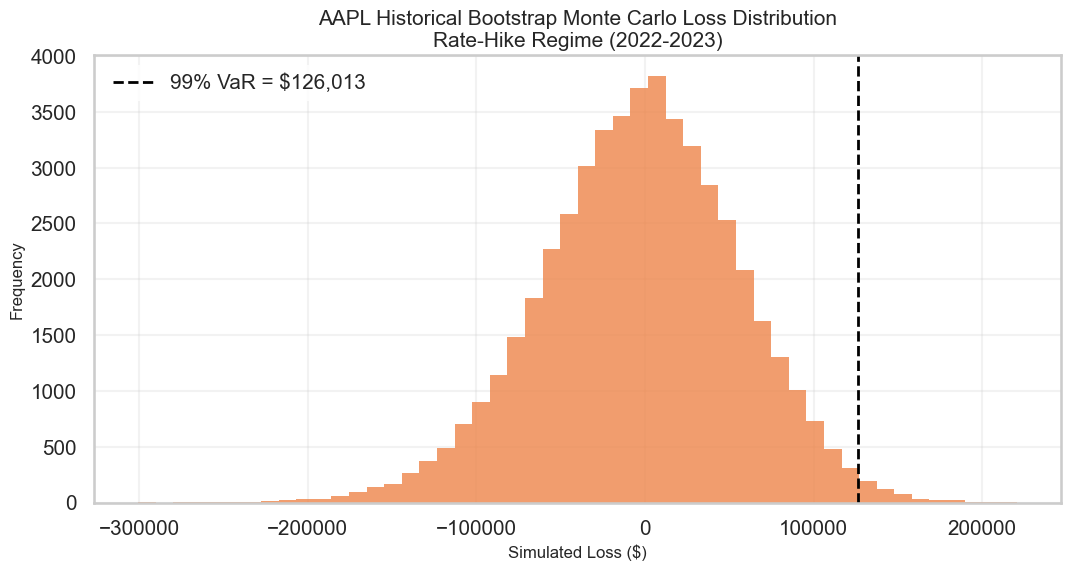

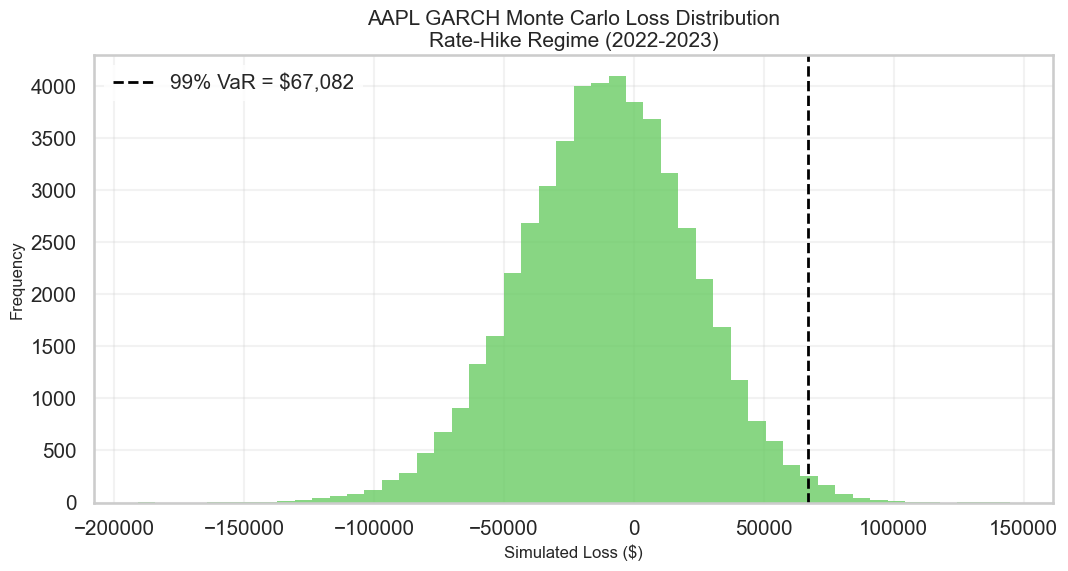

In [118]:
# ---------------------------------------------------
# Individual distribution plots by regime and method
# ---------------------------------------------------

plot_items = [
    ("GBM Monte Carlo", "GBM Losses", "GBM VaR", palette[0]),
    ("Historical Bootstrap Monte Carlo", "Bootstrap Losses", "Bootstrap VaR", palette[1]),
    ("GARCH Monte Carlo", "GARCH Losses", "GARCH VaR", palette[2])
]

for regime, data in results.items():

    for method_name, loss_key, var_key, color in plot_items:

        plt.figure(figsize=(11, 6))

        plt.hist(
            data[loss_key],
            bins=50,
            alpha=0.80,
            color=color,
            edgecolor="none"
        )

        plt.axvline(
            data[var_key],
            linestyle="--",
            linewidth=2,
            color="black",
            label=f"99% VaR = ${data[var_key]:,.0f}"
        )

        plt.title(
            f"{ticker} {method_name} Loss Distribution\n{regime}",
            fontsize=15
        )

        plt.xlabel("Simulated Loss ($)", fontsize=12)
        plt.ylabel("Frequency", fontsize=12)

        plt.legend()
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()

Lastly, we provide risk analysis for Option VAR using the core internal models. Our model succesfully captures using our best methodology of Monte Carlo VAR with repricing strategy. We can see that the VAR increases substantally when the market regimes change across different timezones


Selected Expirations
{'Short Expiration': '2026-05-29', 'Medium Expiration': '2026-07-17', 'Long Expiration': '2026-11-20'}

Selected Option Positions

 Short Expiration
{'Expiration': '2026-05-29', 'Strike': np.float64(295.0), 'Market Option Price': np.float64(6.85), 'Implied Volatility': np.float64(0.26416751464843746), 'T': 0.043835616438356165, 'T After Horizon': 0.016438356164383564, 'Current Option Value': np.float64(685000.0)}

 Medium Expiration
{'Expiration': '2026-07-17', 'Strike': np.float64(295.0), 'Market Option Price': np.float64(13.51), 'Implied Volatility': np.float64(0.2689587265014648), 'T': 0.1780821917808219, 'T After Horizon': 0.1506849315068493, 'Current Option Value': np.float64(1351000.0)}

 Long Expiration
{'Expiration': '2026-11-20', 'Strike': np.float64(295.0), 'Market Option Price': np.float64(25.99), 'Implied Volatility': np.float64(0.3050759190368652), 'T': 0.5232876712328767, 'T After Horizon': 0.49589041095890407, 'Current Option Value': np.float64(2599

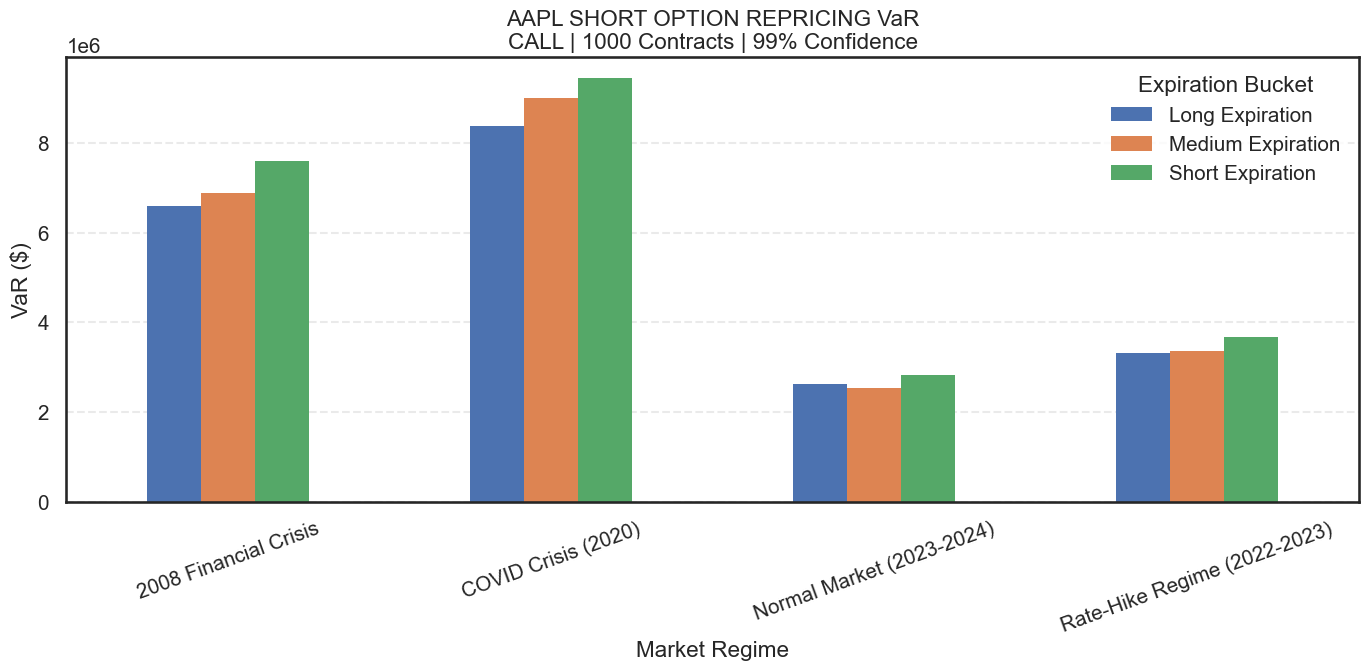

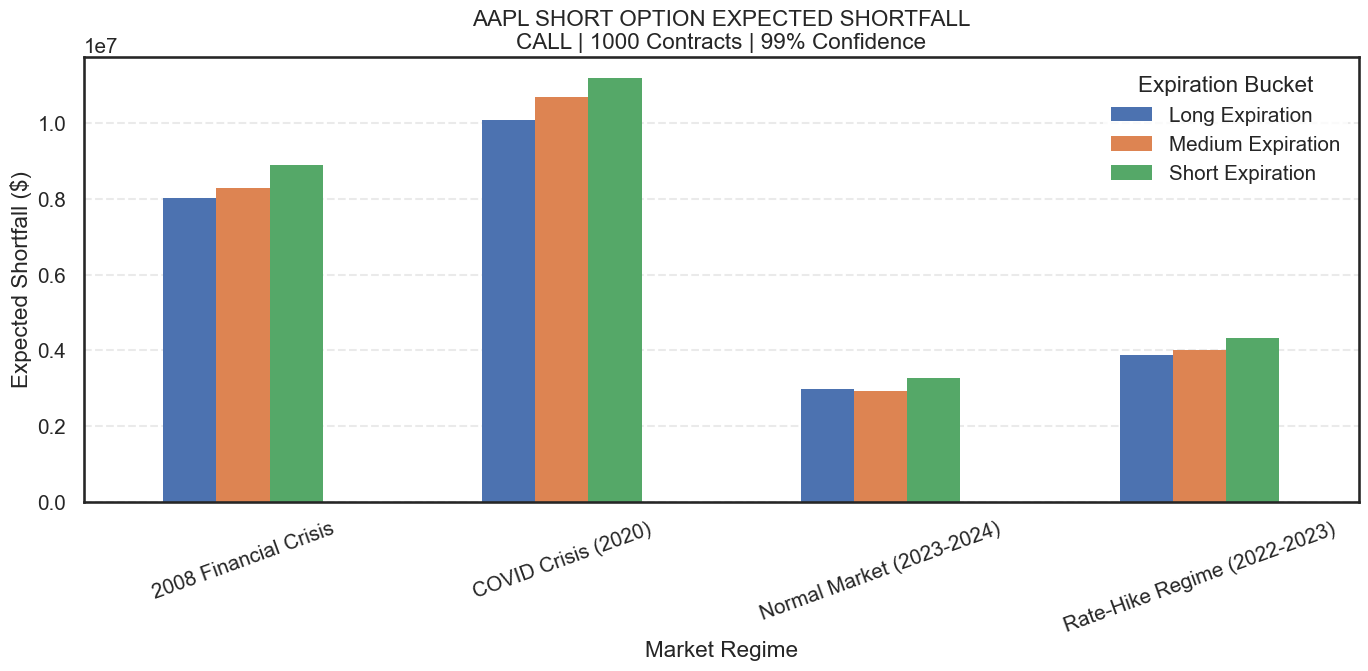

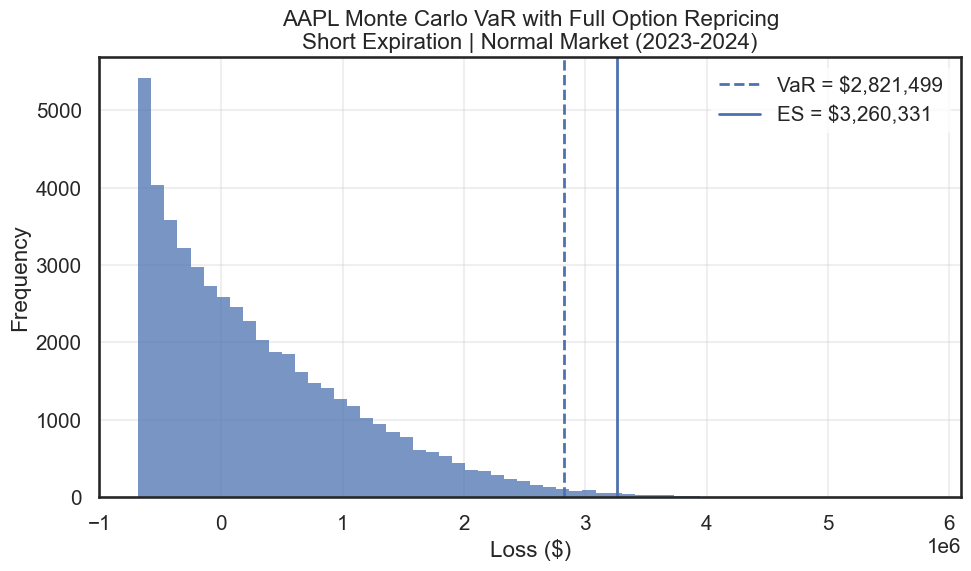

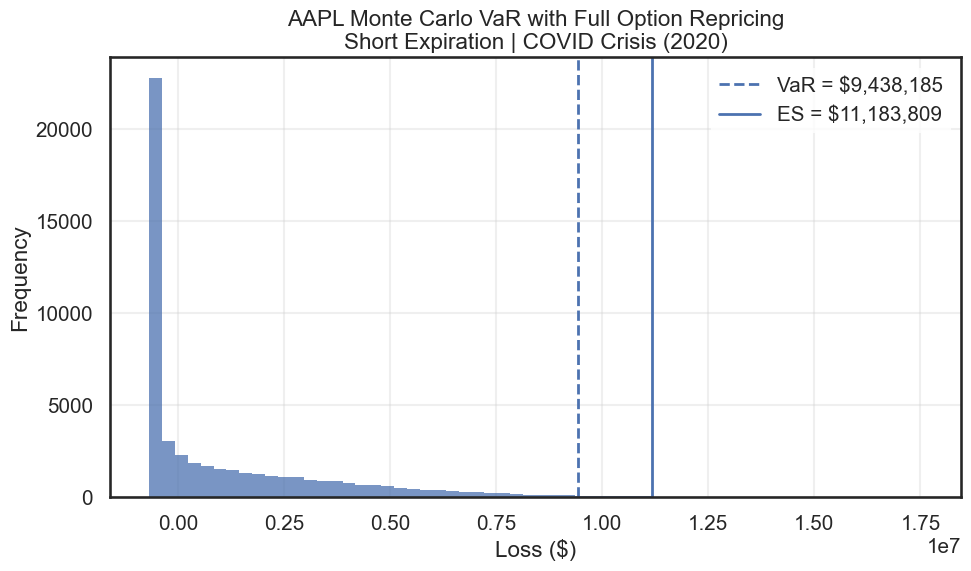

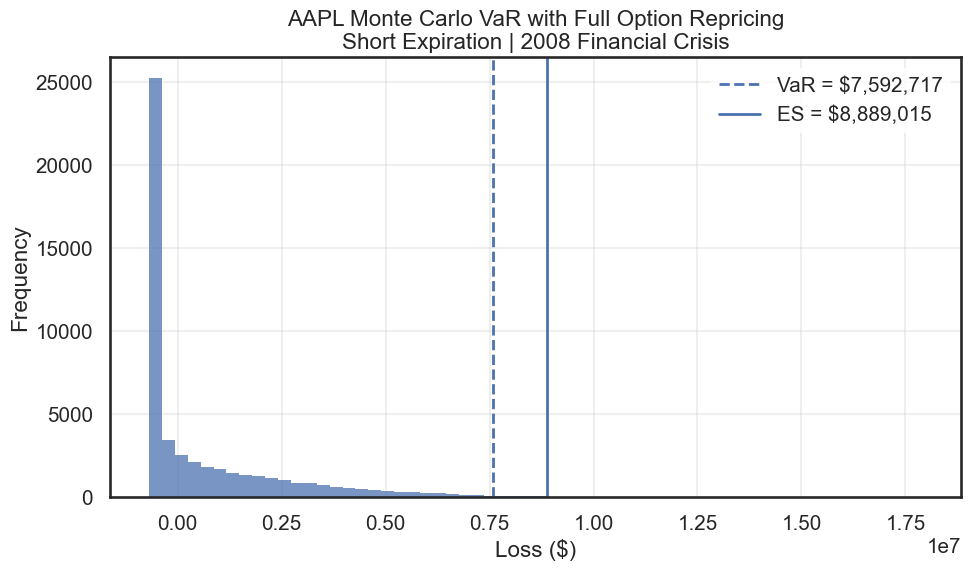

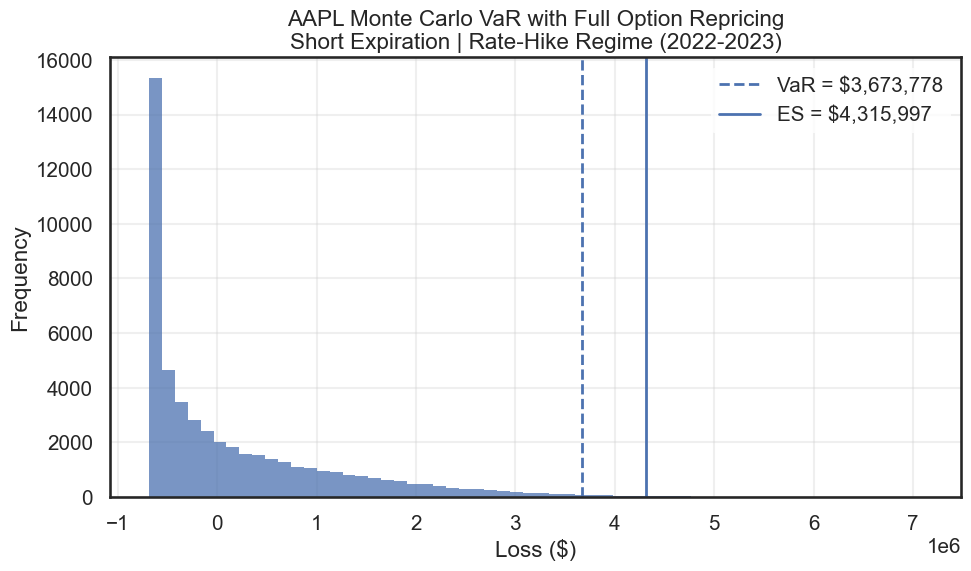

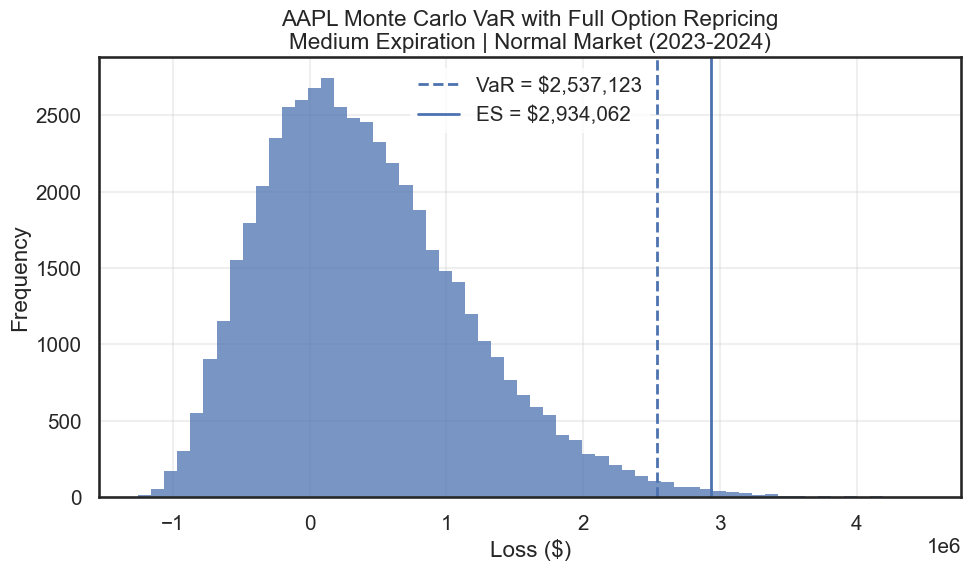

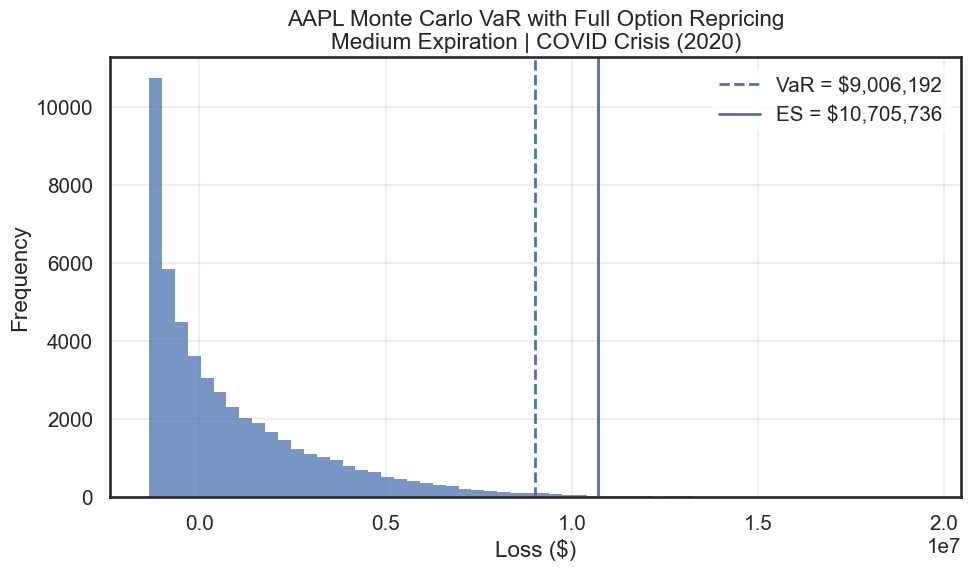

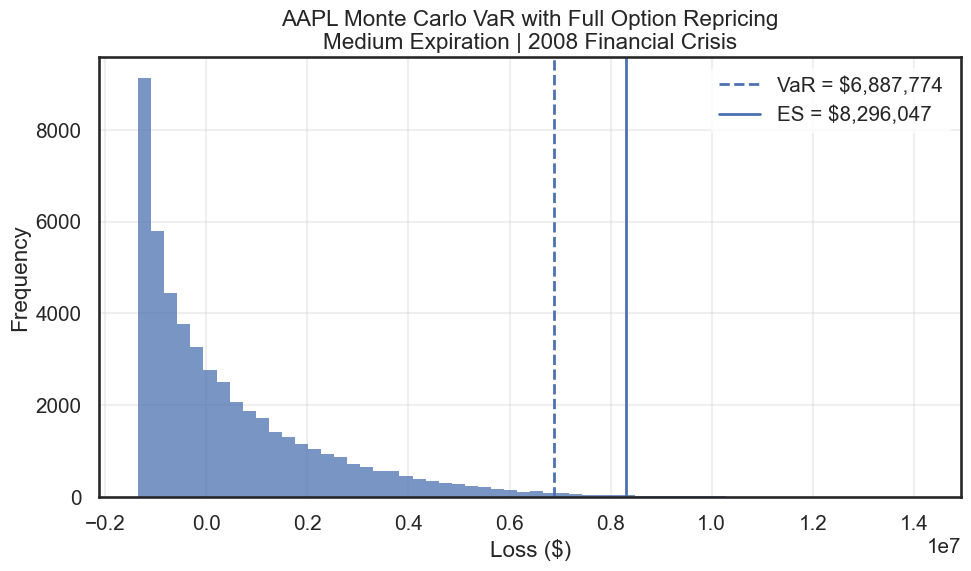

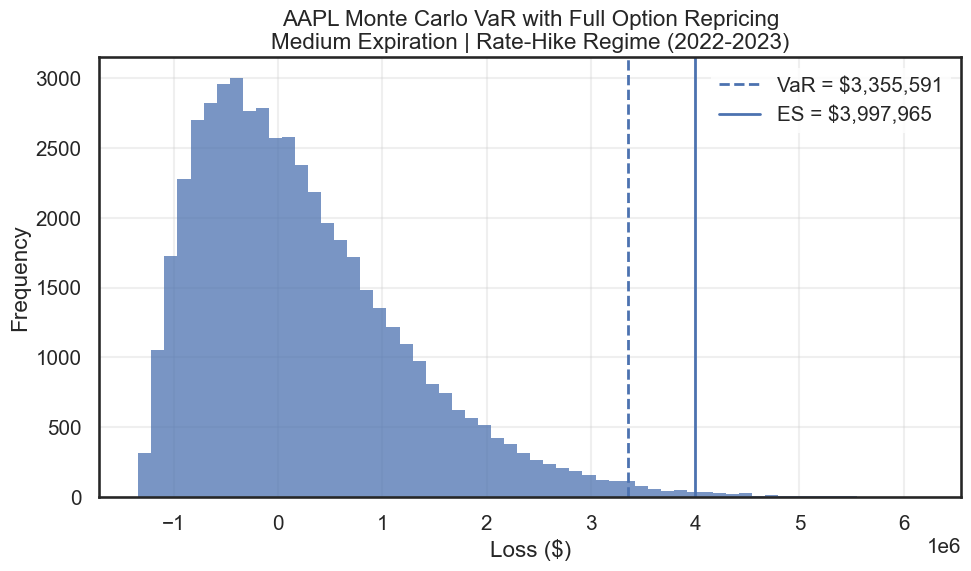

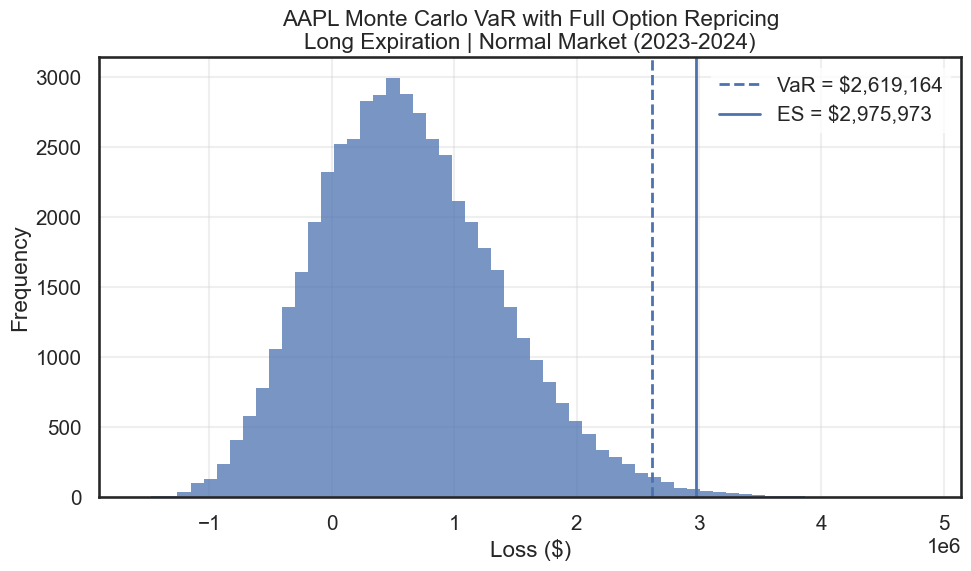

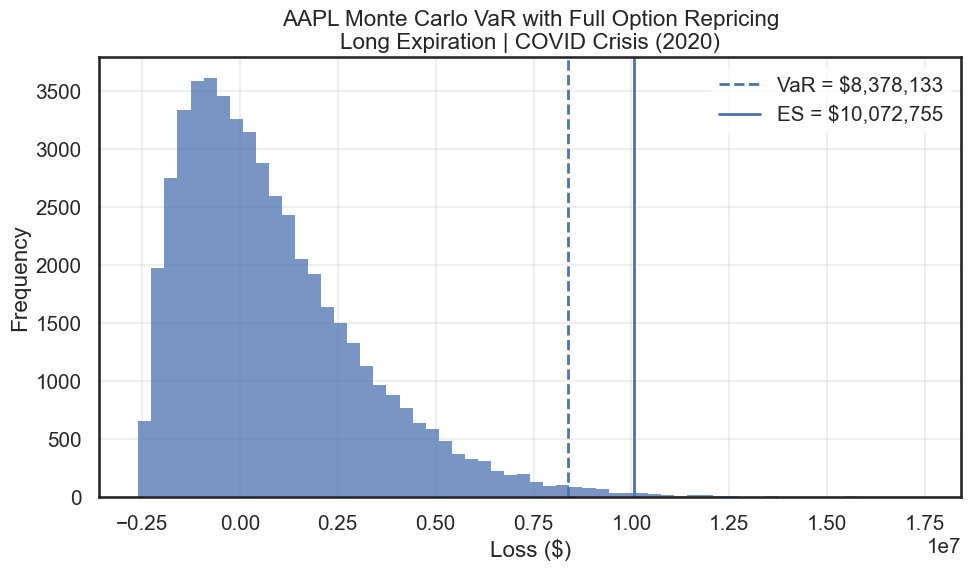

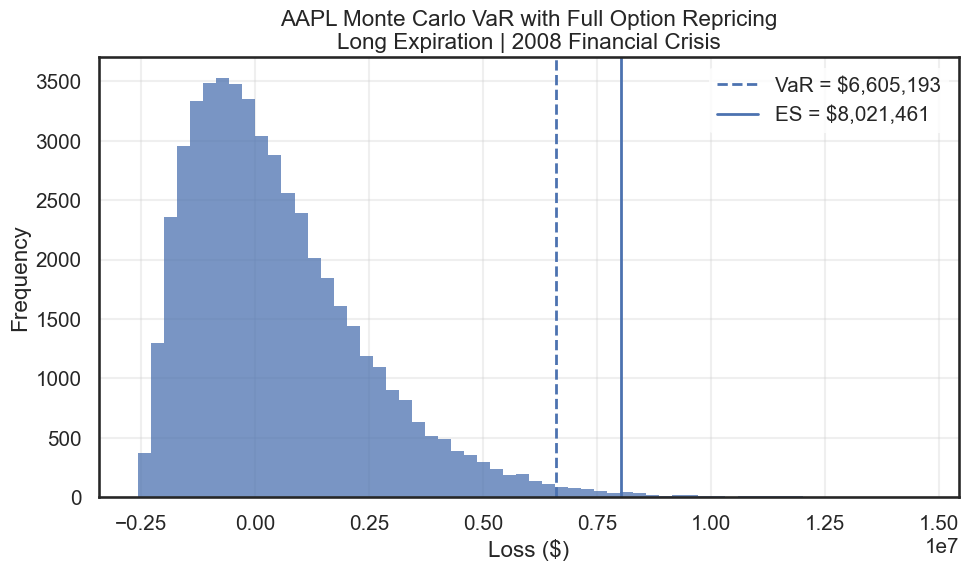

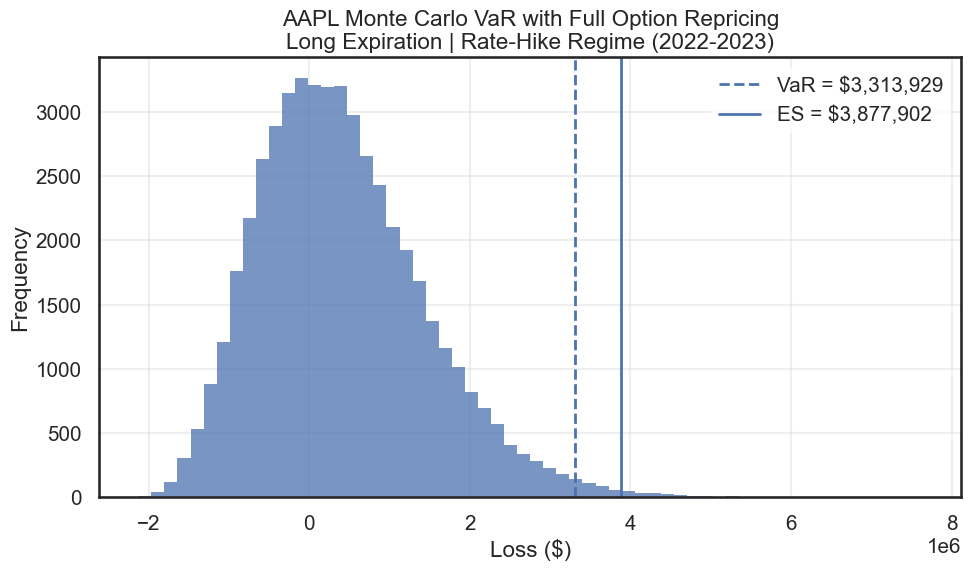

In [40]:
# ===================================================
# OPTION REPRICING VAR
# SHORT OPTION POSITION
# MULTIPLE MARKET REGIMES
# SHORT / MEDIUM / LONG EXPIRATION
# ===================================================

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm

# ===================================================
# SEABORN STYLE
# ===================================================

sns.set_style("white")

sns.set_context(
    "talk",
    font_scale=0.9
)

sns.set_palette("deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["patch.edgecolor"] = "lightgray"
plt.rcParams["patch.linewidth"] = 0

# ===================================================
# SETTINGS
# ===================================================

ticker_symbol = "AAPL"

option_type = "call"          # "call" or "put"

position_side = "short"       # "long" or "short"

contracts = 1000

contract_size = 100

confidence = 0.99

horizon_days = 10

n_sim = 50000

risk_free_rate = 0.045

np.random.seed(42)

# ===================================================
# MARKET REGIMES
# ===================================================

periods = {

    "Normal Market (2023-2024)": (
        "2023-01-01",
        "2024-01-01"
    ),

    "COVID Crisis (2020)": (
        "2020-02-01",
        "2020-06-01"
    ),

    "2008 Financial Crisis": (
        "2007-10-01",
        "2009-03-31"
    ),

    "Rate-Hike Regime (2022-2023)": (
        "2022-01-01",
        "2023-12-31"
    )
}

# ===================================================
# BLACK-SCHOLES FUNCTION
# ===================================================

def bs_price(
    S,
    K,
    T,
    r,
    sigma,
    option_type="call"
):

    if T <= 0:

        if option_type == "call":

            return np.maximum(
                S - K,
                0
            )

        else:

            return np.maximum(
                K - S,
                0
            )

    d1 = (

        np.log(S / K)

        + (r + 0.5 * sigma**2) * T

    ) / (

        sigma * np.sqrt(T)
    )

    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":

        return (

            S * norm.cdf(d1)

            - K * np.exp(-r * T) * norm.cdf(d2)
        )

    else:

        return (

            K * np.exp(-r * T) * norm.cdf(-d2)

            - S * norm.cdf(-d1)
        )

# ===================================================
# LOAD CURRENT OPTION DATA
# ===================================================

ticker = yf.Ticker(ticker_symbol)

spot_price = ticker.history(
    period="1d"
)["Close"].iloc[-1]

today = pd.Timestamp.today().normalize()

all_expirations = [

    pd.Timestamp(exp)

    for exp in ticker.options
]

expiration_df = pd.DataFrame({

    "expiration": all_expirations
})

expiration_df["days_to_expiration"] = (

    expiration_df["expiration"]

    - today

).dt.days

# Remove expirations shorter than VaR horizon

expiration_df = expiration_df[

    expiration_df["days_to_expiration"]

    > horizon_days
]

targets = {

    "Short Expiration": 14,

    "Medium Expiration": 60,

    "Long Expiration": 180
}

selected_expirations = {}

for bucket, target_days in targets.items():

    closest_row = expiration_df.iloc[

        (
            expiration_df["days_to_expiration"]

            - target_days

        ).abs().argsort().iloc[0]
    ]

    selected_expirations[bucket] = (

        closest_row["expiration"]

        .strftime("%Y-%m-%d")
    )

print("\nSelected Expirations")

print(selected_expirations)

option_positions = {}

for bucket, expiration in selected_expirations.items():

    chain = ticker.option_chain(expiration)

    if option_type == "call":

        options = chain.calls.copy()

    else:

        options = chain.puts.copy()

    # ATM option selection

    options["strike_diff"] = abs(

        options["strike"]

        - spot_price
    )

    selected_option = (

        options

        .sort_values("strike_diff")

        .iloc[0]
    )

    K = selected_option["strike"]

    market_option_price = selected_option["lastPrice"]

    implied_vol = selected_option["impliedVolatility"]

    expiration_date = pd.Timestamp(expiration)

    T = (

        expiration_date

        - today

    ).days / 365

    T_after_horizon = max(

        T - horizon_days / 365,

        0
    )

    current_option_value = (

        market_option_price

        * contracts

        * contract_size
    )

    option_positions[bucket] = {

        "Expiration": expiration,

        "Strike": K,

        "Market Option Price": market_option_price,

        "Implied Volatility": implied_vol,

        "T": T,

        "T After Horizon": T_after_horizon,

        "Current Option Value": current_option_value
    }

print("\nSelected Option Positions")

for bucket, pos in option_positions.items():

    print("\n", bucket)

    print(pos)

def compute_option_var_by_regime(

    bucket,

    position,

    regime_name,

    start,

    end
):

    stock_prices = yf.download(

        ticker_symbol,

        start=start,

        end=end,

        auto_adjust=True,

        progress=False
    )["Close"]

    if isinstance(stock_prices, pd.DataFrame):

        stock_prices = stock_prices[ticker_symbol]

    returns = stock_prices.pct_change().dropna()

    mu_daily = returns.mean()

    sigma_daily = returns.std()

    Z = np.random.normal(size=n_sim)

    simulated_stock_prices = spot_price * np.exp(

        (
            mu_daily

            - 0.5 * sigma_daily**2
        )

        * horizon_days

        + sigma_daily

        * np.sqrt(horizon_days)

        * Z
    )
    repriced_options = bs_price(

        S=simulated_stock_prices,

        K=position["Strike"],

        T=position["T After Horizon"],

        r=risk_free_rate,

        sigma=position["Implied Volatility"],

        option_type=option_type
    )

    simulated_option_values = (

        repriced_options

        * contracts

        * contract_size
    )

    if position_side == "long":

        pnl = (

            simulated_option_values

            - position["Current Option Value"]
        )

    elif position_side == "short":

        pnl = (

            position["Current Option Value"]

            - simulated_option_values
        )

    else:

        raise ValueError(

            "position_side must be 'long' or 'short'"
        )

    losses = -pnl
    option_var = np.percentile(

        losses,

        confidence * 100
    )

    option_es = losses[

        losses >= option_var

    ].mean()

    return {

        "Expiration Bucket": bucket,

        "Regime": regime_name,

        "Expiration": position["Expiration"],

        "Strike": position["Strike"],

        "Implied Volatility": position["Implied Volatility"],

        "Current Option Value": position["Current Option Value"],

        "Daily Volatility": sigma_daily,

        "Option VaR": option_var,

        "Option ES": option_es,

        "Losses": losses
    }


all_results = []

for bucket, position in option_positions.items():

    for regime_name, (start, end) in periods.items():

        print(

            f"Running {bucket} | {regime_name}"
        )

        result = compute_option_var_by_regime(

            bucket,

            position,

            regime_name,

            start,

            end
        )

        all_results.append(result)
comparison_df = pd.DataFrame([

    {

        "Expiration Bucket": r["Expiration Bucket"],

        "Regime": r["Regime"],

        "Expiration": r["Expiration"],

        "Strike": r["Strike"],

        "Implied Volatility": r["Implied Volatility"],

        "Daily Volatility": r["Daily Volatility"],

        "Option VaR": r["Option VaR"],

        "Option ES": r["Option ES"]
    }

    for r in all_results
])

pd.set_option(

    "display.float_format",

    lambda x: f"{x:,.2f}"
)

print("\nOPTION REPRICING VAR RESULTS")

print(comparison_df)
pivot_var = comparison_df.pivot(

    index="Regime",

    columns="Expiration Bucket",

    values="Option VaR"
)

pivot_var.plot(

    kind="bar",

    figsize=(14, 7)
)

plt.title(

    f"{ticker_symbol} SHORT OPTION REPRICING VaR\n"

    f"{option_type.upper()} | "

    f"{contracts} Contracts | "

    f"{confidence:.0%} Confidence"
)

plt.ylabel("VaR ($)")

plt.xlabel("Market Regime")

plt.xticks(rotation=20)

plt.grid(

    axis="y",

    linestyle="--",

    alpha=0.4
)

plt.tight_layout()

plt.show()

# ===================================================
# EXPECTED SHORTFALL BAR CHART
# ===================================================

pivot_es = comparison_df.pivot(
    index="Regime",
    columns="Expiration Bucket",
    values="Option ES"
)

pivot_es.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    f"{ticker_symbol} SHORT OPTION EXPECTED SHORTFALL\n"
    f"{option_type.upper()} | "

    f"{contracts} Contracts | "

    f"{confidence:.0%} Confidence"
)

plt.ylabel("Expected Shortfall ($)")

plt.xlabel("Market Regime")

plt.xticks(rotation=20)

plt.grid(

    axis="y",

    linestyle="--",

    alpha=0.4
)

plt.tight_layout()

plt.show()

# LOSS DISTRIBUTION GRAPHS
for r in all_results:
    plt.figure(figsize=(10, 6))
    plt.hist(
        r["Losses"],
        bins=60,
        alpha=0.75
    )
    plt.axvline(
        r["Option VaR"],
        linestyle="--",
        linewidth=2,
        label=f"VaR = ${r['Option VaR']:,.0f}"
    )
    plt.axvline(
      r["Option ES"],
        linestyle="-",

        linewidth=2,

        label=f"ES = ${r['Option ES']:,.0f}"
    )

    plt.title(

        f"{ticker_symbol} Monte Carlo VaR with Full Option Repricing\n"

        f"{r['Expiration Bucket']} | "

        f"{r['Regime']}"
    )

    plt.xlabel("Loss ($)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


Selected Expirations
{'Short Expiration': '2026-05-29', 'Medium Expiration': '2026-07-17', 'Long Expiration': '2026-11-20'}

Selected Option Positions

 Short Expiration
{'Expiration': '2026-05-29', 'Strike': np.float64(295.0), 'Market Option Price': np.float64(6.85), 'Implied Volatility': np.float64(0.2539747454833985), 'T': 0.043835616438356165, 'T After Horizon': 0.016438356164383564, 'Current Option Value': np.float64(685000.0)}

 Medium Expiration
{'Expiration': '2026-07-17', 'Strike': np.float64(295.0), 'Market Option Price': np.float64(13.52), 'Implied Volatility': np.float64(0.25974251007080085), 'T': 0.1780821917808219, 'T After Horizon': 0.1506849315068493, 'Current Option Value': np.float64(1352000.0)}

 Long Expiration
{'Expiration': '2026-11-20', 'Strike': np.float64(295.0), 'Market Option Price': np.float64(25.99), 'Implied Volatility': np.float64(0.30191738128662116), 'T': 0.5232876712328767, 'T After Horizon': 0.49589041095890407, 'Current Option Value': np.float64(259

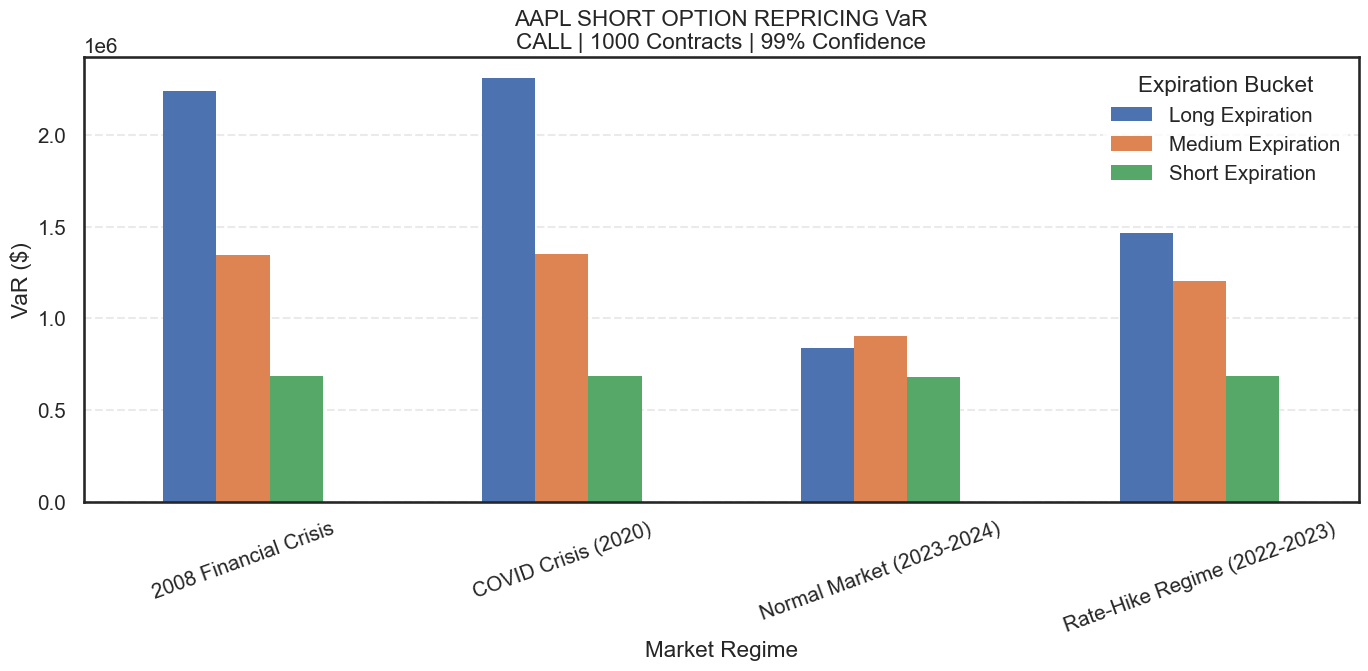

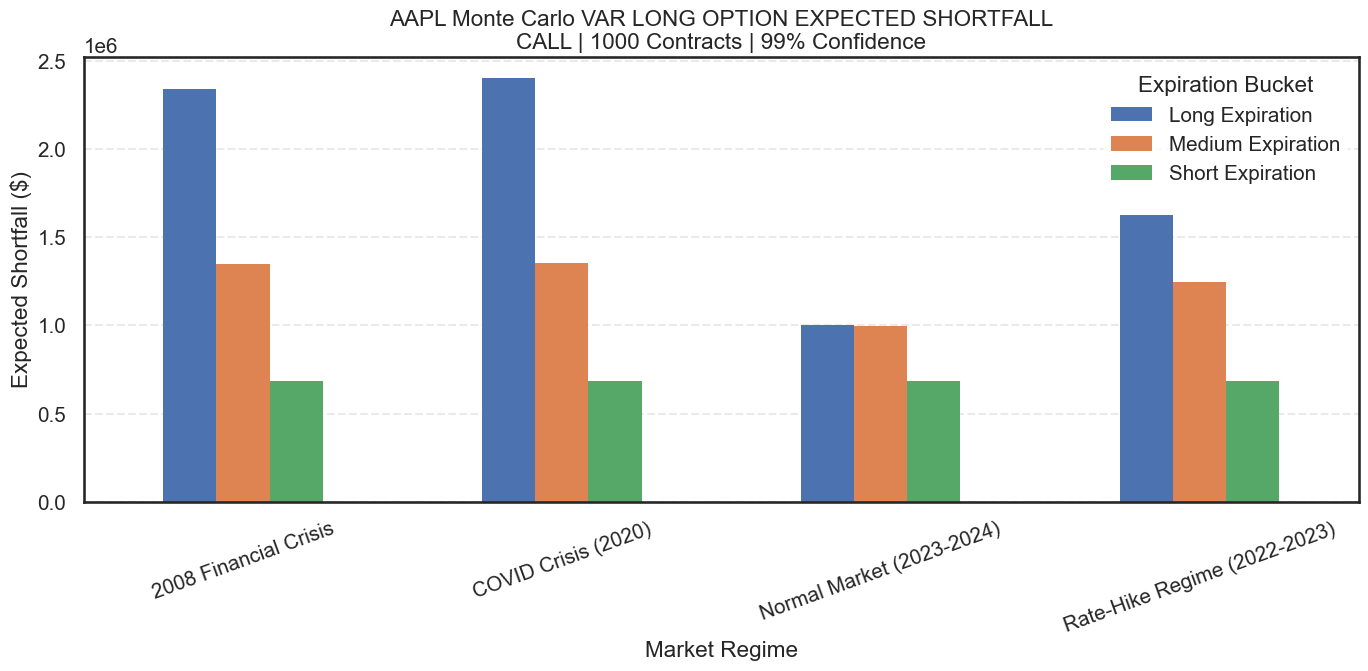

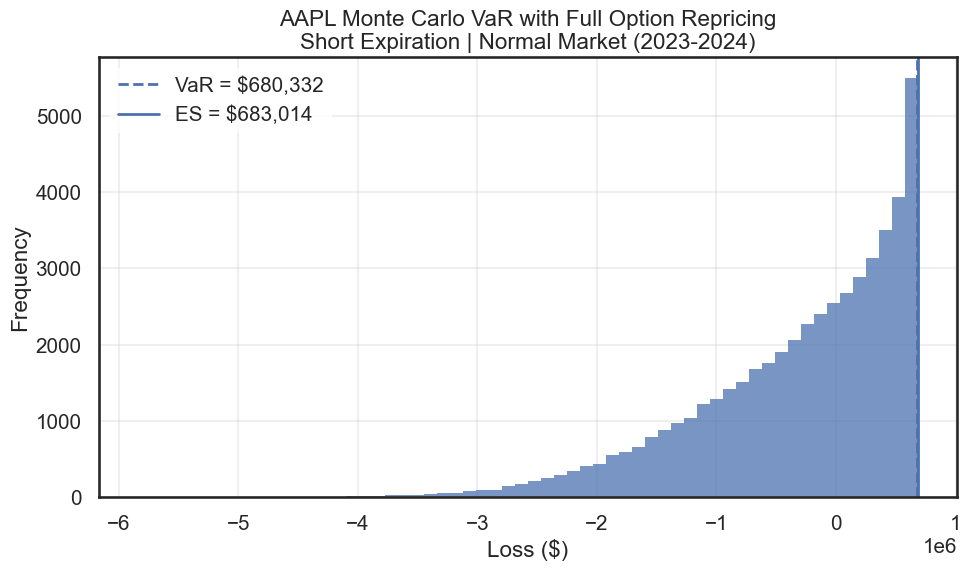

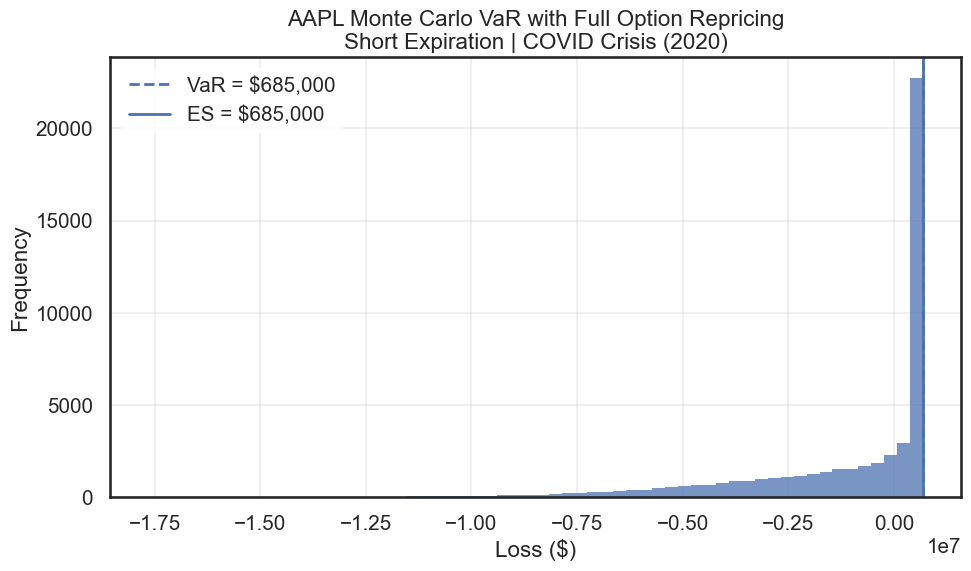

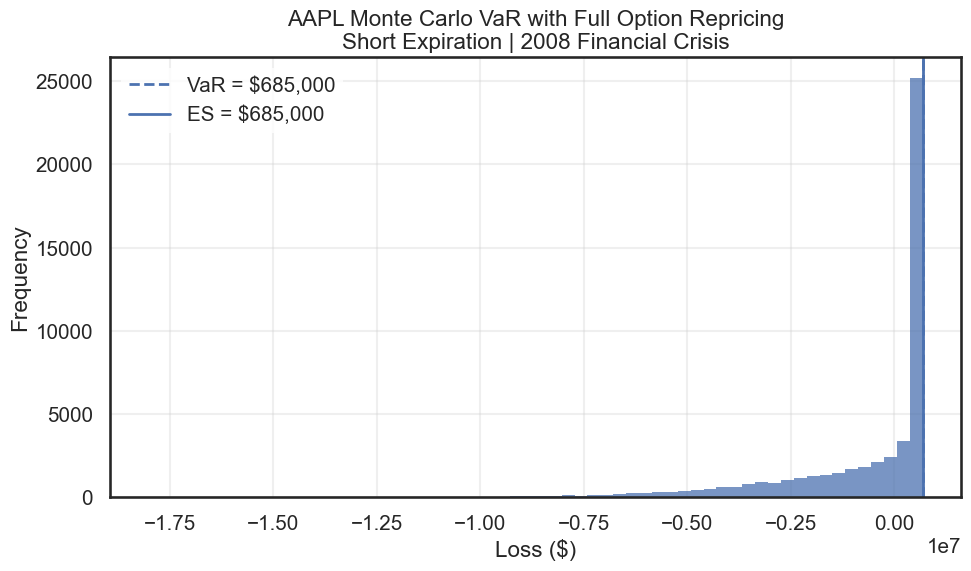

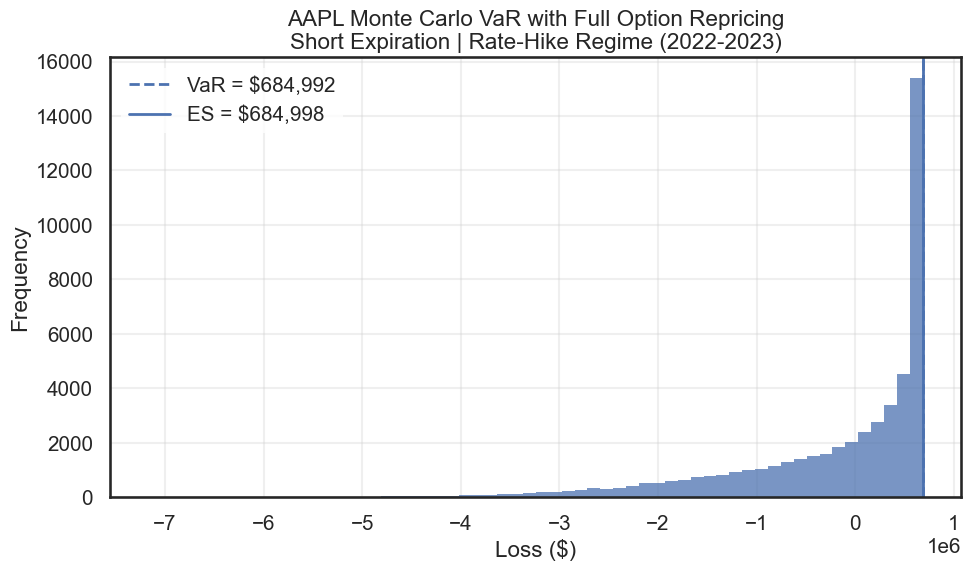

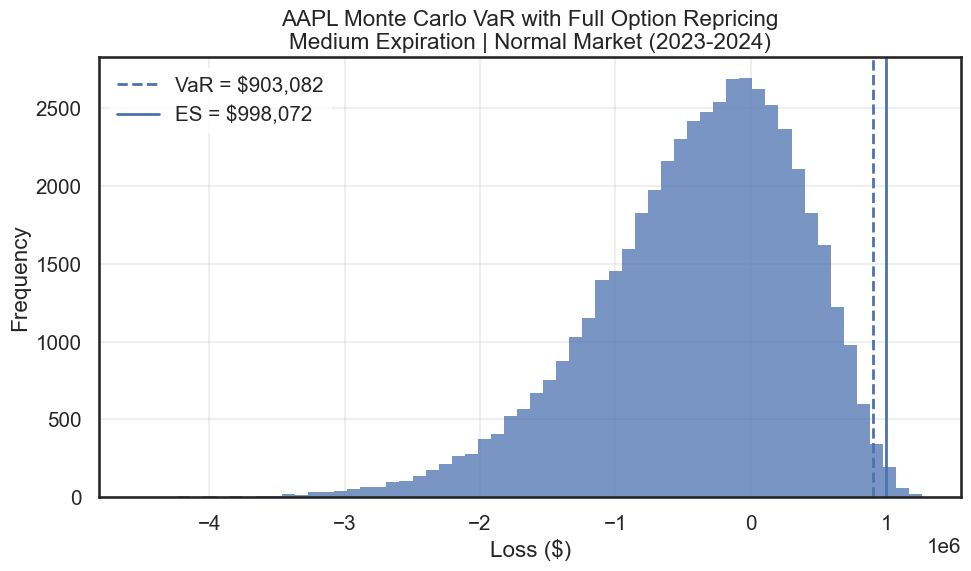

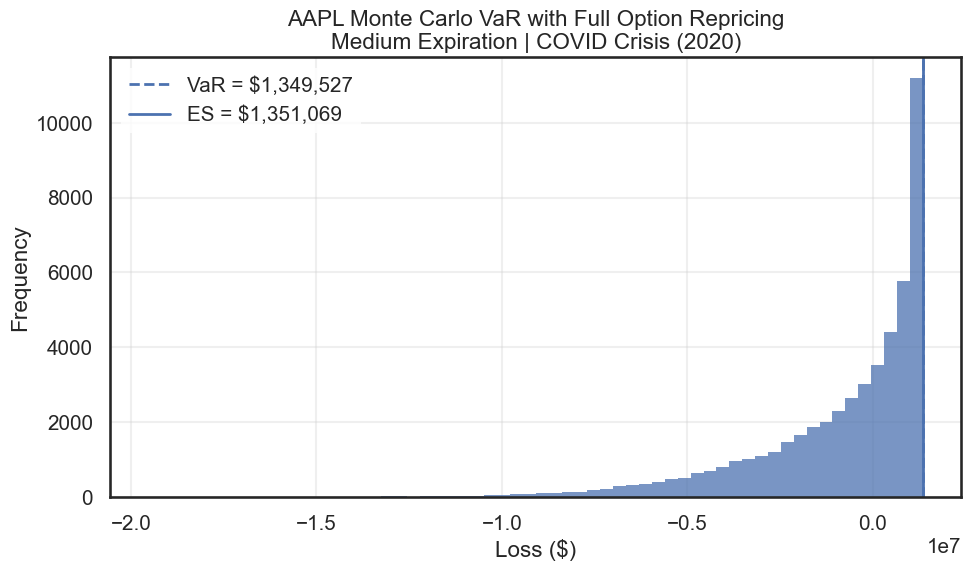

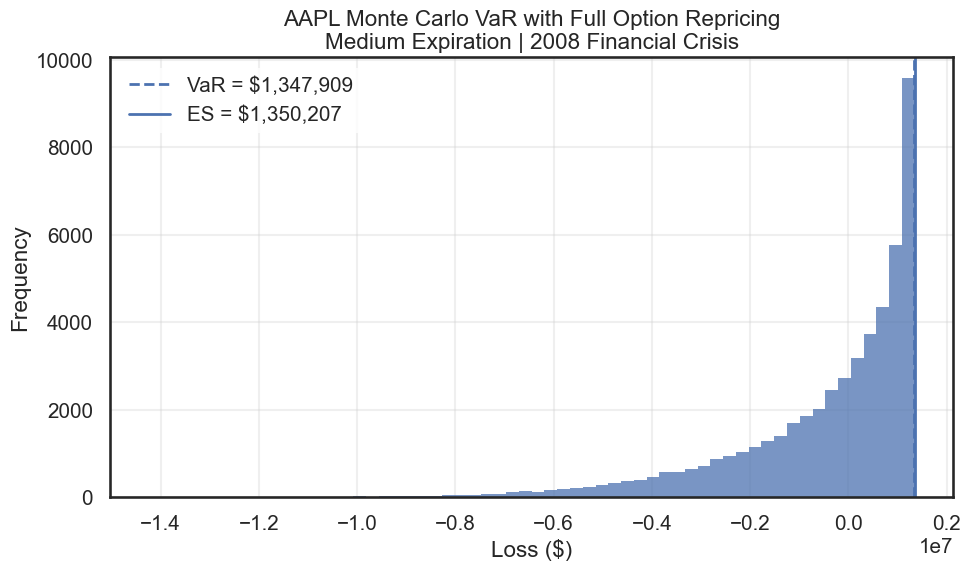

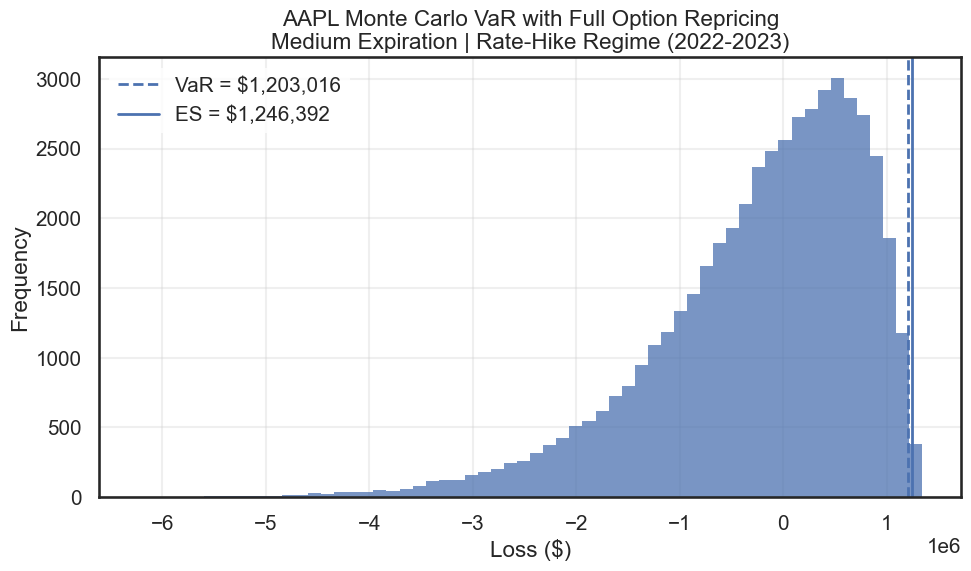

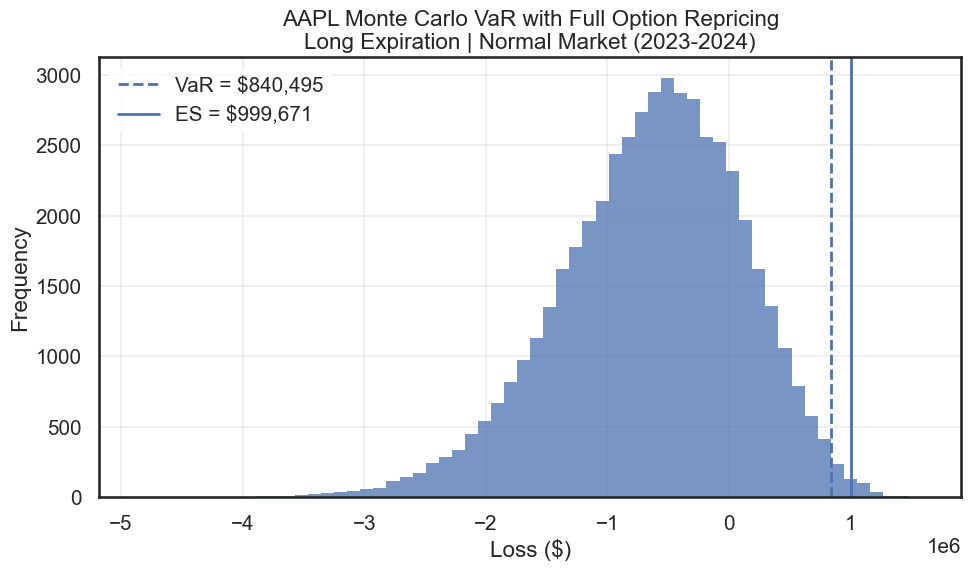

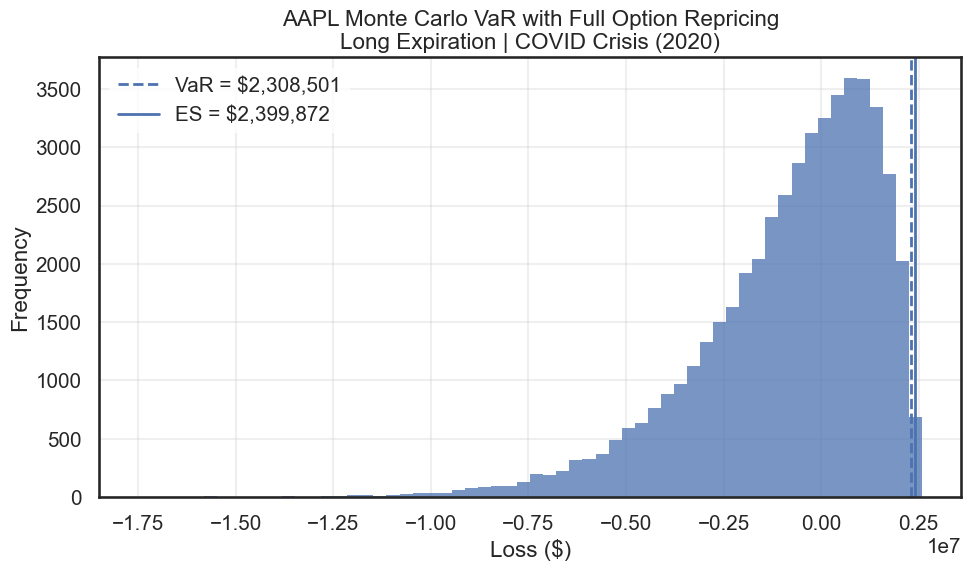

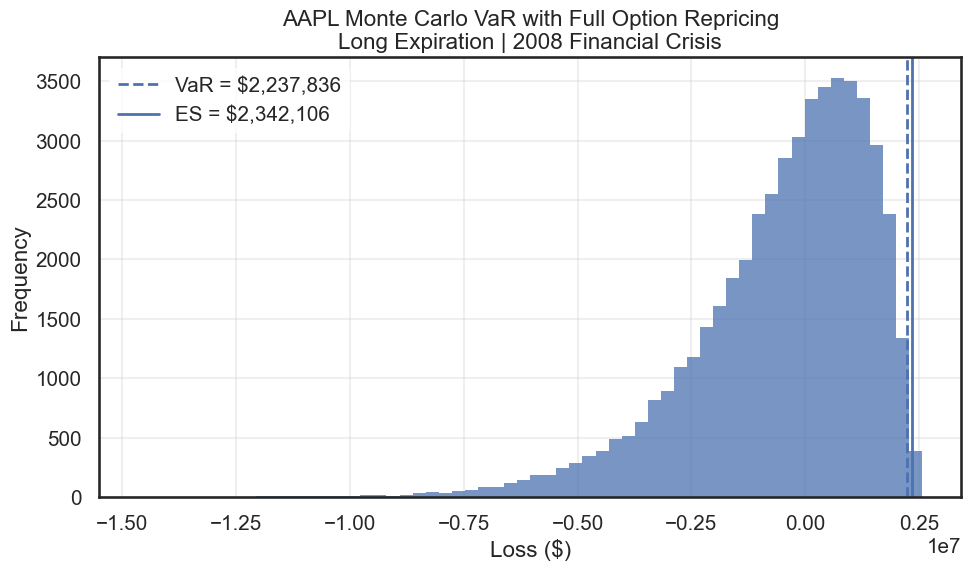

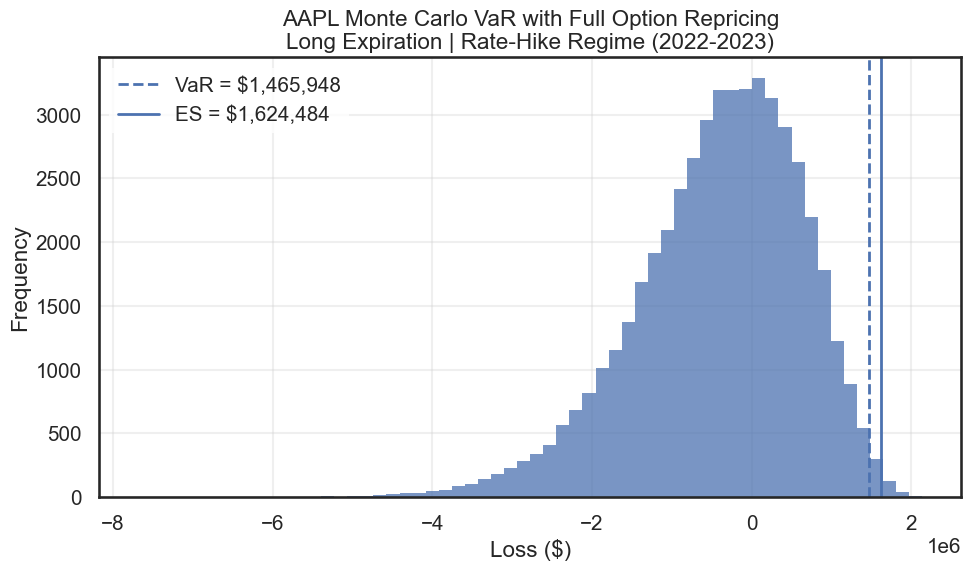

In [39]:
# ===================================================
# OPTION REPRICING VAR
# SHORT OPTION POSITION
# MULTIPLE MARKET REGIMES
# SHORT / MEDIUM / LONG EXPIRATION
# ===================================================

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm

# ===================================================
# SEABORN STYLE
# ===================================================

sns.set_style("white")

sns.set_context(
    "talk",
    font_scale=0.9
)

sns.set_palette("deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["patch.edgecolor"] = "lightgray"
plt.rcParams["patch.linewidth"] = 0

# ===================================================
# SETTINGS
# ===================================================

ticker_symbol = "AAPL"

option_type = "call"          # "call" or "put"

position_side = "long"       # "long" or "short"

contracts = 1000

contract_size = 100

confidence = 0.99

horizon_days = 10

n_sim = 50000

risk_free_rate = 0.045

np.random.seed(42)

# ===================================================
# MARKET REGIMES
# ===================================================

periods = {

    "Normal Market (2023-2024)": (
        "2023-01-01",
        "2024-01-01"
    ),

    "COVID Crisis (2020)": (
        "2020-02-01",
        "2020-06-01"
    ),

    "2008 Financial Crisis": (
        "2007-10-01",
        "2009-03-31"
    ),

    "Rate-Hike Regime (2022-2023)": (
        "2022-01-01",
        "2023-12-31"
    )
}

# ===================================================
# BLACK-SCHOLES FUNCTION
# ===================================================

def bs_price(
    S,
    K,
    T,
    r,
    sigma,
    option_type="call"
):

    if T <= 0:

        if option_type == "call":

            return np.maximum(
                S - K,
                0
            )

        else:

            return np.maximum(
                K - S,
                0
            )

    d1 = (

        np.log(S / K)

        + (r + 0.5 * sigma**2) * T

    ) / (

        sigma * np.sqrt(T)
    )

    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":

        return (

            S * norm.cdf(d1)

            - K * np.exp(-r * T) * norm.cdf(d2)
        )

    else:

        return (

            K * np.exp(-r * T) * norm.cdf(-d2)

            - S * norm.cdf(-d1)
        )

# ===================================================
# LOAD CURRENT OPTION DATA
# ===================================================

ticker = yf.Ticker(ticker_symbol)

spot_price = ticker.history(
    period="1d"
)["Close"].iloc[-1]

today = pd.Timestamp.today().normalize()

all_expirations = [

    pd.Timestamp(exp)

    for exp in ticker.options
]

expiration_df = pd.DataFrame({

    "expiration": all_expirations
})

expiration_df["days_to_expiration"] = (

    expiration_df["expiration"]

    - today

).dt.days

# Remove expirations shorter than VaR horizon

expiration_df = expiration_df[

    expiration_df["days_to_expiration"]

    > horizon_days
]

targets = {

    "Short Expiration": 14,

    "Medium Expiration": 60,

    "Long Expiration": 180
}

selected_expirations = {}

for bucket, target_days in targets.items():

    closest_row = expiration_df.iloc[

        (
            expiration_df["days_to_expiration"]

            - target_days

        ).abs().argsort().iloc[0]
    ]

    selected_expirations[bucket] = (

        closest_row["expiration"]

        .strftime("%Y-%m-%d")
    )

print("\nSelected Expirations")

print(selected_expirations)

option_positions = {}

for bucket, expiration in selected_expirations.items():

    chain = ticker.option_chain(expiration)

    if option_type == "call":

        options = chain.calls.copy()

    else:

        options = chain.puts.copy()

    # ATM option selection

    options["strike_diff"] = abs(

        options["strike"]

        - spot_price
    )

    selected_option = (

        options

        .sort_values("strike_diff")

        .iloc[0]
    )

    K = selected_option["strike"]

    market_option_price = selected_option["lastPrice"]

    implied_vol = selected_option["impliedVolatility"]

    expiration_date = pd.Timestamp(expiration)

    T = (

        expiration_date

        - today

    ).days / 365

    T_after_horizon = max(

        T - horizon_days / 365,

        0
    )

    current_option_value = (

        market_option_price

        * contracts

        * contract_size
    )

    option_positions[bucket] = {

        "Expiration": expiration,

        "Strike": K,

        "Market Option Price": market_option_price,

        "Implied Volatility": implied_vol,

        "T": T,

        "T After Horizon": T_after_horizon,

        "Current Option Value": current_option_value
    }

print("\nSelected Option Positions")

for bucket, pos in option_positions.items():

    print("\n", bucket)

    print(pos)

def compute_option_var_by_regime(

    bucket,

    position,

    regime_name,

    start,

    end
):

    stock_prices = yf.download(

        ticker_symbol,

        start=start,

        end=end,

        auto_adjust=True,

        progress=False
    )["Close"]

    if isinstance(stock_prices, pd.DataFrame):

        stock_prices = stock_prices[ticker_symbol]

    returns = stock_prices.pct_change().dropna()

    mu_daily = returns.mean()

    sigma_daily = returns.std()

    Z = np.random.normal(size=n_sim)

    simulated_stock_prices = spot_price * np.exp(

        (
            mu_daily

            - 0.5 * sigma_daily**2
        )

        * horizon_days

        + sigma_daily

        * np.sqrt(horizon_days)

        * Z
    )
    repriced_options = bs_price(

        S=simulated_stock_prices,

        K=position["Strike"],

        T=position["T After Horizon"],

        r=risk_free_rate,

        sigma=position["Implied Volatility"],

        option_type=option_type
    )

    simulated_option_values = (

        repriced_options

        * contracts

        * contract_size
    )

    if position_side == "long":

        pnl = (

            simulated_option_values

            - position["Current Option Value"]
        )

    elif position_side == "short":

        pnl = (

            position["Current Option Value"]

            - simulated_option_values
        )

    else:

        raise ValueError(

            "position_side must be 'long' or 'short'"
        )

    losses = -pnl
    option_var = np.percentile(

        losses,

        confidence * 100
    )

    option_es = losses[

        losses >= option_var

    ].mean()

    return {

        "Expiration Bucket": bucket,

        "Regime": regime_name,

        "Expiration": position["Expiration"],

        "Strike": position["Strike"],

        "Implied Volatility": position["Implied Volatility"],

        "Current Option Value": position["Current Option Value"],

        "Daily Volatility": sigma_daily,

        "Option VaR": option_var,

        "Option ES": option_es,

        "Losses": losses
    }


all_results = []

for bucket, position in option_positions.items():

    for regime_name, (start, end) in periods.items():

        print(

            f"Running {bucket} | {regime_name}"
        )

        result = compute_option_var_by_regime(

            bucket,

            position,

            regime_name,

            start,

            end
        )

        all_results.append(result)
comparison_df = pd.DataFrame([

    {

        "Expiration Bucket": r["Expiration Bucket"],

        "Regime": r["Regime"],

        "Expiration": r["Expiration"],

        "Strike": r["Strike"],

        "Implied Volatility": r["Implied Volatility"],

        "Daily Volatility": r["Daily Volatility"],

        "Option VaR": r["Option VaR"],

        "Option ES": r["Option ES"]
    }

    for r in all_results
])

pd.set_option(

    "display.float_format",

    lambda x: f"{x:,.2f}"
)

print("\nOPTION REPRICING VAR RESULTS")

print(comparison_df)
pivot_var = comparison_df.pivot(

    index="Regime",

    columns="Expiration Bucket",

    values="Option VaR"
)

pivot_var.plot(

    kind="bar",

    figsize=(14, 7)
)

plt.title(

    f"{ticker_symbol} SHORT OPTION REPRICING VaR\n"

    f"{option_type.upper()} | "

    f"{contracts} Contracts | "

    f"{confidence:.0%} Confidence"
)

plt.ylabel("VaR ($)")

plt.xlabel("Market Regime")

plt.xticks(rotation=20)

plt.grid(

    axis="y",

    linestyle="--",

    alpha=0.4
)

plt.tight_layout()

plt.show()

# ===================================================
# EXPECTED SHORTFALL BAR CHART
# ===================================================

pivot_es = comparison_df.pivot(
    index="Regime",
    columns="Expiration Bucket",
    values="Option ES"
)

pivot_es.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    f"{ticker_symbol} Monte Carlo VAR LONG OPTION EXPECTED SHORTFALL\n"
    f"{option_type.upper()} | "

    f"{contracts} Contracts | "

    f"{confidence:.0%} Confidence"
)

plt.ylabel("Expected Shortfall ($)")

plt.xlabel("Market Regime")

plt.xticks(rotation=20)

plt.grid(

    axis="y",

    linestyle="--",

    alpha=0.4
)

plt.tight_layout()

plt.show()

# LOSS DISTRIBUTION GRAPHS
for r in all_results:
    plt.figure(figsize=(10, 6))
    plt.hist(
        r["Losses"],
        bins=60,
        alpha=0.75
    )
    plt.axvline(
        r["Option VaR"],
        linestyle="--",
        linewidth=2,
        label=f"VaR = ${r['Option VaR']:,.0f}"
    )
    plt.axvline(
      r["Option ES"],
        linestyle="-",

        linewidth=2,

        label=f"ES = ${r['Option ES']:,.0f}"
    )

    plt.title(

        f"{ticker_symbol} Monte Carlo VaR with Full Option Repricing\n"

        f"{r['Expiration Bucket']} | "

        f"{r['Regime']}"
    )

    plt.xlabel("Loss ($)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()